# Beyond the state vector — matrix product states, DMRG and TEBD

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 7 — Tensor networks*

## 1. Introduction and motivation

Every method of this course so far stored the **full state vector**: $2^N$ complex amplitudes for $N$ spins.
The matrix-free engine made each operation as cheap as it can possibly be, $O(2^N)$ per gate, but it cannot
remove the $2^N$ itself. At $N=30$ the state alone needs 16 GB, at $N=50$ about 16 million GB.
Yet experiments with cold atoms, trapped ions and Rydberg arrays routinely study the dynamics of chains of
50-100 spins, and theorists simulate them on laptops. How?

The answer is that the states which actually occur in one-dimensional physics are *not* generic vectors of the
$2^N$-dimensional Hilbert space. They carry **little entanglement**, and a state with little entanglement
can be *compressed*. The compressed format is the **matrix product state (MPS)**: instead of one tensor with $N$
indices we store $N$ small tensors with three indices each, $O(N\chi^2)$ numbers in total, where the
**bond dimension** $\chi$ is a knob that controls how much entanglement the format can hold.
The algorithm you learned in [notebook 12 (Chapter 5)](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb) - a sequence of
two-site gates $e^{-i h\,\delta t}$ - can be run *directly on the compressed format*: each gate touches only
two of the small tensors, and one singular value decomposition (SVD) per gate keeps the format compressed.
This is the original **time-evolving block decimation (TEBD)** algorithm of G. Vidal (2003-2004), and together
with its sibling DMRG it is the workhorse of one-dimensional quantum many-body physics.

**Road map.**

1. Why the state vector hits a wall near $N\approx 30$, and why entanglement decides whether compression is possible (Sec. 2).
2. Construction of an MPS from a state vector by repeated SVDs; tensor-leg diagrams; bond dimension; canonical
   forms; truncation and its error (Sec. 3).
3. A data structure with **static shapes** for JAX: fixed maximal bond dimension, zero padding (Sec. 4); observables and entanglement
   entropy read directly from the MPS (Sec. 5).
4. **Ground states by DMRG** (Sec. 6), built one element at a time: the local eigenvalue problem, the Hamiltonian as a matrix product operator,
   environments, the effective Hamiltonian applied without building it, Lanczos as the local solver, the SVD split, the sweep; validation against
   exact results at $N=60$, and the XXZ chain in a transverse field at $N=100$.
5. **Time evolution by TEBD**: the two-site update as three `einsum`s and one SVD (Sec. 7); full time evolution with `vmap` over bonds and
   `lax.scan` over time (Sec. 8); validation against the state-vector TEBD for $N=12$ and the dependence on $\chi$ (Sec. 9).
6. Runs that no state vector can do: quenches of $N=60$ and $N=40$ spins, light cone, entanglement growth,
   truncation-error monitoring, and how to judge convergence when there is no reference (Sec. 10).
7. Cost and performance (Sec. 11) and the limits of the method (Sec. 12).

### What you will learn
*Physics*

- Entanglement entropy across a cut measures how many numbers are needed to describe a state; ground states and
  short-time dynamics of 1D chains are weakly entangled (area law), random states are not (volume law).
- Long-range order of a finite chain is read from correlation functions; DMRG at $N=100$ establishes Néel order at $\Delta=2$ (checked
  against the exact staggered magnetisation) and the field-induced order along $y$ of the XXZ chain in a transverse field.
- A domain wall in the XX chain melts ballistically inside a light cone and generates very little
  entanglement; a Néel state generates entanglement *linearly* in time - an "entanglement barrier" for classical simulation.

*Numerical methods*

- Matrix product states, bond dimension, left/right/mixed canonical forms and Vidal's $\Gamma$-$\Lambda$ form.
- DMRG: why the canonical form turns the local problem into an eigenvalue problem; matrix product operators; environments; the effective
  Hamiltonian applied matrix-free; Lanczos as the local solver; the SVD split that moves the orthogonality centre; sweeps and their convergence.
- Optimal truncation by SVD; truncation error = discarded Schmidt weight.
- TEBD on an MPS: cost $O(N\chi^3)$ per time step, memory $O(N\chi^2)$; two error sources (Trotter and truncation) and how to monitor each.

*Implementation practice*

- Static shapes in JAX: why a fixed, zero-padded bond dimension lets us `jit` once, `vmap` over all bonds of a
  layer and `lax.scan` over time.
- Avoiding division by small numbers (the right-canonical trick of Hastings).
- Building a chain of trust: state vector ($N=12$) $\leftrightarrow$ free-fermion solution $\leftrightarrow$ MPS ($N=60$).

### Prerequisites
- einsum and tensor-leg diagrams: [../ch01_computational_toolbox/02_einsum_from_scratch.ipynb](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb)
- Schmidt decomposition and entanglement entropy: [../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb)
- State-vector TEBD and Trotter errors: [../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb)
- `jit`, `vmap`, `lax.scan`: [../ch01_computational_toolbox/01_jax_from_scratch.ipynb](../ch01_computational_toolbox/01_jax_from_scratch.ipynb)
- helpful for the physics of Sec. 10: [../ch05_ground_states_and_unitary_dynamics/15_quench_dynamics_spin_chains.ipynb](../ch05_ground_states_and_unitary_dynamics/15_quench_dynamics_spin_chains.ipynb)

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (auto-generated from quantum_engine.py -- derived step by step in Part 0)
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "Ab,abc->aAc"          A = new (output) index of qubit 1
        N=4, q=(1,3)    :  "ABbd,abcd->aAcB"      A,B = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter; U carries (new letters)+(old letters of the targets); the output is psi's
    labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def _expm_herm(h, tau):
    """exp(-i tau h) for a SMALL Hermitian matrix: h = V w V^dag  =>  V exp(-i tau w) V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def tebd_gates(terms, dt, order=2):
    """Gate sequence of ONE Trotter-Suzuki (TEBD) step for H = sum_k h_k.

    MATH   exp(-i H dt) cannot be split exactly because [h_k, h_l] != 0, but (BCH formula):
        order 1:  prod_k e^{-i h_k dt}                                       local error O(dt^2), global O(dt)
        order 2:  prod_k e^{-i h_k dt/2} * prod_k(reversed) e^{-i h_k dt/2}  local O(dt^3), global O(dt^2)
        order 4:  S2(s dt)^2 S2((1-4s) dt) S2(s dt)^2,  s = 1/(4 - 4^{1/3})  (Suzuki)   global O(dt^4)
    Each factor is a 2x2 or 4x4 unitary -> applied by einsum; this is TEBD on a full state vector.
    Every order is exactly unitary: the norm is conserved to machine precision; the ERROR is in the phase
    /direction of the state, and it is controlled by dt.
    """
    if order == 1:
        return [(q, _expm_herm(h, dt)) for q, h in terms]
    if order == 2:
        half = [(q, _expm_herm(h, dt / 2)) for q, h in terms]
        return half + half[::-1]
    if order == 4:
        s = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
        seq = []
        for w in (s, s, 1 - 4 * s, s, s):
            seq += tebd_gates(terms, w * dt, order=2)
        return seq
    raise ValueError("order must be 1, 2 or 4")

def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi

def tebd_evolve(psi, terms, dt, n_steps, order=2, observe=None):
    """Evolve for n_steps*dt with TEBD and record `observe(psi)` after every step.

    JAX    `lax.scan(step, carry, xs, length)` compiles the step ONCE and loops inside XLA
           (a Python for-loop under jit would unroll n_steps copies of the graph).
           Returns (final_state, stacked_observables).
    """
    gates = tebd_gates(terms, dt, order)

    def step(psi, _):
        psi = apply_gates(psi, gates)
        return psi, (observe(psi) if observe is not None else 0.0)

    return lax.scan(step, psi, None, length=n_steps)

def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


## 2. The exponential wall, and what entanglement has to do with it

### 2.1 The wall

A state of $N$ spins-1/2 is a tensor $\psi[s_0,\dots,s_{N-1}]$ with $2^N$ complex entries; in double precision
each entry takes 16 bytes. The cell below prints the memory for a few $N$ and, for comparison, the memory of the
format we are about to construct (an MPS with bond dimension $\chi=64$: $N$ tensors of shape $\chi\times2\times\chi$).

In [3]:
# ==============================================================================
# The exponential wall in numbers: state vector vs matrix product state
# ==============================================================================
def human_bytes(b):
    """Format a number of bytes with a binary prefix."""
    for unit in ("B", "KB", "MB", "GB", "TB", "PB", "EB", "ZB"):
        if b < 1024:
            return f"{b:7.1f} {unit}"
        b /= 1024
    return f"{b:7.1f} YB"


CHI_EXAMPLE = 64
print(f"{'N':>4} | {'state vector 16*2^N':>20} | {'MPS 16*N*2*chi^2, chi=64':>26}")
print("-" * 58)
for N_ in (10, 20, 30, 40, 50, 60):
    print(f"{N_:>4} | {human_bytes(16 * 2.0 ** N_):>20} | {human_bytes(16 * N_ * 2 * CHI_EXAMPLE ** 2):>26}")

   N |  state vector 16*2^N |   MPS 16*N*2*chi^2, chi=64
----------------------------------------------------------
  10 |              16.0 KB |                     1.2 MB
  20 |              16.0 MB |                     2.5 MB
  30 |              16.0 GB |                     3.8 MB
  40 |              16.0 TB |                     5.0 MB
  50 |              16.0 PB |                     6.2 MB
  60 |              16.0 EB |                     7.5 MB


The left column grows by a factor 1024 for every ten spins: 16 MB at $N=20$, 16 GB at $N=30$ (the practical limit
of a workstation; supercomputers reach $N\approx 45$-$50$), 16 EB at $N=60$ - more than all the storage of a
large data centre. The right column grows *linearly* with $N$: 7.5 MB for 60 spins. The price is hidden in $\chi$:
the MPS is exact only if $\chi$ is large enough, and "large enough" is decided by entanglement.

### 2.2 Compressibility = low Schmidt rank

Recall the **Schmidt decomposition** from
[notebook 06 (Chapter 3)](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb). Cut the chain into a left
part $A$ (spins $0..\ell-1$) and a right part $B$ (the rest), and reshape the state tensor into a matrix
$M_{(a),(b)}$ of shape $2^{\ell}\times 2^{N-\ell}$ whose row index $a$ collects the spins of $A$ and whose column index
$b$ the spins of $B$. The **singular value decomposition** (SVD) of any matrix,

$$ M = U\,S\,V^\dagger,\qquad U^\dagger U = 1,\quad V^\dagger V = 1,\quad S=\mathrm{diag}(\lambda_1\ge\lambda_2\ge\dots\ge 0), $$

reads, in ket notation,

$$ |\psi\rangle=\sum_{k=1}^{r}\lambda_k\,|u_k\rangle_A\,|v_k\rangle_B ,\qquad \sum_k\lambda_k^2=1, $$

where the columns of $U$ ($V^*$) are orthonormal states $|u_k\rangle$ of $A$ ($|v_k\rangle$ of $B$). The number $r$ of non-zero
**Schmidt values** $\lambda_k$ is the *Schmidt rank*; the **entanglement entropy** is
$S_A=-\sum_k\lambda_k^2\log_2\lambda_k^2$ (in bits).

Here is the observation on which everything rests. If only $r$ Schmidt values are non-zero, then the
$2^N$ amplitudes are fully determined by $r$ vectors on $A$ and $r$ vectors on $B$. If the $\lambda_k$ are not exactly zero but
*decay quickly*, we can keep the largest $\chi$ of them and commit an error equal to the weight $\sum_{k>\chi}\lambda_k^2$
of what we threw away (we prove this in Sec. 3.5). Since an entropy of $S$ bits needs at least $2^{S}$ Schmidt values,

$$ \chi \gtrsim 2^{S_A}. $$

**Low entanglement $\Leftrightarrow$ few relevant Schmidt values $\Leftrightarrow$ compressible state.**

Let us look at the Schmidt spectrum across the central cut of four 12-spin states: a product state, the GHZ state,
the ground state of the Heisenberg antiferromagnet $H=\sum_j (X_jX_{j+1}+Y_jY_{j+1}+Z_jZ_{j+1})$ (computed with the
Lanczos routine of [notebook 11 (Chapter 5)](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb)), and a Haar-random state.

Heisenberg ground state, N=12: E0 = -20.5683625314,  residual ||H psi - E0 psi|| = 1.67e-14


product $|{+}\rangle^{\otimes N}$        Schmidt rank =   1   S = 0.0000 bits
GHZ                                      Schmidt rank =   2   S = 1.0000 bits
Heisenberg ground state                  Schmidt rank =  64   S = 0.7745 bits
Haar random                              Schmidt rank =  64   S = 5.2657 bits


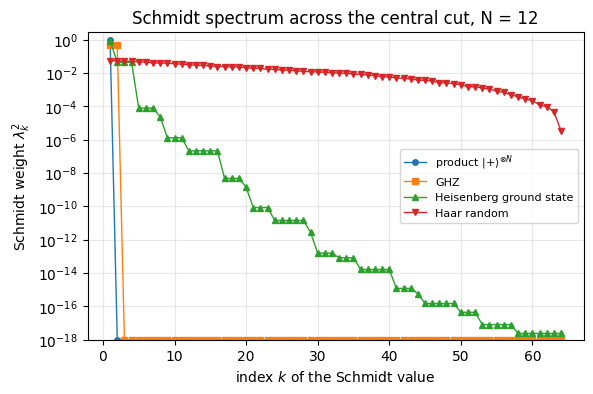

In [4]:
# ==============================================================================
# Schmidt spectra across the central cut for four N=12 states
# ==============================================================================
N_SMALL = 12
terms_heis = heisenberg_terms(N_SMALL, 1.0, 1.0, 1.0)                 # antiferromagnetic Heisenberg chain
E0, psi_gs = lanczos_ground_state(terms_heis, N_SMALL, m=40, restarts=2)
resid = jnp.linalg.norm(apply_hamiltonian(terms_heis, psi_gs) - E0 * psi_gs)
print(f"Heisenberg ground state, N={N_SMALL}: E0 = {E0:.10f},  residual ||H psi - E0 psi|| = {float(resid):.2e}")

zoo = {
    "product $|{+}\\rangle^{\\otimes N}$": product_state("+" * N_SMALL),
    "GHZ": ghz_state(N_SMALL),
    "Heisenberg ground state": psi_gs,
    "Haar random": haar_state(jax.random.PRNGKey(7), N_SMALL),
}
left_half = list(range(N_SMALL // 2))

fig, ax = plt.subplots(figsize=(6.4, 4.0))
for (name, psi_), mk in zip(zoo.items(), ("o", "s", "^", "v")):
    lam_ = np.asarray(schmidt_values(psi_, left_half))
    S_ = float(entanglement_entropy(psi_, left_half))
    rank_ = int(np.sum(lam_ > 1e-13))                      # numerical Schmidt rank
    print(f"{name:40s} Schmidt rank = {rank_:3d}   S = {S_:.4f} bits")
    ax.semilogy(np.arange(1, 65), np.clip(lam_ ** 2, 1e-18, None), marker=mk, ms=4, lw=1, label=name)
ax.set_xlabel("index $k$ of the Schmidt value")
ax.set_ylabel(r"Schmidt weight $\lambda_k^2$")
ax.set_ylim(1e-18, 3)
ax.set_title(f"Schmidt spectrum across the central cut, N = {N_SMALL}")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.show()

**Reading the figure.** The matrix $M$ is $64\times64$, so there are at most 64 Schmidt values.

- The product state has exactly one (rank 1, $S=0$): the other weights sit at the clipping floor $10^{-18}$.
- GHZ has exactly two equal weights $1/2$ (rank 2, $S=1$ bit), no matter how long the chain is.
- The Haar-random state uses *all* 64 with comparable weights; its entropy is close to the maximum
  $\log_2 64=6$ bits. This is a **volume law** ($S\propto$ number of spins in $A$): nothing can be discarded.
- The ground state is the interesting case. Formally its rank is also 64, but the weights fall off a cliff: below
  $10^{-5}$ after the first 8 values, below $10^{-9}$ after 20 (the plateaus are multiplets of the SU(2) spin-rotation
  symmetry). Keeping $\chi=16$ values would already describe it far more accurately than any experiment could tell.

> **Physics insight.** Ground states of gapped local Hamiltonians in one dimension obey an **area law**
> (Hastings 2007): $S_A$ is bounded by a constant independent of the size of $A$, because only the spins near the cut are
> correlated across it. At a critical point (the Heisenberg chain is critical) $S_A$ grows only logarithmically with
> the block size. Both are tiny compared with the volume law of a random state. The physically relevant states
> live in a small, weakly entangled corner of Hilbert space - and MPS are a parametrisation of that corner.

## 3. Matrix product states from repeated SVDs

### 3.1 Tensor-leg diagrams

We use the diagram notation of
[notebook 02 (Chapter 1)](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb): a tensor is a box, each index is a *leg*,
a leg shared by two boxes is summed over (contracted). The state tensor of five spins has five open legs:
```
       s0   s1   s2   s3   s4                     s0    s1    s2    s3    s4
       |    |    |    |    |                      |     |     |     |     |
     +------------------------+       =         [A0]--[A1]--[A2]--[A3]--[A4]
     |          psi           |                     a1    a2    a3    a4
     +------------------------+
```
On the right is where we are heading: a chain of **rank-3 tensors** $A^{[j]}$ with one *physical* leg $s_j$ (dimension 2,
pointing up) and two *virtual* or *bond* legs $a_j, a_{j+1}$ (horizontal) that connect neighbours. In formulas

$$ \psi[s_0,\dots,s_{N-1}] \;=\; \sum_{a_1,\dots,a_{N-1}} A^{[0]}_{s_0,a_1}\,A^{[1]}_{a_1,s_1,a_2}\cdots A^{[N-1]}_{a_{N-1},s_{N-1}}
   \;=\; A^{[0]s_0}A^{[1]s_1}\cdots A^{[N-1]s_{N-1}} . \qquad (1)$$

In the last form, for fixed $s_j$ each $A^{[j]s_j}$ is a **matrix** in its bond indices, and the amplitude is a **product of
matrices** (a row vector at the left end, a column vector at the right end) - hence the name. The dimension of bond
leg $a_j$ is the **bond dimension** $\chi_j$.

### 3.2 The construction

Every state can be brought into the form (1) *exactly*, by peeling off one spin at a time with an SVD:

**Step 1.** Reshape $\psi$ into a matrix with row index $s_0$ and column index $(s_1\dots s_{N-1})$, shape $2\times2^{N-1}$, and
decompose: $\psi_{s_0,(s_1\dots)}=\sum_{a_1}U_{s_0,a_1}S_{a_1}V^\dagger_{a_1,(s_1\dots)}$. Define $A^{[0]}_{s_0,a_1}=U_{s_0,a_1}$ and the
remainder $R_{a_1,(s_1\dots)}=S_{a_1}V^\dagger_{a_1,(s_1\dots)}$. The bond $a_1$ has dimension $\chi_1\le 2$.

**Step 2.** Reshape the remainder: group $(a_1,s_1)$ into the row index, $(s_2\dots)$ into the column index, shape
$2\chi_1\times 2^{N-2}$. SVD again: $R_{(a_1 s_1),(s_2\dots)}=\sum_{a_2}U_{(a_1s_1),a_2}S_{a_2}V^\dagger_{a_2,(s_2\dots)}$. Reshape $U$ into the
rank-3 tensor $A^{[1]}_{a_1,s_1,a_2}$; the new remainder is $S V^\dagger$.

**Step $j$.** Repeat until one spin is left; the last remainder *is* $A^{[N-1]}$.
```
    s0  s1  s2  s3           s0    s1 s2 s3           s0    s1    s2 s3           s0    s1    s2    s3
    |   |   |   |    SVD     |     |  |  |    SVD     |     |     |  |    SVD     |     |     |     |
   +-------------+   -->   [A0]--+---------+  -->   [A0]--[A1]--+------+  -->   [A0]--[A1]--[A2]--[A3]
   |     psi     |               |   R     |                    |  R   |
   +-------------+               +---------+                    +------+
```
Two facts follow immediately.

* The singular values found at step $j$ are the singular values of the matrix "spins $0..j$ versus the rest"
  (the part already split off, $A^{[0]}\cdots A^{[j-1]}$, is an isometry, and an isometry does not change singular values) - they are the
  **Schmidt values of the cut** between sites $j$ and $j+1$. So $\chi_{j+1}$ = Schmidt rank of that cut $\le \min(2^{j+1},2^{N-j-1})$.
* For a generic state the bond dimensions are therefore $2,4,8,\dots,2^{N/2},\dots,8,4,2$ and the MPS holds as many numbers
  as the state vector: **no free lunch, the representation is exact but not compressed**. For a weakly entangled state
  most singular values are (almost) zero and can be dropped: *that* is the compression.

### 3.3 From formula to code

The construction is a loop of `reshape` $\to$ `svd` $\to$ `reshape`. The shapes change at every step
($2\times2^{N-1}$, then $2\chi_1\times2^{N-2}$, ...), so this is a job for plain NumPy: there is nothing for `jit` to gain in
set-up code that runs once with a different shape in every iteration. We drop singular values that are zero to
machine precision, so the bond dimensions come out equal to the Schmidt ranks.

In [5]:
# ==============================================================================
# STEP 1: exact MPS from a state tensor by a left-to-right sweep of SVDs
# ==============================================================================
def state_to_mps_left(psi, cut=1e-13):
    """Exact left-canonical MPS of a state tensor psi[s_0..s_{N-1}].

    MATH
        psi = A[0]^{s_0} A[1]^{s_1} ... A[N-1]^{s_{N-1}},   A[j] has shape (chi_j, 2, chi_{j+1}), chi_0 = chi_N = 1.
        Sweep j = 0..N-2:   R (chi_j * 2, rest)  = U S V^dag ;  A[j] = U ;  R <- S V^dag.
    IMPLEMENTATION
        NumPy, because every iteration has a different shape.  Singular values below `cut` are dropped, so
        chi_{j+1} equals the Schmidt rank of the cut between sites j and j+1.
    RETURNS   (list of A tensors, list of the Schmidt-value arrays of the N-1 cuts)
    COST      dominated by the first SVDs: O(2^N * chi^2) -- this is a conversion tool for SMALL N only.
    """
    psi = np.asarray(psi)
    N = psi.ndim
    tensors, schmidt = [], []
    R, chi = psi.reshape(1, -1), 1                         # remainder, with a dummy left bond of dimension 1
    for j in range(N - 1):
        M = R.reshape(chi * 2, -1)                         # rows: (a_j, s_j)   columns: (s_{j+1}, ..., s_{N-1})
        U, S, Vh = np.linalg.svd(M, full_matrices=False)
        keep = max(1, int(np.sum(S > cut)))                # numerical Schmidt rank
        tensors.append(U[:, :keep].reshape(chi, 2, keep))  # A[j][a_j, s_j, a_{j+1}]
        schmidt.append(S[:keep])
        R, chi = S[:keep, None] * Vh[:keep], keep          # remainder  S V^dag
    tensors.append(R.reshape(chi, 2, 1))                   # the last remainder is the last tensor
    return tensors, schmidt


def mps_list_to_state(tensors):
    """Contract a list of rank-3 tensors back into the state tensor (validation only: O(2^N) memory).
    MATH   Eq. (1): the bond legs are summed.  `tensordot(.., axes=([-1],[0]))` ties the last leg of what we
    have so far to the first leg of the next tensor."""
    psi = tensors[0]
    for A in tensors[1:]:
        psi = np.tensordot(psi, A, axes=([-1], [0]))
    return psi[0, ..., 0]                                  # strip the two dummy boundary legs


# ------------------------------------------------------------------------------
# CHECKPOINT: the decomposition is exact, and bond dimension = Schmidt rank
# ------------------------------------------------------------------------------
for name, psi_ in zoo.items():
    tensors_, schmidt_ = state_to_mps_left(psi_)
    err = np.max(np.abs(mps_list_to_state(tensors_) - np.asarray(psi_)))
    n_par = sum(A.size for A in tensors_)
    print(f"{name:40s} bond dims {[A.shape[2] for A in tensors_[:-1]]}")
    print(f"{'':40s} parameters {n_par:6d} (state vector: {2 ** N_SMALL})   reconstruction error {err:.1e}")
    assert err < TOL
# the singular values of the sweep ARE the Schmidt values of each cut (compare with the engine, cut after site 3)
tensors_, schmidt_ = state_to_mps_left(psi_gs)
err_schmidt = np.max(np.abs(schmidt_[3] - np.asarray(schmidt_values(psi_gs, range(4)))[:len(schmidt_[3])]))
print(f"\nmax |sweep singular values - engine Schmidt values| at the cut after site 3: {err_schmidt:.1e}")
assert err_schmidt < TOL

product $|{+}\rangle^{\otimes N}$        bond dims [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
                                         parameters     24 (state vector: 4096)   reconstruction error 6.5e-16
GHZ                                      bond dims [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
                                         parameters     88 (state vector: 4096)   reconstruction error 0.0e+00
Heisenberg ground state                  bond dims [2, 4, 8, 16, 32, 64, 32, 16, 8, 4, 2]
                                         parameters  10920 (state vector: 4096)   reconstruction error 9.7e-16
Haar random                              bond dims [2, 4, 8, 16, 32, 64, 32, 16, 8, 4, 2]
                                         parameters  10920 (state vector: 4096)   reconstruction error 2.6e-16

max |sweep singular values - engine Schmidt values| at the cut after site 3: 1.7e-16


**Interpretation.** All four reconstructions are exact to machine precision. The bond dimensions tell the
whole story: the product state has $\chi=1$ everywhere ($2N=24$ numbers), GHZ has $\chi=2$ (88 numbers), while the random
state - and also the *exact* ground state - need the full pyramid $2,4,\dots,64,\dots,4,2$ and *more* parameters (10920)
than the state vector (4096). The ground state's 64 Schmidt values are tiny but all above our threshold $10^{-13}$;
the compression comes only when we accept a small error (Sec. 3.5).

### 3.4 Gauge freedom and canonical forms

The MPS of a state is not unique: inserting $X X^{-1}=1$ on any bond, $A^{[j]}\to A^{[j]}X$, $A^{[j+1]}\to X^{-1}A^{[j+1]}$, changes the
tensors but not the state. This *gauge freedom* is used to impose convenient normalisation conditions.

**Left-canonical.** Our tensors came from the matrix $U$ of an SVD, which has orthonormal columns, $U^\dagger U=1$.
With $U_{(a s),a'}=A_{a,s,a'}$ this says

$$ \sum_{s}\big(A^{s}\big)^\dagger A^{s}=1 \qquad\Longleftrightarrow\qquad \sum_{a,s} A^*_{a,s,b'}A_{a,s,b}=\delta_{b'b}. \qquad (2)$$

As a diagram (the lower row is the complex conjugate; the arc on the left ties the two left legs):
```
     +--[A ]-- b             +-- b
     |   | s          =      |
     +--[A*]-- b'            +-- b'
```
Consequence: the states $|L_b\rangle$ of the first $j+1$ spins defined by contracting $A^{[0]}\cdots A^{[j]}$ with the last bond index
fixed to $b$ are **orthonormal**. (Induction: if the $|L_a\rangle$ of the first $j$ spins are orthonormal then
$\langle L_{b'}|L_b\rangle=\sum_{a,s}A^*_{a,s,b'}A_{a,s,b}=\delta_{b'b}$.)

**Right-canonical.** Sweeping from the right end instead, one keeps the rows of $V^\dagger$ and obtains tensors $B$ with

$$ \sum_s B^{s}\big(B^{s}\big)^\dagger = 1 \qquad\Longleftrightarrow\qquad \sum_{s,b}B_{a,s,b}B^*_{a',s,b}=\delta_{aa'}, \qquad (3)$$

and orthonormal states $|R_a\rangle$ of the spins to the right of a bond.

**Mixed-canonical and Vidal's form.** Use $A$'s to the left of some bond, $B$'s to the right of it, and let the
diagonal matrix of singular values $\Lambda=\mathrm{diag}(\lambda_1,\lambda_2,\dots)$ sit on the bond:
```
     [A0]--[A1]--[A2]--<L>--[B3]--[B4]           |psi> = sum_a  lambda_a |L_a> |R_a>
```
Because the $|L_a\rangle$ and $|R_a\rangle$ are orthonormal, this *is* the Schmidt decomposition across that bond, displayed
explicitly. G. Vidal's **$\Gamma$-$\Lambda$ form** makes this true at *every* bond simultaneously by writing

$$ \psi = \Gamma^{[0]s_0}\Lambda^{[1]}\Gamma^{[1]s_1}\Lambda^{[2]}\cdots\Lambda^{[N-1]}\Gamma^{[N-1]s_{N-1}},
   \qquad A^{[j]}=\Lambda^{[j]}\Gamma^{[j]},\qquad B^{[j]}=\Gamma^{[j]}\Lambda^{[j+1]}. \qquad (4)$$

Grouping each $\Lambda$ with the $\Gamma$ to its right gives left-canonical $A$'s, grouping it with the $\Gamma$ to its left gives
right-canonical $B$'s; from (4) one reads off the useful identity

$$ \Lambda^{[j]}B^{[j]} = \Lambda^{[j]}\Gamma^{[j]}\Lambda^{[j+1]} = A^{[j]}\Lambda^{[j+1]}, \qquad (5)$$

i.e. a $\Lambda$ can be *pushed through* a tensor, turning a $B$ into an $A$. **In this notebook we store the right-canonical
tensors $B^{[j]}$ together with the Schmidt values $\Lambda^{[j]}$ of every bond.** By Eq. (5) this contains the same
information as Vidal's form, but (as we will see in Sec. 7) the TEBD update can then be written without ever dividing
by a small Schmidt value.

Let us verify Eq. (2) on the tensors we have just computed.

In [6]:
# ------------------------------------------------------------------------------
# CHECKPOINT: the tensors from the left-to-right sweep are left-canonical, Eq. (2)
# ------------------------------------------------------------------------------
tensors_, _ = state_to_mps_left(zoo["Haar random"])
worst = 0.0
for A in tensors_:
    gram = np.einsum("asb,asc->bc", A.conj(), A)          # sum_{a,s} A*[a,s,b'] A[a,s,b]
    worst = max(worst, np.max(np.abs(gram - np.eye(A.shape[2]))))
print(f"left-canonical condition, max deviation over all sites: {worst:.1e}")
assert worst < TOL

left-canonical condition, max deviation over all sites: 2.2e-15


The einsum string `"asb,asc->bc"` is Eq. (2) letter by letter: the left bond `a` and the physical index `s`
appear in both operands and not in the output (summed), the two right bonds `b`, `c` stay open. The result is the
identity matrix on every site (on the last site it is the $1\times1$ matrix $\langle\psi|\psi\rangle=1$).

### 3.5 Truncation: the error is the discarded Schmidt weight

Suppose the state is in mixed-canonical form around one bond, $|\psi\rangle=\sum_{k=1}^{r}\lambda_k|L_k\rangle|R_k\rangle$, and we keep only the
$\chi<r$ largest terms, $|\tilde\psi\rangle=\sum_{k\le\chi}\lambda_k|L_k\rangle|R_k\rangle$. By orthonormality of the Schmidt vectors

$$ \big\||\psi\rangle-|\tilde\psi\rangle\big\|^2=\sum_{k>\chi}\lambda_k^2\equiv\varepsilon \qquad\text{(the discarded weight)}. $$

The Eckart-Young theorem of linear algebra (quoted) states that *no* matrix of rank $\chi$ is closer to $M$ in Frobenius
norm than its truncated SVD: **keeping the largest Schmidt values is the optimal compression**. After
renormalising, $|\tilde\psi\rangle\to|\tilde\psi\rangle/\sqrt{1-\varepsilon}$, the fidelity with the original state is

$$ F=|\langle\psi|\tilde\psi\rangle|^2 = \frac{\big(\sum_{k\le\chi}\lambda_k^2\big)^2}{1-\varepsilon}=1-\varepsilon . \qquad (6)$$

The Eckart-Young theorem is Eckart and Young (1936); a modern account of the SVD as a numerical algorithm is
Numerical Recipes, 3rd ed., Sec. 2.6.

Compressing *all* $N-1$ bonds means truncating them one after the other, each time in the mixed-canonical form
centred on the bond being cut - which is exactly what the sweep below does. For that procedure,

$$ \big\||\psi\rangle-|\tilde\psi\rangle\big\|^2\;\le\;2\sum_{b}\varepsilon_b \qquad\text{(one state, one sweep)} $$

(Verstraete and Cirac 2006, quoted). Read the scope carefully, because we will violate it in Sec. 9: the $\varepsilon_b$ are
the discarded weights encountered while compressing **one given state** in **one sweep**. Nothing here bounds the
error of a *sequence* of truncations separated by time evolution, where each truncation is measured on a state that
previous truncations have already changed. That case is worked out in Sec. 9.
(For normalised states $1-F=1-|\langle\psi\vert\tilde\psi\rangle|^2\le\||\psi\rangle-|\tilde\psi\rangle\|^2$, so the bound may be tested on the
infidelity, which is what the code below does.)
The discarded weight is in any case an *a-posteriori error estimate that costs nothing*: the SVD hands it to us.

**From formula to code.** The production converter below differs from `state_to_mps_left` in three ways:
(i) it sweeps from the **right**, so it produces right-canonical $B$ tensors and the Schmidt values $\Lambda^{[j]}$ of all cuts;
(ii) it truncates every bond to at most $\chi$ values, renormalises, and records the discarded weights;
(iii) it writes the result into **zero-padded arrays of fixed shape** `B[N, chi, 2, chi]` and `lam[N+1, chi]` - the
data structure discussed in Sec. 4. Convention: `lam[j]` holds the Schmidt values of the cut to the **left of site
$j$** (between sites $j-1$ and $j$); the dummy boundary bonds are `lam[0] = lam[N] = (1,0,0,...)`.

In [7]:
# ==============================================================================
# STEP 2: truncated, right-canonical, zero-padded MPS  (the format used by TEBD below)
# ==============================================================================
def state_to_mps(psi, chi, cut=1e-13):
    """State tensor -> right-canonical MPS with bond dimension <= chi, stored in fixed-shape padded arrays.

    MATH
        psi ~ B[0]^{s_0} B[1]^{s_1} ... B[N-1]^{s_{N-1}},    sum_s B^s B^s^dag = 1  (right-canonical, Eq. 3)
        Sweep j = N-1..1:   R (rest, 2*chi_{j+1}) = U S V^dag ;  B[j] = V^dag (first chi rows) ;
                            lam[j] = S[:chi]/||S[:chi]|| ;  eps[j] = sum_{k>=chi} S_k^2 / sum_k S_k^2 ;  R <- U S.
    RETURNS
        B    complex array (N, chi, 2, chi)   B[j][a, s, b]; unused entries are exactly zero
        lam  real array    (N+1, chi)         Schmidt values of the cut left of site j; lam[0]=lam[N]=(1,0,..)
        eps  real array    (N+1,)             discarded weight at every cut
    COST   O(2^N chi^2): conversion tool for small N (validation, initial states from exact methods).
    """
    psi = np.asarray(psi)
    N = psi.ndim
    B = np.zeros((N, chi, 2, chi), dtype=psi.dtype)
    lam = np.zeros((N + 1, chi))
    eps = np.zeros(N + 1)
    lam[0, 0] = lam[N, 0] = 1.0
    R, r = psi.reshape(-1, 1), 1                           # remainder with a dummy right bond of dimension 1
    for j in range(N - 1, 0, -1):
        M = R.reshape(-1, 2 * r)                           # rows: (s_0..s_{j-1})   columns: (s_j, b_{j+1})
        U, S, Vh = np.linalg.svd(M, full_matrices=False)
        keep = max(1, min(chi, int(np.sum(S > cut))))
        eps[j] = np.sum(S[keep:] ** 2) / np.sum(S ** 2)
        S = S[:keep] / np.linalg.norm(S[:keep])            # truncate + renormalise
        B[j, :keep, :, :r] = Vh[:keep].reshape(keep, 2, r)
        lam[j, :keep] = S
        R, r = U[:, :keep] * S[None, :], keep              # remainder  U S
    B[0, 0, :, :r] = R.reshape(2, r)
    return jnp.asarray(B, dtype=CDTYPE), jnp.asarray(lam, dtype=RDTYPE), eps


@jax.jit
def mps_to_state(B):
    """Padded MPS -> state tensor (validation only, O(2^N)).  The dummy boundary bonds are index 0.
    JAX: the shapes are static, so the whole chain of N contractions is compiled once per (N, chi)."""
    psi = B[0][0]                                          # (2, chi): left boundary leg fixed to 0
    for j in range(1, B.shape[0]):
        psi = jnp.tensordot(psi, B[j], axes=([-1], [0]))
    return psi[..., 0]                                     # right boundary leg fixed to 0


# ------------------------------------------------------------------------------
# CHECKPOINTS
# ------------------------------------------------------------------------------
psi_rand = zoo["Haar random"]
B_, lam_, eps_ = state_to_mps(psi_rand, 64)               # chi = 2^{N/2}: exact
err_exact = float(jnp.max(jnp.abs(mps_to_state(B_) - psi_rand)))
gram = jnp.einsum("jasb,jcsb->jac", B_, jnp.conj(B_))     # Eq. (3) on every site at once (j = site index)
proj = jax.vmap(jnp.diag)((lam_[:-1] > 0).astype(RDTYPE)) # identity on the USED bond indices, zero on the padding
err_canon = float(jnp.max(jnp.abs(gram - proj)))
pad64 = lambda v: jnp.pad(v, (0, 64 - v.shape[0]))          # a cut after j < 6 sites has only 2^j Schmidt values
err_lam = max(float(jnp.max(jnp.abs(lam_[j] - pad64(schmidt_values(psi_rand, range(j)))))) for j in (3, 6, 9))
print(f"chi=64 (exact):   reconstruction error        {err_exact:.1e}")
print(f"                  right-canonical condition   {err_canon:.1e}")
print(f"                  lam[j] vs engine Schmidt values (cuts 3,6,9)  {err_lam:.1e}")
assert max(err_exact, err_canon, err_lam) < TOL

# truncating ONE bond: fidelity = 1 - discarded weight, Eq. (6)
lam_c = np.asarray(schmidt_values(psi_gs, left_half))
for chi_ in (4, 8, 16):
    Uc, Sc, Vc = np.linalg.svd(np.asarray(psi_gs).reshape(64, 64), full_matrices=False)
    psi_t = (Uc[:, :chi_] * Sc[:chi_]) @ Vc[:chi_]
    psi_t = psi_t / np.linalg.norm(psi_t)
    F = abs(np.vdot(np.asarray(psi_gs).reshape(-1), psi_t.reshape(-1))) ** 2
    eps_c = np.sum(lam_c[chi_:] ** 2)
    print(f"central bond only, chi={chi_:2d}:  1-F = {1 - F:.3e}   discarded weight = {eps_c:.3e}")
    assert abs((1 - F) - eps_c) < 1e3 * TOL

chi=64 (exact):   reconstruction error        4.1e-16
                  right-canonical condition   1.7e-15
                  lam[j] vs engine Schmidt values (cuts 3,6,9)  6.1e-16
central bond only, chi= 4:  1-F = 2.620e-04   discarded weight = 2.620e-04
central bond only, chi= 8:  1-F = 4.991e-06   discarded weight = 4.991e-06
central bond only, chi=16:  1-F = 1.606e-08   discarded weight = 1.606e-08


**Interpretation.** With $\chi=2^{N/2}=64$ nothing is discarded and the padded right-canonical MPS reproduces the
state and carries the correct Schmidt values on every bond. The canonical condition takes a modified form in the
padded storage, and the modification is the reason the checkpoint compares with `proj` and not with `eye(chi)`:
rows of $B^{[j]}$ belonging to unused left-bond indices are exactly zero, so the left-hand side of Eq. (3) must be
zero there too. What the padded tensors satisfy is the **projected** condition

$$ \sum_{s,b}B^{[j]}_{a,s,b}\,\big(B^{[j]}_{a',s,b}\big)^*=P^{[j]}_{aa'},\qquad P^{[j]}_{aa'}=\delta_{aa'}\big[\lambda^{[j]}_a>0\big]. \qquad (3')$$

Two details are easy to get wrong. The projector is built from $\lambda^{[j]}$ - the Schmidt values of the bond to the
**left** of site $j$, which is the bond carrying the index $a$ - and not from $\lambda^{[j+1]}$; and it is a projector, not the
identity, so a code that asserts `gram == eye(chi)` fails on every padded MPS. On the used block $P^{[j]}$ *is* the
identity, and Eq. (3) holds there verbatim.

The second test confirms Eq. (6) for a single truncated bond: infidelity and discarded weight agree.

Now the compression experiment announced in Sec. 2: truncate **all** bonds to $\chi$ and measure the infidelity
$1-F$, for the area-law-like ground state and for the volume-law random state.

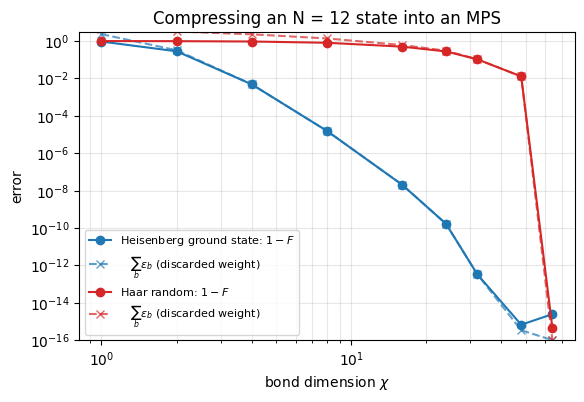

Heisenberg ground state    1-F at chi=8: 1.56e-05   chi=16: 2.06e-08   chi=32: 3.34e-13
Haar random                1-F at chi=8: 8.09e-01   chi=16: 5.01e-01   chi=32: 1.06e-01


In [8]:
# ==============================================================================
# EXPERIMENT: how well do chi Schmidt values per bond describe a state?
# ==============================================================================
chis_c = [1, 2, 4, 8, 16, 24, 32, 48, 64]
results_c = {}
for name in ("Heisenberg ground state", "Haar random"):
    infid, disc = [], []
    for chi_ in chis_c:
        B_, lam_, eps_ = state_to_mps(zoo[name], chi_)
        infid.append(1.0 - float(fidelity_pure(zoo[name], mps_to_state(B_))))
        disc.append(float(np.sum(eps_)))
    results_c[name] = (np.array(infid), np.array(disc))
    assert np.all(results_c[name][0] <= 2 * results_c[name][1] + 1e3 * TOL)   # error bound 2 * sum(eps)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
for name, c in zip(results_c, ("C0", "C3")):
    infid, disc = results_c[name]
    ax.loglog(chis_c, np.clip(infid, 1e-16, None), "o-", color=c, label=f"{name}: $1-F$")
    ax.loglog(chis_c, np.clip(disc, 1e-16, None), "x--", color=c, alpha=0.7, label=r"   $\sum_b\varepsilon_b$ (discarded weight)")
ax.set_xlabel(r"bond dimension $\chi$")
ax.set_ylabel("error")
ax.set_ylim(1e-16, 3)
ax.set_title(f"Compressing an N = {N_SMALL} state into an MPS")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=8)
plt.show()
for name in results_c:
    i8, i16, i32 = chis_c.index(8), chis_c.index(16), chis_c.index(32)
    print(f"{name:26s} 1-F at chi=8: {results_c[name][0][i8]:.2e}   chi=16: {results_c[name][0][i16]:.2e}"
          f"   chi=32: {results_c[name][0][i32]:.2e}")

**Interpretation.** The ground state is reproduced with infidelity $1.6\times10^{-5}$ at $\chi=8$ and
$2\times10^{-8}$ at $\chi=16$ - with 16 instead of 64 values per bond - and the error keeps falling
steeply with $\chi$. The random state is hopeless: at $\chi=16$ half of the state is lost ($1-F\approx0.5$), even at
$\chi=32$ the infidelity is still about 0.1, and it becomes exact only at $\chi=64$, where nothing is compressed. In both cases the summed
discarded weight (crosses) tracks the true infidelity (circles) closely and the bound $1-F\le2\sum_b\varepsilon_b$ holds
(asserted in the code): we can monitor the error without knowing the exact state.

> **Numerical practice.** An MPS calculation is *controlled* by one number, $\chi$. The honest workflow is:
> run at several $\chi$, monitor the discarded weight, and accept only results that no longer change with $\chi$.

## 4. A JAX-friendly data structure: fixed bond dimension, zero padding

In a textbook MPS every tensor has its own shape $(\chi_j,2,\chi_{j+1})$, and during time evolution the $\chi_j$ *grow* from 1
(product state) to whatever the entanglement demands. Each of the three JAX transformations we rely on forbids that:

* `jax.jit` compiles a function **for given array shapes**. A two-site update called with shapes
  $(1,2,2),(2,2,4),(4,2,8),\dots$ is recompiled for every new combination, and recompilation (seconds) is far more
  expensive than the update itself (milliseconds).
* `lax.scan` requires that the carried state has the **same shape at every time step** - growing tensors cannot be
  carried at all.
* `jax.vmap` batches a function over arrays of **identical shape** - tensors of different sizes cannot be stacked.

The remedy is to **allocate every tensor with the maximal bond dimension $\chi$ from the
start and fill the unused entries with zeros.** The whole MPS is then two arrays,

| array | shape | content |
|---|---|---|
| `B`   | `(N, chi, 2, chi)` | right-canonical tensors `B[j][a, s, b]` (left bond, physical, right bond) |
| `lam` | `(N+1, chi)` | Schmidt values of the cut left of site `j`; `lam[0] = lam[N] = (1, 0, 0, ...)` |

Why is padding harmless? A bond index whose Schmidt value is zero contributes nothing to any contraction, so the
padded MPS represents exactly the same state. The SVD inside the update will see a matrix with some zero rows and
columns and return some singular values that are exactly (or to rounding, $10^{-17}$) zero - precisely the padding of
the new tensors. Even the open boundary is handled by padding: the "dimension-1" bonds at the ends are bonds of
dimension $\chi$ with a single non-zero Schmidt value. What we pay is wasted arithmetic at early times when the true bond
dimension is still small; what we gain is *one* compilation, a `vmap` over all bonds of a layer and a `scan` over
time.

> **JAX practice.** "Make the shapes static and mask what you do not need" is the general recipe for translating
> algorithms with data-dependent sizes to JAX (or to any accelerator). Truncating "all singular values below
> $10^{-10}$" gives a data-dependent shape; "keep the $\chi$ largest, some of which may be zero" does not.

A product state is the simplest MPS: $\chi=1$, $B^{[j]}_{0,s,0}=v_j[s]$ with $v_j$ the single-spin state of site $j$.

In [9]:
# ==============================================================================
# STEP 3: product states directly in the padded format  (no 2^N object anywhere)
# ==============================================================================
_SPIN = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1]}     # same characters as the engine's product_state


def product_mps(spec, chi):
    """Product state |spec[0]> |spec[1]> ... as a padded MPS  (B[N,chi,2,chi], lam[N+1,chi]).
    MATH   B[j][0, s, 0] = v_j[s], all other entries zero;  every cut has the single Schmidt value 1.
    '0' = spin up (Z=+1), '1' = spin down (Z=-1), '+'/'-' = eigenstates of X."""
    N = len(spec)
    B = np.zeros((N, chi, 2, chi), dtype=complex)
    for j, c in enumerate(spec):
        v = np.array(_SPIN[c], dtype=complex)
        B[j, 0, :, 0] = v / np.linalg.norm(v)
    lam = np.zeros((N + 1, chi))
    lam[:, 0] = 1.0
    return jnp.asarray(B, dtype=CDTYPE), jnp.asarray(lam, dtype=RDTYPE)


B_, lam_ = product_mps("01+-01", 8)
err = float(jnp.max(jnp.abs(mps_to_state(B_) - product_state("01+-01"))))
print(f"product_mps vs engine product_state (N=6): max difference {err:.1e}")
assert err < TOL
B_, lam_ = product_mps("01" * 30, 64)
print(f"Neel state of N=60 spins at chi=64: B has shape {B_.shape} = {B_.nbytes / 2**20:.1f} MB")

product_mps vs engine product_state (N=6): max difference 0.0e+00
Neel state of N=60 spins at chi=64: B has shape (60, 64, 2, 64) = 7.5 MB


Sixty spins, 7.5 MB - and an object of size `2**60` never appeared.

## 5. Observables and entanglement from the MPS

### 5.1 Local expectation values: the canonical form does the work

For an operator $O$ on site $j$ write the state in mixed-canonical form centred on that site,
$\theta_{a,s,b}=\lambda^{[j]}_aB^{[j]}_{a,s,b}$ (Eq. 5 again). Everything to the left contracts to $\delta_{aa'}$ (left-canonical, Eq. 2),
everything to the right to $\delta_{bb'}$ (right-canonical, Eq. 3):
```
     +--[theta ]--+
     |     |      |                  <O_j> = sum_{a,b,s,t}  theta*[a,t,b]  O[t,s]  theta[a,s,b]
     |    [O]     |
     |     |      |                  einsum("atb,ts,asb->", conj(theta), O, theta)
     +--[theta*]--+
```
The cost is $O(\chi^2)$ per site, independent of $N$ - compare with $O(2^N)$ for `expect_local` on a state vector. With our
stacked arrays, *all* sites are done in one call by adding a batch letter `j` to the einsum. Two-site operators on
neighbouring sites (bond energies) work the same way with $\theta_{a,s,t,b}$.

### 5.2 Entanglement entropy from the stored Schmidt values

`lam[j]` *are* the Schmidt values of the cut left of site $j$. So $S_j=-\sum_k\lambda_k^2\log_2\lambda_k^2$ for **all** cuts costs
$O(N\chi)$ - no reduced density matrix, no SVD of a $2^{N/2}\times2^{N/2}$ matrix.

### 5.3 Overlaps and long-distance correlators: transfer-matrix contractions

Not everything is local. The overlap $\langle\phi|\psi\rangle$ of two MPS is the contraction of a ladder,
```
     +--[B0 ]--[B1 ]--[B2 ]-- ... --[B_N-1 ]--+          E <- sum_s  conj(Bphi[a,s,b]) E[a,c] Bpsi[c,s,d]
     E    |      |      |              |      |          einsum("ac,asb,csd->bd", E, conj(Bphi_j), Bpsi_j)
     +--[B0*]--[B1*]--[B2*]-- ... --[B_N-1*]--+
```
evaluated from left to right: the $\chi\times\chi$ matrix $E$ ("environment") is pushed through one site at a time; each
push costs $O(\chi^3)$. The map $E\mapsto\sum_sB^{s\dagger}EB^s$ is called the **transfer matrix**. Never contract the ladder in
another order: contracting the top row first would rebuild the $2^N$ amplitudes. Since all tensors have the same
shape, the sweep over sites is a `lax.scan` over the leading axis of `B`.
A correlator $\langle O_iP_j\rangle$ with $i<j$ uses the same idea: start at site $i$ with $\theta$ and $O$ inserted (the left part is the
identity by canonical form), push the environment through sites $i+1..j-1$, and close at site $j$ with $P$ inserted (the
right part is the identity again).

In [10]:
# ==============================================================================
# STEP 5: measurements on a padded, right-canonical MPS
# ==============================================================================
def mps_expect_sites(B, lam, O):
    """<O_j> for ALL sites j at once.   MATH  theta_j = lam[j] B[j];  <O_j> = sum theta*[a,t,b] O[t,s] theta[a,s,b].
    COST O(N chi^2).  The letter j in the einsum is a batch index (one independent contraction per site)."""
    theta = lam[:-1, :, None, None] * B
    return jnp.real(jnp.einsum("jatb,ts,jasb->j", jnp.conj(theta), jnp.asarray(O, dtype=B.dtype), theta))


def mps_expect_bonds(B, lam, h_bonds):
    """<h_j> for all N-1 nearest-neighbour operators h_j (array (N-1,4,4)) at once; sum = energy.
    MATH  theta[a,s,t,b] = lam[j][a] B[j][a,s,m] B[j+1][m,t,b];   <h> = sum theta*[a,s,t,b] h[s,t,u,v] theta[a,u,v,b]."""
    theta = jnp.einsum("ja,jasm,jmtb->jastb", lam[:-2].astype(B.dtype), B[:-1], B[1:])
    h = jnp.asarray(h_bonds, dtype=B.dtype).reshape(-1, 2, 2, 2, 2)
    return jnp.real(jnp.einsum("jastb,jstuv,jauvb->j", jnp.conj(theta), h, theta))


def mps_entropies(lam):
    """Entanglement entropy (bits) of every cut, directly from the stored Schmidt values:
    S_j = -sum_k lam[j,k]^2 log2 lam[j,k]^2   (0 log 0 := 0 handles the zero padding)."""
    p = lam ** 2
    return -jnp.sum(jnp.where(p > 0, p * jnp.log2(jnp.where(p > 0, p, 1.0)), 0.0), axis=1)


def mps_overlap(B_phi, B_psi):
    """<phi|psi> of two padded MPS (bond dimensions may differ) by a transfer-matrix sweep.
    MATH  E_0 = e_0 e_0^T (dummy left bonds);  E <- sum_s conj(Bphi^s)^T E Bpsi^s ;  result E[0,0].
    JAX   all site tensors have the same shape -> the sweep is a lax.scan over the site axis.  COST O(N chi^3)."""
    E0 = jnp.zeros((B_phi.shape[1], B_psi.shape[1]), dtype=B_psi.dtype).at[0, 0].set(1.0)

    def push(E, tensors):
        Bp, Bq = tensors
        return jnp.einsum("ac,asb,csd->bd", E, jnp.conj(Bp), Bq), None

    E, _ = lax.scan(push, E0, (B_phi, B_psi))
    return E[0, 0]


def mps_correlator(B, lam, O, i, P, j):
    """<O_i P_j> for i < j (static ints) with a transfer-matrix sweep between the two sites.  COST O((j-i) chi^3)."""
    O, P = jnp.asarray(O, dtype=B.dtype), jnp.asarray(P, dtype=B.dtype)
    theta = lam[i][:, None, None] * B[i]
    E = jnp.einsum("atb,ts,asc->bc", jnp.conj(theta), O, theta)       # open legs: right bonds (bra b, ket c)
    for k in range(i + 1, j):
        E = jnp.einsum("bc,bsd,cse->de", E, jnp.conj(B[k]), B[k])     # push through site k
    return jnp.real(jnp.einsum("bc,btd,ts,csd->", E, jnp.conj(B[j]), P, B[j]))


# ------------------------------------------------------------------------------
# CHECKPOINT against the state-vector engine, on the exact MPS of the N=12 ground state
# ------------------------------------------------------------------------------
B_g, lam_g, _ = state_to_mps(psi_gs, 64)
z_ref = jnp.stack([expect_local(psi_gs, Z, [q]) for q in range(N_SMALL)])
h_heis = jnp.stack([XX + YY + ZZ] * (N_SMALL - 1))
S_ref = jnp.stack([entanglement_entropy(psi_gs, range(c)) for c in range(1, N_SMALL)])
checks = {
    "<Z_j> all sites": jnp.max(jnp.abs(mps_expect_sites(B_g, lam_g, Z) - z_ref)),
    "energy = sum of bond terms": jnp.abs(jnp.sum(mps_expect_bonds(B_g, lam_g, h_heis)) - E0),
    "entropies of all cuts": jnp.max(jnp.abs(mps_entropies(lam_g)[1:-1] - S_ref)),
    "norm <psi|psi> - 1": jnp.abs(mps_overlap(B_g, B_g) - 1),
    "<Z_2 Z_9>": jnp.abs(mps_correlator(B_g, lam_g, Z, 2, Z, 9) - expect_local(psi_gs, ZZ, [2, 9])),
}
for name, e in checks.items():
    print(f"{name:30s} error {float(e):.1e}")
    assert float(e) < 100 * TOL
print(f"(for reference: <Z_2 Z_9> = {float(mps_correlator(B_g, lam_g, Z, 2, Z, 9)):+.6f},"
      f"  central entropy = {float(mps_entropies(lam_g)[N_SMALL // 2]):.4f} bits)")

<Z_j> all sites                error 9.1e-15
energy = sum of bond terms     error 1.1e-14
entropies of all cuts          error 7.1e-14
norm <psi|psi> - 1             error 2.8e-15
<Z_2 Z_9>                      error 8.9e-16
(for reference: <Z_2 Z_9> = -0.120866,  central entropy = 0.7745 bits)


All five measurement routines agree with the state-vector engine to rounding accuracy.

## 6. Ground states: the density-matrix renormalisation group (DMRG)

The TEBD sections below evolve a *given* MPS in time. The first question one asks about a many-body Hamiltonian, however, is static: what is its ground state? For chains
the answer is the **density-matrix renormalisation group** (DMRG), invented by S. R. White in 1992 and understood a decade later as a variational method in the space of matrix
product states (Östlund and Rommer 1995; Schollwöck 2011). It is the most important algorithm of one-dimensional quantum many-body physics, and it is conceptually the most
demanding part of this course. We therefore build it one element at a time. Every element is derived, written as a small function, and checked against a dense calculation on a
chain short enough to be diagonalised exactly, before it is used.

**The idea in one paragraph.** We look for the MPS with the lowest energy $\langle\psi|H|\psi\rangle/\langle\psi|\psi\rangle$. Varying all tensors at once is a hard non-linear problem. DMRG
varies **two neighbouring tensors at a time** and keeps all others fixed. With the other tensors in canonical form (Section 3.4), this local problem is exactly the
Rayleigh–Ritz problem of [notebook 11 (Chapter 5)](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb): minimise the energy in a subspace, which
is a small eigenvalue problem, solved with Lanczos. The subspace is spanned by the states "left block $\otimes$ two free spins $\otimes$ right block". After solving it, we move
one site to the right and repeat. Walking through the chain from left to right and back is called a **sweep**, and a few sweeps converge to the ground state.

**Road map of this section.**

| step | element | what it is | checked against |
|---|---|---|---|
| 6.1 | the local problem | why fixing all tensors but two gives an eigenvalue problem | — (derivation) |
| 6.2 | matrix product operator (MPO) | the Hamiltonian written as a product of small matrices | dense $H$, $N=4,6$ |
| 6.3 | environments $L_j$, $R_j$ | the Hamiltonian contracted with the fixed left and right parts of the MPS | dense energy |
| 6.4 | effective Hamiltonian $H_{\rm eff}$ | $H$ restricted to the two-site subspace, applied without building it | $P^\dagger HP$, $N=6$ |
| 6.5 | local solver | lowest eigenvector of $H_{\rm eff}$ by Lanczos | dense `eigh` of $H_{\rm eff}$ |
| 6.6 | split and truncation | the two-site tensor back into two MPS tensors, centre moved by one site | canonical conditions |
| 6.7 | the sweep | the complete algorithm, and a traced run | exact energy, $N=8$ |
| 6.8 | validation | Lanczos at $N=12$; exact free-fermion energies at $N=60$ | |
| 6.9 | physics | the XXZ chain in a transverse field at $N=60$ and $100$ | |

**The objects and their shapes.** Every array of this section has a fixed shape; $\chi$ is the MPS bond dimension, $D=5$ the MPO bond dimension, $d=2$ the physical dimension.

| symbol | array | shape | meaning |
|---|---|---|---|
| $B^{[j]}$, $M^{[j]}$ | `B`, `M` | $(N,\chi,2,\chi)$ | MPS tensors `[left bond, physical, right bond]`; $M^{[j]}$ is whatever is stored at site $j$ during a sweep |
| $\Lambda^{[j]}$ | `lam` | $(N+1,\chi)$ | Schmidt values of the cut left of site $j$ |
| $W^{[j]}$ | `W` | $(N,D,D,2,2)$ | MPO tensors `[MPO in, MPO out, physical out, physical in]` |
| $L_j$, $R_j$ | `L[j]`, `R[j]` | $(\chi,D,\chi)$ | environments `[ket bond, MPO bond, bra bond]` |
| $\theta$ | `theta` | $(\chi,2,2,\chi)$ | two-site tensor `[left bond, physical, physical, right bond]` |

### 6.1 The local problem

Write the MPS in the **mixed-canonical form centred on the two sites $j$ and $j+1$**: left-canonical tensors $A$ on the sites $0,\dots,j-1$, right-canonical tensors $B$ on the sites
$j+2,\dots,N-1$, and one two-site tensor $\theta$ in between,

$$ \psi[s_0,\dots,s_{N-1}]=\sum_{a,b}\big(A^{[0]s_0}\cdots A^{[j-1]s_{j-1}}\big)_{a}\;\theta_{a,s_j,s_{j+1},b}\;\big(B^{[j+2]s_{j+2}}\cdots B^{[N-1]s_{N-1}}\big)_{b} . \tag{7}$$

Define the **block states** of the left and right parts,

$$ |L_a\rangle=\sum_{s_0..s_{j-1}}\big(A^{[0]s_0}\cdots A^{[j-1]s_{j-1}}\big)_a\,|s_0\dots s_{j-1}\rangle,\qquad
   |R_b\rangle=\sum_{s_{j+2}..s_{N-1}}\big(B^{[j+2]s_{j+2}}\cdots B^{[N-1]s_{N-1}}\big)_b\,|s_{j+2}\dots s_{N-1}\rangle . $$

Section 3.4 proved that they are **orthonormal**, $\langle L_{a'}|L_a\rangle=\delta_{a'a}$ (left-canonical, Eq. (2)) and $\langle R_{b'}|R_b\rangle=\delta_{b'b}$ (right-canonical, Eq. (3)). Equation (7) then says

$$ |\psi\rangle=\sum_{a,s,t,b}\theta_{a,s,t,b}\;|L_a\rangle|s\rangle|t\rangle|R_b\rangle : $$

the numbers $\theta_{a,s,t,b}$ are the **coordinates of the state in the orthonormal basis** $\{|L_a\rangle|s\rangle|t\rangle|R_b\rangle\}$. Two consequences make DMRG work.

1. **The norm is the norm of $\theta$.** Because the basis is orthonormal, $\langle\psi|\psi\rangle=\sum_{a,s,t,b}|\theta_{a,s,t,b}|^2$. Without canonical form the norm would be a quadratic form
   $\theta^\dagger N\theta$ with a non-trivial matrix $N$, and the local problem below would become a *generalised* eigenvalue problem $H\theta=EN\theta$, which is badly conditioned.
2. **The energy is a quadratic form in $\theta$**, with the matrix of $H$ in this basis as its coefficients (below).

The matrix elements of $H$ between the basis states define the **effective Hamiltonian**

$$ (H_{\rm eff})_{(a's't'b'),(astb)}=\big(\langle L_{a'}|\langle s'|\langle t'|\langle R_{b'}|\big)\,H\,\big(|L_a\rangle|s\rangle|t\rangle|R_b\rangle\big), \tag{8}$$

and the energy is $\langle\psi|H|\psi\rangle=\theta^\dagger H_{\rm eff}\,\theta$.

Minimising $\theta^\dagger H_{\rm eff}\theta$ at $\theta^\dagger\theta=1$ is exactly the Rayleigh–Ritz problem of notebook 11: with a Lagrange multiplier $E$, the stationarity condition is

$$ H_{\rm eff}\,\theta=E\,\theta , \tag{9}$$

and the best $\theta$ is the eigenvector of the lowest eigenvalue. **One DMRG step is a Rayleigh–Ritz step in the subspace spanned by $|L_a\rangle|s\rangle|t\rangle|R_b\rangle$.** The dimension of
that subspace is $\chi\cdot2\cdot2\cdot\chi=4\chi^2$ — $16\,384$ for $\chi=64$ — whatever the length of the chain. The rest of this section answers three practical questions: how to
write $H$ so that $H_{\rm eff}$ can be computed (6.2), how to apply $H_{\rm eff}$ without ever forming the $4\chi^2\times4\chi^2$ matrix (6.3–6.5), and how to move from one pair of sites to the
next (6.6–6.7).

### 6.2 The Hamiltonian as a matrix product operator

An MPS writes a *state* as a product of matrices, one per site. A **matrix product operator** (MPO) does the same for an *operator*:

$$ H=\sum_{v_1,\dots,v_{N-1}}W^{[0]}_{v_0,v_1}\otimes W^{[1]}_{v_1,v_2}\otimes\cdots\otimes W^{[N-1]}_{v_{N-1},v_N},\qquad v_0=D-1,\quad v_N=0, \tag{10}$$

The indices at the two ends are *not* summed: they are fixed to the start and end states of the machine described below. The code imposes them by zeroing every other row of
$W^{[0]}$ and every other column of $W^{[N-1]}$, so that all sites keep the same array shape.
Here every $W^{[j]}_{v,w}$ is a $2\times2$ operator on site $j$ (so the tensor $W^{[j]}_{v,w,s',s}$ has two virtual legs $v,w$ and two physical legs, output $s'$ and input $s$), and the virtual indices run
over $D$ values: $D$ is the **bond dimension of the MPO**. For a nearest-neighbour Hamiltonian, $D$ is small and independent of $N$. We construct it for

$$ H=\sum_{i=0}^{N-2}\big(J_{xx}X_iX_{i+1}+J_{yy}Y_iY_{i+1}+J_{zz}Z_iZ_{i+1}\big)+\sum_{i=0}^{N-1}\big(h_xX_i+h_zZ_i\big) . $$

**The construction as a finite-state machine.** Read Eq. (10) from left to right, one site at a time, and let the virtual index record *what has been placed so far*:

| value of $v$ | meaning ("state of the machine") |
|---|---|
| $4$ | nothing placed yet — only identities so far |
| $1$, $2$, $3$ | an $X$, $Y$ or $Z$ was placed on the *previous* site; its partner must be placed on this site |
| $0$ | the term is complete — only identities follow |

At every site the machine may stay (put $\mathbb 1$) or move to another state by placing an operator. The allowed moves are the entries of $W$ (rows: state before the site, columns: state after it):

$$ W=\begin{pmatrix}\mathbb 1&0&0&0&0\\ X&0&0&0&0\\ Y&0&0&0&0\\ Z&0&0&0&0\\ h_xX+h_zZ&J_{xx}X&J_{yy}Y&J_{zz}Z&\mathbb 1\end{pmatrix} . \tag{11}$$

Row $4$ (nothing placed): stay with $\mathbb 1$; place a whole single-site term and finish (column $0$); or place the first half $J_{\alpha\alpha}\sigma^\alpha$ of a bond and go to state $1,2,3$.
Rows $1,2,3$: place the second half $\sigma^\alpha$ and finish. Row $0$: only $\mathbb 1$. Every path from state $4$ on the left of the chain to state $0$ on the right of the chain collects exactly
one term of $H$, and every term is collected exactly once. The boundaries select these paths: the first site uses only row $4$ of $W$, the last site only column $0$.

**Multiplied out for two and three sites.** For two sites, row $4$ of $W^{[0]}$ times column $0$ of $W^{[1]}$ gives

$$ (h_xX+h_zZ)\otimes\mathbb 1+J_{xx}X\otimes X+J_{yy}Y\otimes Y+J_{zz}Z\otimes Z+\mathbb 1\otimes(h_xX+h_zZ) , $$

the whole two-site Hamiltonian. For three sites, first multiply row $4$ of $W^{[0]}$ with the full matrix $W^{[1]}$ — this is a row vector with one entry per state after site $1$:

$$ \Big(\;\underbrace{(h_xX+h_zZ)\mathbb 1+J_{xx}XX+J_{yy}YY+J_{zz}ZZ+\mathbb 1(h_xX+h_zZ)}_{\text{state }0:\ \text{terms on sites 0,1, complete}},\ \ \mathbb 1\,J_{xx}X,\ \ \mathbb 1\,J_{yy}Y,\ \ \mathbb 1\,J_{zz}Z,\ \ \mathbb 1\,\mathbb 1\;\Big) , $$

(products of operators on sites $0,1$ are tensor products; $\mathbb 1\,J_{xx}X$ means $\mathbb 1\otimes J_{xx}X$). Multiplying with column $0$ of $W^{[2]}$, $(\mathbb 1,X,Y,Z,h_xX+h_zZ)^{\mathsf T}$, completes
every open term: the first entry is extended by $\mathbb 1$, the three half-placed bonds are completed by $X$, $Y$, $Z$ on site $2$, and the last entry places the field on site $2$ — the
three-site Hamiltonian, term by term.

**A second example.** For the transverse-field Ising chain $H=-J\sum_iZ_iZ_{i+1}-h\sum_iX_i$ the machine needs only three states -- nothing placed, a $Z$ placed on the previous site,
complete -- so $D=3$ and

$$ W_{\rm TFIM}=\begin{pmatrix}\mathbb 1&0&0\\ Z&0&0\\ -hX&-JZ&\mathbb 1\end{pmatrix} , $$

with the same boundary conditions (first site: last row only; last site: first column only). In general the bond dimension of an MPO is the number of states the machine must remember: one
for "nothing placed", one for "complete", and one for every half-finished term ($Z_iZ_{i+2}$ needs two half-finished states, "placed one site ago" and "placed two sites ago"; the first can be shared with
the nearest-neighbour $Z_iZ_{i+1}$ if the coupling $J_{zz}$ is moved from the opening to the closing operator). Exercise 9 asks you to check this $W$ with `mpo_to_dense`.

**From formula to code.** We store the MPO as an array `W[j, v, w, s_out, s_in]` of shape $(N,D,D,2,2)$ with $D=5$. The boundary tensors keep only row $4$ (site $0$) or only column $0$ (site $N-1$) and
zeros elsewhere, so that all sites have the same shape — the same padding idea as for the MPS in Section 4. The dense reference contracts the MPO into the $2^N\times2^N$ matrix by summing over the virtual
indices site by site.

In [11]:
# ==============================================================================
# DMRG STEP 1: the Hamiltonian as a matrix product operator, Eq. (11)
# ==============================================================================
def xxz_mpo(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hz=0.0):
    """MPO of H = sum_i (Jxx X X + Jyy Y Y + Jzz Z Z)_{i,i+1} + sum_i (hx X_i + hz Z_i), open chain, Pauli convention.

    RETURNS  W of shape (N, D, D, 2, 2), D = 5:  W[j, v, w, s_out, s_in] = the operator at site j for the move v -> w.
             States of the finite-state machine: 4 = nothing placed, 1/2/3 = X/Y/Z placed on the previous site, 0 = complete.
             Site 0 keeps only row 4 and site N-1 only column 0 (all other entries zero), so all sites have the same shape.
    """
    D = 5
    W = jnp.zeros((D, D, 2, 2), dtype=CDTYPE)
    W = W.at[0, 0].set(I2).at[4, 4].set(I2)                                 # stay: identities
    W = W.at[1, 0].set(X).at[2, 0].set(Y).at[3, 0].set(Z)                   # second half of a bond -> complete
    W = W.at[4, 1].set(Jxx * X).at[4, 2].set(Jyy * Y).at[4, 3].set(Jzz * Z)  # first half of a bond
    W = W.at[4, 0].set(hx * X + hz * Z)                                     # a single-site term, complete at once
    Ws = jnp.stack([W] * N)
    Ws = Ws.at[0].set(jnp.zeros_like(W).at[4].set(W[4]))                   # left boundary: only row 4
    Ws = Ws.at[N - 1].set(jnp.zeros_like(W).at[:, 0].set(W[:, 0]))         # right boundary: only column 0
    return Ws


def mpo_to_dense(Ws):
    """Contract an MPO into the dense 2^N x 2^N matrix (validation only, small N).
    MATH  M_(j)[w] = sum_v M_(j-1)[v] (x) W[j][v, w]   starting from row 4 of site 0; the result is column 0 after the last site."""
    N, D = Ws.shape[0], Ws.shape[1]
    M = Ws[0][4]                                                            # (w, s_out, s_in) after site 0
    for j in range(1, N):
        M = jnp.einsum("vab,vwcd->wacbd", M, Ws[j]).reshape(D, 2 ** (j + 1), 2 ** (j + 1))
    return M[0]


# ------------------------------------------------------------------------------
# CHECKPOINT: MPO -> dense matrix equals the dense Hamiltonian of the engine (generic couplings and fields)
# ------------------------------------------------------------------------------
for N_chk, kw in ((4, dict(Jxx=1.0, Jyy=1.0, Jzz=0.7, hx=0.3, hz=-0.2)), (6, dict(Jxx=0.5, Jyy=1.2, Jzz=-1.0, hx=1.1, hz=0.0))):
    H_mpo = mpo_to_dense(xxz_mpo(N_chk, **kw))
    H_ref = dense_hamiltonian(heisenberg_terms(N_chk, kw["Jxx"], kw["Jyy"], kw["Jzz"], hx=kw["hx"], hz=kw["hz"]), N_chk)
    err = float(jnp.max(jnp.abs(H_mpo - H_ref)))
    print(f"N={N_chk}: max |H(MPO) - H(engine)| = {err:.1e}")
    assert err < TOL

N=4: max |H(MPO) - H(engine)| = 4.4e-16


N=6: max |H(MPO) - H(engine)| = 0.0e+00


### 6.3 Environments: the Hamiltonian seen from the two blocks

The effective Hamiltonian (8) contains the matrix elements of $H$ between block states. We never compute them with $2^N$-dimensional vectors; instead we contract the MPS and the MPO
site by site. Take the left block (sites $0,\dots,j-1$) and contract the ket tensors $A$, the MPO tensors $W$ and the bra tensors $A^*$, leaving open the three legs that point to the right:
```
     +--[A0 ]--[A1 ]-- ... --[A_{j-1} ]-- a        ket bond
     |    |      |              |
    [4]--[W0 ]--[W1 ]-- ... --[W_{j-1} ]-- v        MPO bond      =   L_j[a, v, a']
     |    |      |              |
     +--[A0*]--[A1*]-- ... --[A_{j-1}*]-- a'       bra bond
```
The three-leg tensor $L_j[a,v,a']$ is the **left environment**. Its meaning follows from the finite-state machine of Section 6.2: for each machine state $v$, the $\chi\times\chi$ matrix
$L_j[\cdot,v,\cdot]$ collects the matrix elements $\langle L_{a'}|\,\cdot\,|L_a\rangle$ of all operator strings on the left block that end in state $v$. In particular

* $L_j[a,4,a']=\langle L_{a'}|L_a\rangle=\delta_{aa'}$ — the identity, because nothing has been placed (and the block states are orthonormal);
* $L_j[a,0,a']=\langle L_{a'}|H_{\rm left}|L_a\rangle$ — the Hamiltonian of the terms lying entirely inside the left block;
* $L_j[a,1,a']=\langle L_{a'}|J_{xx}X_{j-1}|L_a\rangle$, and similarly for $2,3$ — the left halves of the bond that crosses into the free sites.

In the padded storage of Section 4 the identity in the first line means the projector on the bond indices with non-zero Schmidt values, which is what the checkpoint below compares against.

> **Watch the numbering.** In Eq. (11) "nothing placed" is the *last* index $D-1$ and "complete" is index $0$ (many texts use the opposite order), which is what makes $W$ lower triangular.
> Hence $L_0$ is the unit vector on index $D-1$ and $R_N$ the unit vector on index $0$; the energy of a whole chain is read off as $R_0[0,D-1,0]$; and the roles of $0$ and $D-1$ are exchanged
> between $L$ and $R$, because a left environment is built in the direction in which the machine reads the chain and a right environment against it.

**The recursion.** Adding one site to the block multiplies by one more column of ket, MPO and bra tensors:

$$ L_{j+1}[b,w,b']=\sum_{a,a',v,s,t}L_j[a,v,a']\;A^{[j]}_{a,s,b}\;W^{[j]}_{v,w,t,s}\;A^{[j]*}_{a',t,b'} , \qquad L_0[0,4,0]=1 . \tag{12}$$

The ket index $s$ enters $W$ as its input leg and the bra index $t$ as its output leg. The start $L_0$ is the environment of the empty block: one block state, machine in state $4$.
The **right environment** $R_j[b,w,b']$ of the sites $j,\dots,N-1$ is built in the same way from the right, with right-canonical tensors $B$:

$$ R_j[a,v,a']=\sum_{b,b',w,s,t}B^{[j]}_{a,s,b}\;W^{[j]}_{v,w,t,s}\;B^{[j]*}_{a',t,b'}\;R_{j+1}[b,w,b'] , \qquad R_N[0,0,0]=1 . \tag{13}$$

By the same argument $R_j[b,0,b']=\delta_{bb'}$ (identity: everything already complete) and $R_j[b,4,b']=\langle R_{b'}|H_{\rm right}|R_b\rangle$.

**From formula to code.** Equation (12) is one `einsum` with the letters `a v x` for $L_j[a,v,a']$ ($x$ stands for $a'$), `a s b` for $A$, `v w t s` for $W$ and `x t c` for $A^*$; the letters that
appear in the output, `b w c`, are the three new open legs. The cost is $O(\chi^3Dd+\chi^2D^2d^2)$ with $d=2$: independent of $N$, because the whole left block has already been compressed into
$L_j$. That is the point of the environments: **the work for one step of DMRG does not grow with the length of the chain.**

**Checkpoint.** For any MPS, contracting *all* sites gives the energy, $R_0[0,4,0]=\langle\psi|H|\psi\rangle$ (machine in state $4$ at the left end, complete at the right end). We test this, and the
identity $R_j[\cdot,0,\cdot]=\mathbb 1$, on the exact right-canonical MPS of the $N=12$ Heisenberg ground state of Section 2.

In [12]:
# ==============================================================================
# DMRG STEP 2: environments, Eqs. (12) and (13)
# ==============================================================================
def left_env_update(L, A, W):
    """L_{j+1}[b,w,b'] = sum L_j[a,v,a'] A[a,s,b] W[v,w,t,s] conj(A)[a',t,b']      Eq. (12).

    Letters  a v x = L_j (x = a', the bra bond);  a s b = A (ket);  v w t s = W (t = s_out, s = s_in);  x t c = conj(A) (bra, c = b').
             The BRA tensor carries the OUTPUT leg of W, because <psi|H|psi> = sum conj(A) (W A).
    """
    return jnp.einsum("avx,asb,vwts,xtc->bwc", L, A, W, jnp.conj(A))


def right_env_update(R, B, W):
    """R_j[a,v,a'] = sum B[a,s,b] W[v,w,t,s] conj(B)[a',t,b'] R_{j+1}[b,w,b']        Eq. (13).

    Letters  a s b = B (ket);  v w t s = W (t = s_out, s = s_in);  x t c = conj(B) (bra, x = a', c = b');  b w c = R_{j+1}.
    """
    return jnp.einsum("asb,vwts,xtc,bwc->avx", B, W, jnp.conj(B), R)


def mpo_expectation(B, W):
    """<psi|H|psi> of a normalised MPS (any gauge) for an MPO: contract all sites with Eq. (13) and read R_0[0, D-1, 0]."""
    chi, D = B.shape[1], W.shape[1]
    R = jnp.zeros((chi, D, chi), dtype=CDTYPE).at[0, 0, 0].set(1.0)
    for j in range(B.shape[0] - 1, -1, -1):
        R = right_env_update(R, B[j], W[j])
    return jnp.real(R[0, D - 1, 0])


def boundary_environments(chi, D):
    """L_0 and R_N in the padded format (chi, D, chi): L_0[0, D-1, 0] = 1 (nothing placed), R_N[0, 0, 0] = 1 (complete)."""
    L0 = jnp.zeros((chi, D, chi), dtype=CDTYPE).at[0, D - 1, 0].set(1.0)
    RN = jnp.zeros((chi, D, chi), dtype=CDTYPE).at[0, 0, 0].set(1.0)
    return L0, RN


# ------------------------------------------------------------------------------
# CHECKPOINT: energy from the right environments, and R_j[:, 0, :] = identity (right-canonical MPS)
# ------------------------------------------------------------------------------
W_heis = xxz_mpo(N_SMALL, 1.0, 1.0, 1.0)
B_g, lam_g, _ = state_to_mps(psi_gs, 64)                               # exact MPS of the N=12 Heisenberg ground state
L0_, R_ = boundary_environments(64, 5)
R_list = [R_]
for j in range(N_SMALL - 1, -1, -1):
    R_list.append(right_env_update(R_list[-1], B_g[j], W_heis[j]))
R_list = R_list[::-1]                                                  # R_list[j] = environment of sites j..N-1
E_env = float(jnp.real(R_list[0][0, W_heis.shape[1] - 1, 0]))          # index D-1 = 'nothing placed'; the same number as mpo_expectation(B_g, W_heis)
dev_id = max(float(jnp.max(jnp.abs(R_list[j][:, 0, :] - jnp.diag((lam_g[j] > 0).astype(CDTYPE))))) for j in range(1, N_SMALL))
print(f"energy from the environments R_0[0,4,0] = {E_env:.12f}   Lanczos E0 = {E0:.12f}   difference {abs(E_env - E0):.1e}")
print(f"R_j[:, 0, :] = identity on the used bond indices: max deviation {dev_id:.1e}")
assert abs(E_env - E0) < 1e3 * TOL and dev_id < 1e3 * TOL

energy from the environments R_0[0,4,0] = -20.568362531362   Lanczos E0 = -20.568362531362   difference 3.9e-14
R_j[:, 0, :] = identity on the used bond indices: max deviation 3.2e-15


### 6.4 The effective Hamiltonian, applied without building it

With the environments, the matrix elements (8) are one contraction: the left environment, the two MPO tensors of the free sites and the right environment,
```
     +--        --[theta]--        --+
     |             |    |            |
    L_j --------[W_j]--[W_j+1]----- R_{j+2}          (H_eff theta)[a', s', t', b']
     |             |    |            |
     +--        a'  s'   t'   b'   --+
```

$$ (H_{\rm eff}\theta)_{a',s',t',b'}=\sum_{a,v,w,u,s,t,b}L_j[a,v,a']\;W^{[j]}_{v,w,s',s}\;W^{[j+1]}_{w,u,t',t}\;R_{j+2}[b,u,b']\;\theta_{a,s,t,b} . \tag{14}$$

Read the sum over the MPO indices $v,w,u$ as the finite-state machine once more: every term of $H$ is either inside the left block ($v=0$ from $L$, identities on the free sites, $u=0$ at $R$),
inside the right block, on a free site, or on a bond between a block and a free site or between the two free sites. Equation (14) adds all of them.

**Why we never build $H_{\rm eff}$ as a matrix.** It has $(4\chi^2)^2$ entries: $2.7\times10^8$ for $\chi=64$, 4.3 GB. Applying Eq. (14) to a vector costs, if the contractions are done in a good
order (first $L$ with $\theta$, then the two $W$'s, then $R$), $O(\chi^3Dd^2)$ operations and $O(\chi^2Dd^2)$ memory. `jnp.einsum(..., optimize="optimal")` finds that order; the
naive order — first multiplying the four small tensors into the full matrix — would be the dense construction we want to avoid. This is the same *matrix-free* principle as `apply_hamiltonian` in
the state-vector engine, and it is what Lanczos needs: only the action of $H_{\rm eff}$ on a vector.

**Checkpoint: the tensor route equals the dense projection.** For a chain of $N=6$ spins with the free sites $2,3$ we build the orthonormal block bases directly from a state vector (by two SVDs), form the
$64\times64$ projector-like matrix $P$ whose columns are the basis states $|L_a\rangle|s\rangle|t\rangle|R_b\rangle$, and compare $P^\dagger HP$ with Eq. (14) applied to every unit vector.

In [13]:
# ==============================================================================
# DMRG STEP 3: the effective two-site Hamiltonian, Eq. (14), applied matrix-free
# ==============================================================================
def heff_apply(L, W1, W2, R, theta):
    """(H_eff theta)[a',s',t',b'] = sum L[a,v,a'] W1[v,w,s',s] W2[w,u,t',t] R[b,u,b'] theta[a,s,t,b]      Eq. (14).
    Letters: a v x = L (x = a'), v w y s = W1 (y = s'), w u z t = W2 (z = t'), b u q = R (q = b'), a s t b = theta.
    COST O(chi^3 D d^2) with the contraction order chosen by optimize="optimal"; the (4 chi^2)^2 matrix is never formed."""
    return jnp.einsum("avx,vwys,wuzt,buq,astb->xyzq", L, W1, W2, R, theta, optimize="optimal")


# ------------------------------------------------------------------------------
# CHECKPOINT: H_eff from environments + MPO  ==  P^dag H P  (N = 6, free sites 2 and 3)
# ------------------------------------------------------------------------------
N6 = 6
W6 = xxz_mpo(N6, 1.0, 1.0, 0.7, hx=0.3)
H6 = np.asarray(mpo_to_dense(W6))
psi6 = np.asarray(haar_state(jax.random.PRNGKey(4), N6)).reshape(-1)
# ---- (1) an orthonormal basis for each block.  ANY orthonormal basis would do; the Schmidt vectors of a random state are simply the easiest to get.
L_basis = np.linalg.svd(psi6.reshape(4, 16), full_matrices=False)[0]          # columns = |L_a> of sites 0,1  (4 states)
R_basis = np.linalg.svd(psi6.reshape(16, 4), full_matrices=False)[2]          # rows = <R_b|^* of sites 4,5    (4 states); R_basis.T has the |R_b> as columns
P6 = np.kron(np.kron(L_basis, np.eye(4)), R_basis.T)                          # columns |L_a>|s>|t>|R_b>, shape (64, 64)
Heff_dense = P6.conj().T @ H6 @ P6
# ---- (2) the same block states written as MPS tensors: A0 A1 = L_basis (left block), B4 B5 = R_basis (right block)
U0, S0, V0 = np.linalg.svd(L_basis.reshape(2, 8), full_matrices=False)
A_left = [U0.reshape(1, 2, 2), (S0[:, None] * V0).reshape(2, 2, 4)]
B_right = [R_basis.reshape(4, 2, 2), np.eye(2).reshape(2, 2, 1)]
# ---- (3) the environments of the two blocks.  Note that heff_apply does not care whether they are padded: only the bond sizes of L, theta and R must match.
L6 = jnp.zeros((1, 5, 1), dtype=CDTYPE).at[0, 4, 0].set(1.0)                 # empty left block: one state, machine in state 4
for A_, W_ in zip(A_left, W6[:2]):                                           # add sites 0, 1
    L6 = left_env_update(L6, jnp.asarray(A_, dtype=CDTYPE), W_)
R6 = jnp.zeros((1, 5, 1), dtype=CDTYPE).at[0, 0, 0].set(1.0)                 # empty right block: machine complete
for B_, W_ in zip(B_right[::-1], [W6[5], W6[4]]):                            # add sites 5, then 4 (right to left)
    R6 = right_env_update(R6, jnp.asarray(B_, dtype=CDTYPE), W_)
print(f"shapes: L6 {L6.shape}, R6 {R6.shape}, theta {(4, 2, 2, 4)}   (unpadded here, of the exact block sizes)")
# ---- (4) apply H_eff to every unit vector.  vmap stacks the RESULTS as rows, so the matrix of H_eff is the transpose of that stack.
unit = jnp.eye(64, dtype=CDTYPE).reshape(64, 4, 2, 2, 4)
Heff_tensor = np.asarray(jax.vmap(lambda e: heff_apply(L6, W6[2], W6[3], R6, e))(unit)).reshape(64, 64).T
err_heff = np.max(np.abs(Heff_tensor - Heff_dense))
print(f"H_eff: tensor route vs dense projection P^dag H P: max difference {err_heff:.1e}")
print(f"H_eff is Hermitian: max |H_eff - H_eff^dag| = {np.max(np.abs(Heff_dense - Heff_dense.conj().T)):.1e}")
assert err_heff < 1e3 * TOL

shapes: L6 (4, 5, 4), R6 (4, 5, 4), theta (4, 2, 2, 4)   (unpadded here, of the exact block sizes)


H_eff: tensor route vs dense projection P^dag H P: max difference 3.6e-15
H_eff is Hermitian: max |H_eff - H_eff^dag| = 5.7e-16


### 6.5 The local solver: Lanczos on the two-site tensor

Equation (9) asks for the lowest eigenvector of $H_{\rm eff}$, and Section 6.4 gives us exactly what Lanczos needs: a function $\theta\mapsto H_{\rm eff}\theta$. We use the algorithm of
notebook 11 — three-term recurrence, full reorthogonalisation, Ritz vector from the small tridiagonal matrix — with two choices specific to DMRG.

* **Warm start.** The start vector is the current $\theta$, the contraction of the two tensors from the previous step. After the first sweep it is already close to the answer, so a small fixed
  number of Lanczos steps ($m\approx20$) is enough. We do not need to solve the local problem to machine precision in early sweeps, since the environments are still changing.
* **Fixed $m$ and a breakdown guard.** Under `jit` the number of steps is fixed. If the Krylov space is exhausted earlier (early sweeps, small bond dimensions), $\beta_j$ vanishes; the
  remaining rows of $T$ would then contain zeros, whose zero eigenvalues are spurious. We push these unused rows to a very large diagonal value, $10^{6}$, so that they cannot be mistaken
  for the lowest eigenvalue.

**Checkpoint.** The lowest eigenpair from Lanczos equals that of the dense $64\times64$ matrix $H_{\rm eff}$ of Section 6.4.

In [14]:
# ==============================================================================
# DMRG STEP 4: the local eigenproblem, Eq. (9), by Lanczos with a warm start
# ==============================================================================
def lanczos_lowest(matvec, v0, m):
    """Lowest eigenpair (E, x) of a Hermitian operator given only matvec, from m Lanczos steps started at v0.

    MATH    beta_j v_{j+1} = H v_j - alpha_j v_j - beta_{j-1} v_{j-1}  (notebook 11), full reorthogonalisation (twice);
            Ritz vector x = sum_j s_j v_j of the lowest eigenvector s of the tridiagonal T.
    JAX     fixed m (lax.scan); after a breakdown (beta ~ 0) the unused rows of T get the diagonal 1e6, so that their
            spurious zero eigenvalues are pushed to the top of the spectrum.
    """
    shape = v0.shape
    v0 = (v0 / jnp.linalg.norm(v0)).reshape(-1)
    V0 = jnp.zeros((m, v0.size), dtype=v0.dtype).at[0].set(v0)

    def body(carry, j):
        V, v, v_prev, beta_prev, alive = carry
        w = matvec(v.reshape(shape)).reshape(-1)
        alpha = jnp.real(jnp.vdot(v, w))
        w = w - alpha * v - beta_prev * v_prev
        w = w - jnp.conj(V @ jnp.conj(w)) @ V                   # w <- w - sum_i v_i <v_i|w>; V holds the v_i as ROWS, hence the two conjugations
        w = w - jnp.conj(V @ jnp.conj(w)) @ V                   # ... once more (rounding)
        beta = jnp.linalg.norm(w)
        ok = alive & (beta > 1e-12)
        v_next = jnp.where(ok, w / jnp.where(ok, beta, 1.0), 0.0)
        V = V.at[j + 1].set(v_next, mode="drop")                 # at j = m-1 the index j+1 is out of range; "drop" discards that write
        alpha = jnp.where(alive, alpha, 1e6)                     # breakdown guard: a zero row of T would give a spurious eigenvalue 0
        return (V, v_next, v, jnp.where(ok, beta, 0.0), ok), (alpha, jnp.where(ok, beta, 0.0))

    init = (V0, v0, jnp.zeros_like(v0), jnp.zeros((), dtype=RDTYPE), jnp.array(True))
    (V, *_), (alphas, betas) = lax.scan(body, init, jnp.arange(m))
    evals_T, evecs_T = jnp.linalg.eigh(jnp.diag(alphas) + jnp.diag(betas[:-1], 1) + jnp.diag(betas[:-1], -1))   # Ritz values and vectors of T
    x = evecs_T[:, 0].astype(V.dtype) @ V                    # Ritz vector of the lowest Ritz value, in the big space
    return evals_T[0], (x / jnp.linalg.norm(x)).reshape(shape)


# ------------------------------------------------------------------------------
# CHECKPOINT: Lanczos on the matrix-free H_eff  ==  dense eigh of H_eff  (N = 6 example of Section 6.4)
# ------------------------------------------------------------------------------
w_dense, v_dense = np.linalg.eigh(Heff_dense)
theta_start = jnp.asarray(np.random.default_rng(1).normal(size=(4, 2, 2, 4)), dtype=CDTYPE)
E_lz, x_lz = lanczos_lowest(lambda t: heff_apply(L6, W6[2], W6[3], R6, t), theta_start, 40)
overlap = abs(np.vdot(v_dense[:, 0], np.asarray(x_lz).reshape(-1))) ** 2
print(f"lowest eigenvalue: Lanczos {float(E_lz):.12f}   dense {w_dense[0]:.12f}   difference {abs(float(E_lz) - w_dense[0]):.1e}")
print(f"|<x_Lanczos|x_dense>|^2 = {overlap:.12f}")
assert abs(float(E_lz) - w_dense[0]) < 1e3 * TOL and abs(overlap - 1) < 1e3 * TOL

lowest eigenvalue: Lanczos -9.005440382519   dense -9.005440382519   difference 1.1e-14
|<x_Lanczos|x_dense>|^2 = 1.000000000000


### 6.6 Splitting the two-site tensor, and moving the centre

One word first, because it is used throughout this section. The **orthogonality centre** is the one tensor of the chain that is neither left- nor right-canonical: everything to its left is
an $A$, everything to its right a $B$, and it alone carries the norm of the state. It has nothing to do with the middle of the chain — after a full sweep the centre sits on site 0. "Moving
the centre" means re-gauging the chain so that a neighbouring tensor takes that role, and that is exactly what the SVD below does.

The solution $\theta_{a,s,t,b}$ must be turned back into two MPS tensors, and the mixed-canonical form must be prepared for the next pair of sites. Both are done by one SVD. Reshape $\theta$
into a $2\chi\times2\chi$ matrix with rows $(a,s)$ and columns $(t,b)$ — the same reshape as in the TEBD update of Section 7 — and decompose,

$$ \theta_{(as),(tb)}=\sum_kU_{(as),k}\,S_k\,V^\dagger_{k,(tb)} . \tag{15}$$

The $S_k$ are the Schmidt values of the cut between the two sites, because $\theta$ is written in orthonormal bases on both sides. We keep the $\chi$ largest, renormalise them, and record
the **discarded weight** $\varepsilon=\sum_{k>\chi}S_k^2/\sum_kS_k^2$ — the error of this truncation (Section 3.5). What happens next depends on the direction of the sweep:

* **moving right** (the next pair is $j+1,j+2$): site $j$ gets $A^{[j]}=U$, which is left-canonical because $U$ has orthonormal columns; site $j+1$ gets $SV^\dagger$, which carries the norm and
  the centre. The next $\theta$ is then $SV^\dagger$ contracted with the right-canonical $B^{[j+2]}$ — again in mixed-canonical form, now centred on $j+1,j+2$.
* **moving left** (the next pair is $j-1,j$): site $j+1$ gets $B^{[j+1]}=V^\dagger$, right-canonical because $V^\dagger$ has orthonormal rows; site $j$ gets $US$.

> **What happens to the padding.** Section 4 stored unused bond directions as exact zeros, and the TEBD update of Section 7.3 masks them to keep it that way. The DMRG split does *not*: the
> columns of $U$ (rows of $V^\dagger$) beyond the Schmidt rank are an arbitrary orthonormal completion returned by LAPACK, so after a DMRG step the padded rows of the tensors contain entries of
> order one. This is harmless, and it is in fact the mechanism the algorithm needs: those rows are legitimate additional orthonormal block states, they enter every contraction multiplied by a
> Schmidt value of zero, and giving them weight in a later step is how the bond dimension grows. The checkpoint of Section 6.7 prints both facts: the tensors have $O(1)$ entries on the unused
> rows, and the observables are exact nevertheless.
```
   moving right:   ...--[A_{j-1}]--[  U  ]--[ S Vdag ]--[B_{j+2}]--...      centre moves to site j+1
   moving left :   ...--[A_{j-1}]--[ U S ]--[  Vdag  ]--[B_{j+2}]--...      centre stays at site j, B_{j+1} is new
```
Nothing else in the chain changes: an SVD is a gauge transformation plus a truncation, and the canonical conditions of all other tensors are untouched.

In [15]:
# ==============================================================================
# DMRG STEP 5: SVD split of the two-site tensor, Eq. (15), for both sweep directions
# ==============================================================================
def split_two_site(theta, chi, move_right):
    """theta[a,s,t,b] (padded, shape (chi,2,2,chi)) -> two tensors (chi,2,chi), Schmidt values, discarded weight.

    MATH   theta_{(as),(tb)} = U S V^dag, keep chi values:  S <- S[:chi]/||S[:chi]||,  eps = sum_{k>=chi} S_k^2 / sum_k S_k^2
           move_right:  left = U (left-canonical),     right = S V^dag (carries the centre)
           move_left :  left = U S (carries centre),   right = V^dag (right-canonical)
    ARGUMENTS  chi must equal theta.shape[0] (the storage size): the routine always keeps exactly chi of the 2*chi values.
    """
    U, S, Vh = jnp.linalg.svd(theta.reshape(2 * chi, 2 * chi), full_matrices=False)
    weight = S ** 2
    eps = jnp.sum(weight[chi:]) / jnp.sum(weight)
    S = S[:chi] / jnp.sqrt(jnp.sum(weight[:chi]))
    U, Vh = U[:, :chi], Vh[:chi]
    if move_right:
        return U.reshape(chi, 2, chi), (S[:, None] * Vh).reshape(chi, 2, chi), S, eps
    return (U * S[None, :]).reshape(chi, 2, chi), Vh.reshape(chi, 2, chi), S, eps


# ------------------------------------------------------------------------------
# CHECKPOINT: canonical conditions after the split, and exact reconstruction when nothing is discarded
# ------------------------------------------------------------------------------
theta_t = jnp.asarray(np.random.default_rng(2).normal(size=(8, 2, 2, 8)), dtype=CDTYPE)
theta_t = theta_t / jnp.linalg.norm(theta_t)
A_t, C_t, S_t, eps_t = split_two_site(theta_t, 8, move_right=True)
C2_t, B_t, _, _ = split_two_site(theta_t, 8, move_right=False)
print(f"moving right: A left-canonical  {float(jnp.max(jnp.abs(jnp.einsum('asb,asc->bc', jnp.conj(A_t), A_t) - jnp.eye(8)))):.1e}")
print(f"moving left : B right-canonical {float(jnp.max(jnp.abs(jnp.einsum('asb,csb->ac', B_t, jnp.conj(B_t)) - jnp.eye(8)))):.1e}")
print(f"discarded weight (8 of 16 values kept): {float(eps_t):.3f}   (a RANDOM theta has a flat Schmidt spectrum, so discarding half of the values"
      f" costs a sizeable fraction of the weight; the ground state of Section 3.5 loses 1e-5 at the same cut)")
A16, C16, _, eps16 = split_two_site(jnp.pad(theta_t, ((0, 8), (0, 0), (0, 0), (0, 8))), 16, move_right=True)
rebuilt = jnp.einsum("asm,mtb->astb", A16, C16)[:8, :, :, :8]
print(f"chi = 16 (nothing discarded): eps = {float(eps16):.1e} (machine epsilon squared: an exact zero in disguise), |A S V^dag - theta| = {float(jnp.max(jnp.abs(rebuilt - theta_t))):.1e}")
assert float(eps16) < TOL and float(jnp.max(jnp.abs(rebuilt - theta_t))) < 1e3 * TOL

moving right: A left-canonical  8.9e-16
moving left : B right-canonical 1.1e-15
discarded weight (8 of 16 values kept): 0.130   (a RANDOM theta has a flat Schmidt spectrum, so discarding half of the values costs a sizeable fraction of the weight; the ground state of Section 3.5 loses 1e-5 at the same cut)


chi = 16 (nothing discarded): eps = 1.6e-32 (machine epsilon squared: an exact zero in disguise), |A S V^dag - theta| = 4.0e-16


### 6.7 The sweep

All pieces are now available. The sweep strings them together, and the only subtle point is the bookkeeping: at every step the two environments that $H_{\rm eff}$ needs must describe the
*current* tensors on the left and on the right. We keep two lists, `L[j]` for $j=0,\dots,N-1$ and `R[j]` for $j=1,\dots,N$, and update exactly one entry per step.

**Start.** The initial MPS (a product state, or anything else) is stored in right-canonical form, so that all right environments can be built at once by Eq. (13), from `R[N]` down to `R[2]`.
The left environment `L[0]` is the boundary. The centre is at the left end.

**Left-to-right half sweep**, $j=0,1,\dots,N-2$:

1. form $\theta=M^{[j]}M^{[j+1]}$ (einsum `"asm,mtb->astb"`); $M^{[j]}$ carries the centre, $M^{[j+1]}$ is right-canonical;
2. solve $H_{\rm eff}\theta=E\theta$ for the lowest eigenpair with `L[j]`, $W^{[j]}$, $W^{[j+1]}$, `R[j+2]` (Sections 6.4–6.5);
3. split moving right: $M^{[j]}\leftarrow U$ (left-canonical), $M^{[j+1]}\leftarrow SV^\dagger$ (the new centre);
4. update the **left** environment `L[j+1]` from `L[j]` and the new left-canonical $M^{[j]}$, Eq. (12). The right environment `R[j+3]` needed at the next step has not changed.
```
   step j :   L[j] ==[ theta_{j,j+1} ]== R[j+2]           ->   L[j+1] = L[j] + one column of (A_j, W_j, A_j*)
   step j+1:          L[j+1] ==[ theta_{j+1,j+2} ]== R[j+3]
```

**Right-to-left half sweep**, $j=N-2,\dots,0$: the mirror image. Form $\theta$, solve, split moving left ($M^{[j]}\leftarrow US$, $M^{[j+1]}\leftarrow V^\dagger$), and update the **right**
environment `R[j+1]` from `R[j+2]` and the new right-canonical $M^{[j+1]}$.

**Why one update per step is enough.** The environments obey a simple invariant: `L[j]` is built from $M^{[0]},\dots,M^{[j-1]}$ only, and `R[j]` from $M^{[j]},\dots,M^{[N-1]}$ only. A step that
changes $M^{[j]}$ and $M^{[j+1]}$ therefore invalidates `L[j+1], L[j+2], ...` and `R[0], ..., R[j+1]` — and each half sweep walks in the direction in which the invalidated entries are
exactly the ones it is about to rebuild. Going left to right, step $j$ uses `L[j]` (valid, built from tensors already optimised in this half sweep) and `R[j+2]` (valid, untouched since the
previous half sweep), and then rebuilds `L[j+1]`, which is the entry the next step needs. At the end of the half sweep the `R`'s are stale, which is why the return pass rebuilds them one by
one in the opposite order.

After one full sweep (right, then left) the centre is back at site $0$ and every other tensor is right-canonical — the storage format of Section 4. The Schmidt values $S$ of the left-moving
splits are the Schmidt values of all bonds, so the result is directly a padded `(B, lam)` pair, and the observables of Section 5 apply without any conversion.

**Why it converges.** Each local step minimises the energy over a subspace that *contains* the current state (the current $\theta$ is one of its vectors), so the energy can only go down, up
to the small increase caused by truncation. The two-site tensor has room for a bond dimension of up to $2\chi$ between the two sites, which lets the bond dimension grow from $1$ (a product
state) to $\chi$ during the first sweep. Convergence is judged from the energy change between sweeps and from the discarded weights, which must be small for the MPS to be trusted.

**JAX practice.** One local step (contraction, Lanczos, SVD) is compiled once, since all padded tensors have the same shape; the two directions differ only in the static flag of the split,
so there are two compiled functions. The sweep itself is a plain Python loop over the bonds — $2(N-1)$ calls per sweep — and it stays readable.

In [16]:
# ==============================================================================
# DMRG STEP 6: the local step and the sweeps
# ==============================================================================
_LOCAL_STEP_CACHE = {}                                             # one XLA compilation per (chi, m, direction)


def make_local_step(chi, m, move_right):
    """Compiled DMRG step on the bond (j, j+1): contract, solve H_eff theta = E theta (Lanczos, m steps), split.

    The compiled step depends only on (chi, m, direction) -- never on the site, the Hamiltonian or the field -- so
    it is built once and cached.  Without the cache every call of `dmrg`, hence every point of a parameter scan,
    pays a fresh XLA compilation, which dominates the run time although the arithmetic is identical."""
    key = (chi, m, move_right)
    if key in _LOCAL_STEP_CACHE:
        return _LOCAL_STEP_CACHE[key]

    @jax.jit
    def step(L, W1, W2, R, M1, M2):
        theta = jnp.einsum("asm,mtb->astb", M1, M2)                                   # 1. two-site tensor
        E, theta = lanczos_lowest(lambda t: heff_apply(L, W1, W2, R, t), theta, m)     # 2. local ground state
        left, right, S, eps = split_two_site(theta, chi, move_right)                  # 3. split, move the centre
        return left, right, S, eps, E

    _LOCAL_STEP_CACHE[key] = step
    return step


def dmrg(W, M, chi, n_sweeps, m=20, trace=False):
    """Two-site DMRG for the MPO W (N, D, D, 2, 2), starting from the right-canonical padded MPS M (N, chi, 2, chi).

    RETURNS  B (N, chi, 2, chi) right-canonical, lam (N+1, chi) Schmidt values of all bonds, history list of
             (sweep, direction, bond j, energy, discarded weight, number of non-zero Schmidt values) for every local step.
    """
    N, D = W.shape[0], W.shape[1]
    step_right, step_left = make_local_step(chi, m, True), make_local_step(chi, m, False)
    L, R = [None] * (N + 1), [None] * (N + 1)
    L[0], R[N] = boundary_environments(chi, D)
    for j in range(N - 1, 1, -1):                                  # right environments of the initial state, Eq. (13)
        R[j] = right_env_update(R[j + 1], M[j], W[j])
    M = list(M)
    lam = jnp.zeros((N + 1, chi), dtype=RDTYPE).at[0, 0].set(1.0).at[N, 0].set(1.0)
    history = []
    for sweep in range(n_sweeps):
        for j in range(0, N - 1):                                  # ---- left -> right
            M[j], M[j + 1], S, eps, E = step_right(L[j], W[j], W[j + 1], R[j + 2], M[j], M[j + 1])
            L[j + 1] = left_env_update(L[j], M[j], W[j])           # the only environment that changes
            history.append((sweep, "->", j, float(E), float(eps), int(jnp.sum(S > 1e-12))))
        for j in range(N - 2, -1, -1):                             # ---- right -> left
            M[j], M[j + 1], S, eps, E = step_left(L[j], W[j], W[j + 1], R[j + 2], M[j], M[j + 1])
            R[j + 1] = right_env_update(R[j + 2], M[j + 1], W[j + 1])
            lam = lam.at[j + 1].set(S)                             # Schmidt values of the bond left of site j+1
            history.append((sweep, "<-", j, float(E), float(eps), int(jnp.sum(S > 1e-12))))
        if trace:
            last = [h for h in history if h[0] == sweep]
            print(f"   sweep {sweep}:  E = {last[-1][3]:.12f}   largest discarded weight {max(h[4] for h in last):.1e}   "
                  f"largest bond dimension {max(h[5] for h in last)}")
    return jnp.stack(M), lam, history


# ------------------------------------------------------------------------------
# A traced run: N = 8 XXZ chain in a transverse field, every local step of the first two sweeps
# ------------------------------------------------------------------------------
N8, CHI8 = 8, 16
W8 = xxz_mpo(N8, 1.0, 1.0, 0.5, hx=0.7)
B8, lam8, hist8 = dmrg(W8, product_mps("01" * 4, CHI8)[0], CHI8, 4)
E8_exact = float(np.linalg.eigvalsh(np.asarray(mpo_to_dense(W8)))[0])
print(f"{'sweep':>5} {'dir':>3} {'bond':>5} {'energy':>18} {'E - E_exact':>12} {'disc. weight':>13} {'bond dim':>9}")
for (sw, d, j, E, eps, chi_used) in hist8[:2 * 2 * (N8 - 1)]:
    print(f"{sw:5d} {d:>3} {f'({j},{j+1})':>5} {E:18.12f} {E - E8_exact:12.2e} {eps:13.1e} {chi_used:9d}")
print(f"after 4 sweeps: E = {hist8[-1][3]:.12f}   exact E0 = {E8_exact:.12f}   difference {hist8[-1][3] - E8_exact:.1e}")
assert abs(hist8[-1][3] - E8_exact) < 1e3 * TOL
pad8 = max(float(jnp.max(jnp.abs(B8[j][lam8[j] < 1e-12]))) if bool(jnp.any(lam8[j] < 1e-12)) else 0.0 for j in range(1, N8))
print(f"largest |B| entry on bond directions whose Schmidt value vanishes: {pad8:.3f}  (an arbitrary orthonormal completion, Section 6.6 -- harmless)")
checks8 = {"energy <psi|H|psi> of the final MPS (Eq. (13), all sites)": abs(float(mpo_expectation(B8, W8)) - E8_exact),
           "norm <psi|psi> - 1": abs(float(jnp.real(mps_overlap(B8, B8))) - 1.0),
           "<Z_3> vs exact ground state": abs(float(mps_expect_sites(B8, lam8, Z)[3])
               - float(expect_local(jnp.asarray(np.linalg.eigh(np.asarray(mpo_to_dense(W8)))[1][:, 0]).reshape((2,) * N8), Z, [3])))}
for k, v in checks8.items():
    print(f"   {k}: {v:.1e}")
    assert v < 1e3 * TOL
print(f"   sum_(s,b) |B[0]_(0,s,b)|^2 (site 0 carries the norm): {float(jnp.sum(jnp.abs(B8[0]) ** 2)):.15f}")

# the state after the FIRST left-to-right half sweep: the same compiled pieces, stopped after one half sweep
M_h = list(product_mps("01" * 4, CHI8)[0]); L_h, R_h = [None] * (N8 + 1), [None] * (N8 + 1)
L_h[0], R_h[N8] = boundary_environments(CHI8, W8.shape[1]); step_r8 = make_local_step(CHI8, 20, True)
for j in range(N8 - 1, 1, -1):
    R_h[j] = right_env_update(R_h[j + 1], M_h[j], W8[j])
for j in range(N8 - 1):
    M_h[j], M_h[j + 1], _, _, _ = step_r8(L_h[j], W8[j], W8[j + 1], R_h[j + 2], M_h[j], M_h[j + 1])
    L_h[j + 1] = left_env_update(L_h[j], M_h[j], W8[j])
psi_h = mps_to_state(jnp.stack(M_h)); psi_h = psi_h / jnp.linalg.norm(psi_h)
print(f"Schmidt ranks of the state after the first half sweep: {[int(jnp.sum(schmidt_values(psi_h, tuple(range(c))) > 1e-10)) for c in range(1, N8)]}")
_, _, h_chi2 = dmrg(W8, product_mps("01" * 4, 2)[0], 2, 10)
print(f"for comparison, a run converged at chi=2 (10 sweeps): E - E_exact = {h_chi2[-1][3] - E8_exact:.2e}")

sweep dir  bond             energy  E - E_exact  disc. weight  bond dim
    0  -> (0,1)    -5.073141844752     6.32e+00       1.0e-31         2
    0  -> (1,2)    -6.153803510823     5.24e+00       1.1e-31         2
    0  -> (2,3)    -7.031439562754     4.36e+00       1.1e-31         2
    0  -> (3,4)    -8.268116981674     3.12e+00       1.0e-31         2
    0  -> (4,5)    -9.043666845945     2.35e+00       1.2e-31         2
    0  -> (5,6)   -10.322173111274     1.07e+00       1.0e-31         2
    0  -> (6,7)   -11.385126581766     4.48e-03       9.8e-32         2
    0  <- (6,7)   -11.385126584651     4.48e-03       9.8e-32         2
    0  <- (5,6)   -11.385873308558     3.74e-03       8.5e-32         4
    0  <- (4,5)   -11.389596094964     1.29e-05       7.0e-32         8
    0  <- (3,4)   -11.389608933095     7.09e-08       7.9e-32        16
    0  <- (2,3)   -11.389609003548     4.23e-10       6.6e-32         8
    0  <- (1,2)   -11.389609003876     9.46e-11       8.6e-32   

largest |B| entry on bond directions whose Schmidt value vanishes: 1.000  (an arbitrary orthonormal completion, Section 6.6 -- harmless)


   energy <psi|H|psi> of the final MPS (Eq. (13), all sites): 7.1e-15
   norm <psi|psi> - 1: 2.1e-15
   <Z_3> vs exact ground state: 1.2e-13


   sum_(s,b) |B[0]_(0,s,b)|^2 (site 0 carries the norm): 1.000000000000000


Schmidt ranks of the state after the first half sweep: [2, 4, 8, 12, 8, 4, 2]


for comparison, a run converged at chi=2 (10 sweeps): E - E_exact = 2.76e-01


**Reading the trace.** The run starts from the Néel product state, whose right blocks each contain a single state.

* **First half sweep, left to right.** Every local step lowers the energy, from $-5.07$ to $-11.385$, because each local problem contains the previous state. The bond dimension, however,
  stays at $2$: the right block is still the product state, it offers only *one* block state $|R_b\rangle$, and a two-site tensor $\theta_{a,s,t,b}$ with a single value of $b$ has at most two
  non-zero Schmidt values across the middle bond. The energy error after this half sweep is nevertheless $4.5\times10^{-3}$, far better than bond dimension $2$ can do (a run converged at $\chi=2$ stops at
  $2.8\times10^{-1}$, printed above). The bonds already passed are not limited: the split writes an orthonormal completion into the unused columns, later steps give those directions
  weight, and the Schmidt ranks of the state after the half sweep are $2,4,8,12,8,4,2$ (printed above).
* **First half sweep, right to left.** Now the left blocks are the optimised ones, the bond dimensions grow to $4$, $8$ and $16$ towards the centre, and the error drops to $10^{-10}$.
* **Second sweep.** The energy reaches the exact value to rounding. For eight spins a bond dimension of $2^4=16$ is exact, nothing is discarded (the discarded weights are $10^{-31}$), and
  DMRG must find the exact ground state.

The final MPS in the `(B, lam)` format gives the same energy when $\langle\psi|H|\psi\rangle$ is contracted over all sites, it is normalised, and a local expectation value computed from the stored
Schmidt values (Section 5) agrees with the exact ground state: the sweep leaves a correct canonical form behind.

Three details of the printed table are worth a word. The bond $(N-2,N-1)$ appears twice in a row, at the end of the left-to-right pass and at the start of the right-to-left one: its local
problem has just been solved, so the energy does not move, but the split has to be redone in the other direction to turn the last tensor into a right-canonical $B$. From sweep 1 on the warm
start is already the local ground state, so Lanczos breaks down at the first step and the breakdown guard of Section 6.5 is what makes it return the correct energy instead of $0$. And the
energy error becomes slightly *negative* in the last digits; both numbers carry rounding errors of order $10^{-14}$, so this is noise, not a violation of the variational principle.

The number recorded in `history` is the Ritz value of the local problem, which by Eq. (9) is $\langle\psi|H|\psi\rangle$ for the whole chain *before* the split that follows it. The final entry of a
sweep is taken at the left edge of the chain, where the bond dimension is small and nothing is discarded, so it agrees with the energy of the stored MPS; the checkpoint above compares the two
(a few $10^{-14}$ here), and `mpo_expectation` can be called at any time to confirm it.

> **Numerical practice.** A product-state start needs one full sweep before the bond dimension can grow, because the environment on the not-yet-visited side offers only one block
> state. This is harmless for the two-site algorithm used here; one-site DMRG, which cannot grow the bond dimension at all, needs extra tricks for this reason.

> **Common pitfall.** DMRG is a *local* optimisation: unlike the Lanczos runs of notebook 11 it can get stuck. With the environments held fixed a sweep may settle in an excited state, and the
> symptom is an energy that stops falling while the discarded weight is still large. The cures are more sweeps, a larger $\chi$, a better initial state (below we start each parameter point
> inside its expected phase) or a little noise added to the first sweeps.

### 6.8 Validation beyond exact diagonalisation

Two tests of increasing difficulty. First, the Heisenberg chain of twelve spins against the Lanczos energy of Section 2, now with truncation ($\chi=32<64$). Second, sixty spins — a Hilbert space
of dimension $10^{18}$ — for two chains whose ground-state energies are known exactly from free fermions:

* the **XX chain** $H=\sum_i(X_iX_{i+1}+Y_iY_{i+1})$: single-particle levels $4\cos\frac{k\pi}{N+1}$, $k=1,\dots,N$, and $E_0$ is the sum of the negative ones (notebook 06, Section 10.3;
  the factor $4$ is the Pauli convention of this course, $X_iX_j=4S^x_iS^x_j$);
* the **critical transverse-field Ising chain** $H=-\sum_iZ_iZ_{i+1}-\sum_iX_i$: $E_0=-\sum_ks_k$, with $s_k$ the singular values of the bidiagonal matrix with $1$ on the diagonal and the first superdiagonal (notebook 11).

In [17]:
# ==============================================================================
# CHECKPOINTS: Lanczos at N = 12, exact free-fermion energies at N = 60
# ==============================================================================
_, _, hist12 = dmrg(xxz_mpo(N_SMALL, 1.0, 1.0, 1.0), product_mps("01" * (N_SMALL // 2), 32)[0], 32, 4)
print(f"Heisenberg N=12, chi=32: DMRG {hist12[-1][3]:.12f}   Lanczos {E0:.12f}   difference {hist12[-1][3] - E0:.1e}")
assert abs(hist12[-1][3] - E0) < 1e-8

N60 = 60
eps_k = 4 * np.cos(np.arange(1, N60 + 1) * np.pi / (N60 + 1))
E_xx_exact = eps_k[eps_k < 0].sum()
s_k = np.linalg.svd(np.eye(N60) + np.diag(np.ones(N60 - 1), 1), compute_uv=False)
E_tfim_exact = -s_k.sum()
val = {}
for chi_v in (32, 64):
    t0 = time.time()
    _, lam_xx, h_xx = dmrg(xxz_mpo(N60, 1.0, 1.0, 0.0), product_mps("01" * 30, chi_v)[0], chi_v, 6)
    _, lam_is, h_is = dmrg(xxz_mpo(N60, 0.0, 0.0, -1.0, hx=-1.0), product_mps("+" * 60, chi_v)[0], chi_v, 6)
    val[chi_v] = (h_xx, h_is)
    S_xx, S_is = float(mps_entropies(lam_xx)[N60 // 2]), float(mps_entropies(lam_is)[N60 // 2])
    print(f"chi = {chi_v}:  XX chain  E = {h_xx[-1][3]:.10f}  exact {E_xx_exact:.10f}  relative error {(h_xx[-1][3] - E_xx_exact) / abs(E_xx_exact):.1e}"
          f"  (largest discarded weight in the last sweep {max(h[4] for h in h_xx if h[0] == 5):.1e})")
    print(f"            Ising     E = {h_is[-1][3]:.10f}  exact {E_tfim_exact:.10f}  relative error {(h_is[-1][3] - E_tfim_exact) / abs(E_tfim_exact):.1e}"
          f"   [{time.time() - t0:.0f} s for both]")
    print(f"            central entropy: XX {S_xx:.4f} bits, Ising {S_is:.4f} bits, ratio {S_xx / S_is:.2f}")
assert abs(val[64][1][-1][3] - E_tfim_exact) < 1e-8 and abs(val[64][0][-1][3] - E_xx_exact) / abs(E_xx_exact) < 1e-7

Heisenberg N=12, chi=32: DMRG -20.568362531356   Lanczos -20.568362531362   difference 6.2e-12


chi = 32:  XX chain  E = -75.6761716009  exact -75.6761964794  relative error 3.3e-07  (largest discarded weight in the last sweep 1.1e-07)
            Ising     E = -76.0331561303  exact -76.0331561303  relative error 2.4e-14   [100 s for both]
            central entropy: XX 1.3845 bits, Ising 0.7795 bits, ratio 1.78


chi = 64:  XX chain  E = -75.6761963667  exact -75.6761964794  relative error 1.5e-09  (largest discarded weight in the last sweep 6.7e-10)
            Ising     E = -76.0331561303  exact -76.0331561303  relative error 3.7e-16   [280 s for both]
            central entropy: XX 1.3851 bits, Ising 0.7795 bits, ratio 1.78


Both chains are critical, yet they behave differently. The Ising chain is converged to rounding already at $\chi=32$, the XX chain needs $\chi=64$ for a relative error of $10^{-9}$, and its
error follows the discarded weight. The reason is entanglement: the critical Ising chain has central charge $c=\tfrac12$, the XX chain $c=1$, so the logarithm in the entropy of the XX
ground state has twice the coefficient (Section 2), and the XX chain needs more Schmidt values for the same accuracy. The non-universal constant does not double with it: the printed central
entropies at $N=60$ are $1.38$ bits for the XX chain against $0.78$ for the Ising chain, a ratio of $1.8$ rather than $2$. The discarded weight, which DMRG reports at every step, is the quantity that tells us this
without knowing the answer.

### 6.9 Physics: the XXZ chain in a transverse field at $N=100$

Notebooks 06 and 11 studied the chain $H=\sum_i(X_iX_{i+1}+Y_iY_{i+1}+\Delta Z_iZ_{i+1})+h_x\sum_iX_i$ with exact diagonalisation up to $N=18$ and left open whether the chain has a finite gap on the Néel
side $(\Delta,h_x)=(2,0)$ and in the field at $(0,1)$, and whether the transverse field induces antiferromagnetic order along $y$, as predicted by Dmitriev, Krivnov and Ovchinnikov (2002).
DMRG as built here computes ground states, and a gap needs the first excited state as well, so we answer the questions about order: is there long-range Néel order at $(2,0)$, and long-range
$y$ order in the field? Every run below uses $\chi=64$ and six sweeps. Order means that the connected
correlation between distant spins does not decay. We compute the staggered correlations

$$ C^{zz}_{\rm st}(r)=(-1)^r\langle Z_iZ_{i+r}\rangle,\qquad C^{yy}_{\rm st}(r)=(-1)^r\langle Y_iY_{i+r}\rangle , \tag{16}$$

from site $i=N/4$ out to $r=N/2$, with `mps_correlator` of Section 5, for chains of $60$ and $100$ spins. For the Néel phase an exact result is available: Baxter (1973) obtained the
staggered magnetisation of the infinite chain from the Bethe ansatz,

$$ m_{\rm st}=\prod_{n=1}^\infty\left(\frac{1-q^{2n}}{1+q^{2n}}\right)^2,\qquad q=e^{-\lambda},\quad \Delta=\cosh\lambda , $$

normalised so that $m_{\rm st}=1$ for a perfect Néel state; at $\Delta=2$ it gives $m_{\rm st}=0.7335$, so the correlation must approach $m_{\rm st}^2=0.5381$ at large distance.

N= 60 Neel side (2, 0) : E = -146.53845350 (change in the last sweep 6e-12), largest discarded weight 2e-11, C_zz_st(r=1) = +0.7906, C_zz_st(N/2) = +0.5227, C_yy_st(N/2) = +0.0001   [114 s]
                        max_j |<Z_j>| = 8.3e-10, max_j |<Y_j>| = 0.0e+00   (symmetric)


N= 60 field (0, 1)     : E = -79.76630101 (change in the last sweep -3e-13), largest discarded weight 4e-11, C_zz_st(r=1) = +0.3782, C_zz_st(N/2) = +0.0000, C_yy_st(N/2) = +0.3927   [99 s]
                        max_j |<Z_j>| = 3.8e-12, max_j |<Y_j>| = 0.0e+00   (symmetric)


N= 60 field (0, 2)     : E = -94.83357817 (change in the last sweep -2e-07), largest discarded weight 1e-11, C_zz_st(r=1) = +0.2871, C_zz_st(N/2) = +0.0000, C_yy_st(N/2) = +0.6156   [102 s]
                        max_j |<Z_j>| = 1.8e-05, max_j |<Y_j>| = 0.0e+00   (symmetric)


N=100 Neel side (2, 0) : E = -245.29143981 (change in the last sweep -2e-06), largest discarded weight 9e-11, C_zz_st(r=1) = +0.7958, C_zz_st(N/2) = +0.5366, C_yy_st(N/2) = +0.0000   [267 s]
                        max_j |<Z_j>| = 7.9e-02, max_j |<Y_j>| = 0.0e+00   (not yet symmetric: incomplete convergence (see below))


N=100 field (0, 1)     : E = -133.26870085 (change in the last sweep -2e-10), largest discarded weight 1e-10, C_zz_st(r=1) = +0.3883, C_zz_st(N/2) = +0.0000, C_yy_st(N/2) = +0.4289   [316 s]
                        max_j |<Z_j>| = 1.4e-07, max_j |<Y_j>| = 0.0e+00   (symmetric)


N=100 field (0, 2)     : E = -158.11117145 (change in the last sweep -7e-13), largest discarded weight 2e-13, C_zz_st(r=1) = +0.2875, C_zz_st(N/2) = -0.0000, C_yy_st(N/2) = +0.6167   [293 s]
                        max_j |<Z_j>| = 2.0e-08, max_j |<Y_j>| = 0.0e+00   (symmetric)

Baxter: m_st = 0.7335,  m_st^2 = 0.5381;   DMRG at N=100: C_zz_st(r=50) = 0.5366, relative deviation 0.3%


N=100 Neel side, 8 sweeps: E = -245.29143993 (change in the last sweep -8e-09), max_j |<Z_j>| = 6.0e-03, central entropy 1.4059 bits (6 sweeps: 1.4015), C_zz_st(r=50) = 0.5366   [446 s]


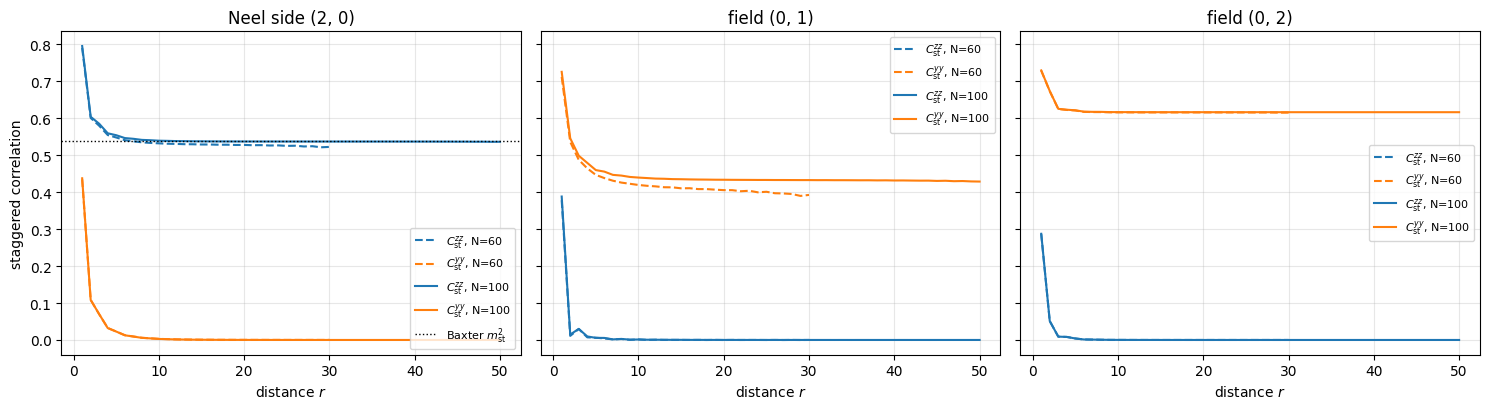

In [18]:
# ==============================================================================
# EXPERIMENT: long-range order in the XXZ chain in a transverse field, N = 60 and 100
# ==============================================================================
POINTS_DMRG = {"Neel side (2, 0)": (2.0, 0.0, "01"), "field (0, 1)": (0.0, 1.0, "-"), "field (0, 2)": (0.0, 2.0, "-")}
CHI_PH = 64
lam_bax = np.arccosh(2.0); q_bax = np.exp(-lam_bax)
m_st_exact = np.prod([((1 - q_bax ** (2 * n)) / (1 + q_bax ** (2 * n))) ** 2 for n in range(1, 60)])
phys = {}
for N_ph in (60, 100):
    for label, (Delta_ph, hx_ph, pattern) in POINTS_DMRG.items():
        t0 = time.time()
        W_ph = xxz_mpo(N_ph, 1.0, 1.0, Delta_ph, hx=hx_ph)
        B_ph, lam_ph, h_ph = dmrg(W_ph, product_mps((pattern * N_ph)[:N_ph], CHI_PH)[0], CHI_PH, 6)
        i0, rs = N_ph // 4, np.arange(1, N_ph // 2 + 1)
        czz = np.array([(-1) ** r * float(mps_correlator(B_ph, lam_ph, Z, i0, Z, i0 + r)) for r in rs])
        cyy = np.array([(-1) ** r * float(mps_correlator(B_ph, lam_ph, Y, i0, Y, i0 + r)) for r in rs])
        if (label, N_ph) == ("Neel side (2, 0)", 100):
            lam_ph_neel100 = lam_ph
        phys[(label, N_ph)] = dict(E=h_ph[-1][3], czz=czz, cyy=cyy, rs=rs, eps=max(h[4] for h in h_ph if h[0] == 5),
                                   dE=h_ph[-1][3] - [h[3] for h in h_ph if h[0] == 4][-1])
        z_loc = float(jnp.max(jnp.abs(mps_expect_sites(B_ph, lam_ph, Z))))
        y_loc = float(jnp.max(jnp.abs(mps_expect_sites(B_ph, lam_ph, Y))))
        print(f"N={N_ph:3d} {label:17s}: E = {h_ph[-1][3]:.8f} (change in the last sweep {phys[(label, N_ph)]['dE']:.0e}), largest discarded weight "
              f"{phys[(label, N_ph)]['eps']:.0e}, C_zz_st(r=1) = {czz[0]:+.4f}, C_zz_st(N/2) = {czz[-1]:+.4f}, C_yy_st(N/2) = {cyy[-1]:+.4f}   [{time.time() - t0:.0f} s]")
        tag = "symmetric" if z_loc < 1e-3 else "not yet symmetric: incomplete convergence (see below)"
        print(f"     {'':17s}  max_j |<Z_j>| = {z_loc:.1e}, max_j |<Y_j>| = {y_loc:.1e}   ({tag})")
print(f"\nBaxter: m_st = {m_st_exact:.4f},  m_st^2 = {m_st_exact ** 2:.4f};   DMRG at N=100: C_zz_st(r=50) = "
      f"{phys[('Neel side (2, 0)', 100)]['czz'][-1]:.4f}, relative deviation "
      f"{abs(phys[('Neel side (2, 0)', 100)]['czz'][-1] - m_st_exact ** 2) / m_st_exact ** 2:.1%}")

# the N=100 Neel point once more, with EIGHT sweeps instead of six: is the residual <Z_j> physics or incomplete convergence?
t0 = time.time()
B_8s, lam_8s, h_8s = dmrg(xxz_mpo(100, 1.0, 1.0, 2.0, hx=0.0), product_mps("01" * 50, CHI_PH)[0], CHI_PH, 8)
czz_8s = (-1) ** 50 * float(mps_correlator(B_8s, lam_8s, Z, 25, Z, 75))
print(f"N=100 Neel side, 8 sweeps: E = {h_8s[-1][3]:.8f} (change in the last sweep {h_8s[-1][3] - [h[3] for h in h_8s if h[0] == 6][-1]:.0e}), "
      f"max_j |<Z_j>| = {float(jnp.max(jnp.abs(mps_expect_sites(B_8s, lam_8s, Z)))):.1e}, central entropy {float(mps_entropies(lam_8s)[50]):.4f} bits "
      f"(6 sweeps: {float(mps_entropies(lam_ph_neel100)[50]):.4f}), C_zz_st(r=50) = {czz_8s:.4f}   [{time.time() - t0:.0f} s]")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, label in zip(axes, POINTS_DMRG):
    for N_ph, ls in ((60, "--"), (100, "-")):
        d = phys[(label, N_ph)]
        ax.plot(d["rs"], d["czz"], ls, color="C0", label=rf"$C^{{zz}}_{{\rm st}}$, N={N_ph}")
        ax.plot(d["rs"], d["cyy"], ls, color="C1", label=rf"$C^{{yy}}_{{\rm st}}$, N={N_ph}")
    if "Neel" in label:
        ax.axhline(m_st_exact ** 2, color="k", ls=":", lw=1, label=r"Baxter $m_{\rm st}^2$")
    ax.set_title(label); ax.set_xlabel("distance $r$"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[0].set_ylabel("staggered correlation")
plt.tight_layout(); plt.show()

**The answers.**

* **Néel order at $\Delta=2$.** $C^{zz}_{\rm st}(r)$ drops from $0.80$ at $r=1$ to a plateau that stays flat out to $r=50$, at $0.537$ for $N=100$ — within $0.3\,\%$ of Baxter's $m_{\rm st}^2=0.538$. The chain has
  long-range Néel order, and DMRG reproduces the exact order parameter. The $y$ correlations fall to $3\times10^{-3}$ at $r=10$ and below $10^{-3}$ at $r=20$.
* **Field-induced order along $y$.** At $(0,1)$ the $zz$ correlations vanish within a few sites, while $C^{yy}_{\rm st}(r)$ settles at about $0.43$ at $N=100$, decreasing only from $0.440$ at $r=10$ to
  $0.429$ at $r=50$. At $N=60$ it is lower, $0.420$ at $r=10$ and $0.393$ at $r=30$, so at this point the height of the plateau still depends on the length of the chain. At $(0,2)$ the plateau is
  $0.62$ at both lengths. The transverse field has produced long-range antiferromagnetic order along $y$, the direction perpendicular to the anisotropy axis and to the field — the prediction of Dmitriev
  et al. The hints from the parity splitting at $N=18$ in notebook 11 were real.
* **Why DMRG could do this.** Both ordered phases are gapped according to the exact (des Cloizeaux and Gaudin) and field-theoretical (Dmitriev et al.) results, so they obey an area law (Section 2), and
  $\chi=64$ is ample: the largest discarded weight of the last sweep lies between $2\times10^{-13}$ and $9\times10^{-10}$ at the six points. The same calculation for the critical XX chain needs more
  Schmidt values, as the validation showed.

> **Physics insight.** A finite chain has no spontaneous symmetry breaking (notebook 11), so one expects $\langle Z_j\rangle=\langle Y_j\rangle=0$, and the order to show up only in the correlations — which is why
> the order parameter is measured as the long-distance limit of $C_{\rm st}(r)$ and not as a single expectation value. The printed values follow this at $N=60$ ($\max_j|\langle Z_j\rangle|\sim10^{-10}$) and in the
> field, but the six-sweep run at $N=100$ on the Néel side ends with $\max_j|\langle Z_j\rangle|$ of order $0.1$. The sweeps start from the Néel product state, one side of the doublet, and at a hundred
> spins six sweeps do not complete the way to the symmetric ground state: the last sweep still lowers the energy by far more than the discarded weight, and the central entropy is below that of
> the symmetric state at $N=60$. The eight-sweep rerun printed above settles it: the energy drops further, the change of the last sweep falls to $10^{-8}$, $\max_j|\langle Z_j\rangle|$ drops to
> $10^{-2}$ or below, and the central entropy rises to $1.41$ bits. The residual magnetisation is incomplete convergence, and its size changes from run to run ($0.19$ and $0.08$ for the same six-sweep
> calculation two weeks apart). The staggered correlations agree to four digits in all these runs, which is exactly why they, and not $\langle Z_j\rangle$, are used to detect the order, and why a
> converged energy, not a fixed number of sweeps, is the stopping criterion to use in production.

## 7. One TEBD step on an MPS: the two-site update

### 7.1 Derivation

TEBD applies two-site gates $G=e^{-i h_{j,j+1}\delta t}$ (a $4\times4$ unitary, reshaped to $G[s,t,s',t']$ with outputs first, exactly the
convention of the engine's `apply_gate`). On the state vector the gate was contracted with two of the $N$ legs of $\psi$.
On an MPS the two physical legs $s_j,s_{j+1}$ belong to two neighbouring tensors, and nothing else is touched:
```
 (a) merge two sites, weight with Lambda[j]      (b) apply the gate        (c) SVD, keep chi values, split

          s      t                                    s      t
          |      |                                    |      |                     s              t
  a --<L>--[B_j]--[B_j+1]-- b                       +----------+                   |              |
                                                    |    G     |           a --[ U ]-- k --<S>-- k --[ V^dag ]-- b
     theta[a,s,t,b]                                 +----------+
                                                      |      |
                                              a --<L>--[B_j]--[B_j+1]-- b
```
**(a) Merge.** $C_{a,s,t,b}=\sum_m B^{[j]}_{a,s,m}B^{[j+1]}_{m,t,b}$, and $\theta_{a,s,t,b}=\lambda^{[j]}_a\,C_{a,s,t,b}$.
Why the factor $\lambda^{[j]}$? By Eq. (5), $\Lambda^{[j]}$ can be pushed through from the left end:
$B^{[0]}B^{[1]}\cdots = A^{[0]}\cdots A^{[j-1]}\,\Lambda^{[j]}B^{[j]}B^{[j+1]}\cdots$. So $\theta$ is the state expressed in the
orthonormal bases $|L_a\rangle$ (left block), $|s\rangle|t\rangle$, $|R_b\rangle$ (right block): the mixed-canonical form centred on the two sites. Its
$4\chi^2$ numbers are the complete wave function in a (small) orthonormal basis, so $\sum|\theta|^2=1$.

**(b) Gate.** $\theta'_{a,s,t,b}=\sum_{s't'}G_{s,t,s',t'}\theta_{a,s',t',b}$ - the same contraction as `apply_gate`, on a tiny tensor.

**(c) Split.** Reshape $\theta'$ into a $2\chi\times2\chi$ matrix with rows $(a,s)$ and columns $(t,b)$ and compute
$\theta'=USV^\dagger$. Because the bases are orthonormal, the singular values $S_k$ are the **new Schmidt values** of the cut between $j$ and
$j+1$. There can be up to $2\chi$ of them: *a gate can double the bond dimension*. We keep the $\chi$ largest,

$$ \lambda'^{[j+1]}_k=\frac{S_k}{\sqrt{\sum_{k'\le\chi}S_{k'}^2}},\qquad \varepsilon=\frac{\sum_{k>\chi}S_k^2}{\sum_k S_k^2},\qquad B'^{[j+1]}_{k,t,b}=V^\dagger_{k,(t,b)} , $$

and the new $B'^{[j+1]}$ is right-canonical because the rows of $V^\dagger$ are orthonormal. The left tensor in Vidal's form would
be $A'^{[j]}=U$, i.e. in our right-canonical storage $B'^{[j]}=(\Lambda^{[j]})^{-1}U S$. **This division by Schmidt values is the
notorious weak spot of the original algorithm**: small $\lambda$'s (the very ones that make truncation possible) amplify
rounding errors, and the padded zeros would give $0/0$.

**The trick of Hastings.** Multiply $\theta'=USV^\dagger$ from the right by $V$ and use $V^\dagger V=1$: $\;US=\theta'V$. Hence

$$ B'^{[j]} = (\Lambda^{[j]})^{-1}US=(\Lambda^{[j]})^{-1}\theta' V = C'\,V,\qquad C'=G\cdot C, $$

where $C'$ is the gate applied to the merged tensor **without** the factor $\lambda^{[j]}$ - the inverse has cancelled
analytically. In index form $B'^{[j]}_{a,s,k}=\sum_{t,b}C'_{a,s,t,b}\,\big(B'^{[j+1]}_{k,t,b}\big)^*$ (divided by the same norm as $\lambda'$),
using $V_{(tb),k}=\big(V^\dagger_{k,(tb)}\big)^*$.

### 7.2 What the update does *not* restore

Three consequences of the truncation deserve to be stated before we write the code, because they decide how the
results of Sec. 10 must be read.

1. **The MPS is renormalised at every truncation.** Dividing by $\sqrt{\sum_{k\le\chi}S_k^2}$ makes $\sum_k\lambda'^2_k=1$
   again, so $\langle\tilde\psi\vert\tilde\psi\rangle=1$ after every gate. The discarded weight therefore never shows up as a
   loss of norm: a norm of exactly one is no evidence that nothing was thrown away. The error is a change of
   *direction* of the state, and only the accumulated $\varepsilon$'s record it.
2. **$\lambda^{[j]}$ is not re-measured.** The update writes the new Schmidt values of the bond *between* the two
   sites; the Schmidt values of the bond to their left are left untouched. For a unitary gate this is exact - a
   unitary acting on sites $j,j+1$ does not change the reduced density matrix of the block $0..j-1$, hence not its
   eigenvalues $\lambda^{[j]2}_a$. After a truncation the state *has* changed, and the stored $\lambda^{[j]}$ is
   wrong by $O(\varepsilon)$.
3. **The new left tensor is right-canonical only up to the truncation.** Without truncation $B'^{[j]}=(\Lambda^{[j]})^{-1}US$
   satisfies Eq. (3) exactly, because $\sum_{s,t,b}\theta'\theta'^*=\lambda^{[j]2}_a\delta_{aa'}$. With truncation the
   missing piece is divided by $\lambda^{[j]}_a\lambda^{[j]}_{a'}$, so the violation of Eq. (3) is **not** $O(\varepsilon)$ but
   $O(\varepsilon/\lambda_{\min}^2)$, where $\lambda_{\min}$ is the smallest *kept* Schmidt value - the small Schmidt values that
   the algebra removed from the formula come back in the error. The checkpoint below measures it: discarding a
   weight $\varepsilon=0.054$ with $\lambda_{\min}=0.283$ leaves the canonical condition violated by $0.25$: the naive $O(\varepsilon)$ would be $0.05$, the amplified
   estimate $\varepsilon/\lambda_{\min}^2$ is $0.67$.
   This is what "TEBD loses the canonical form" means; for the small $\varepsilon$ of a converged run it is harmless
   (Sec. 10.2 ends with a total discarded weight of $2\times10^{-6}$ after 120 steps), and Sec. 12 says when it is not.

### 7.3 From formula to code

| step | formula | einsum |
|---|---|---|
| merge | $C=B^{[j]}B^{[j+1]}$ | `"asm,mtb->astb"` |
| gate  | $C'=G\,C$ | `"stuv,auvb->astb"` |
| weight| $\theta'=\lambda^{[j]}C'$ | broadcasting `lamL[:,None,None,None] * C` |
| split | SVD of $\theta'$ as a $(2\chi,2\chi)$ matrix | `jnp.linalg.svd` |
| new left tensor | $B'^{[j]}=C'V$ | `"astb,ktb->ask"` with `conj(B2_new)` |

All shapes are fixed by $\chi$, there is no Python branching on data, so the function can be jit-compiled and vmapped.
One detail concerns the padding. For a singular value that is *zero*, the corresponding row of $V^\dagger$ is an arbitrary
unit vector chosen by the SVD routine; it multiplies zero, so it is harmless, but we mask it to zero
(`jnp.where`-style multiplication with a 0/1 mask) so that padded entries stay exactly zero.

In [19]:
# ==============================================================================
# STEP 4: the core routine -- TEBD two-site update (merge, gate, SVD, truncate, split)
# ==============================================================================
LAM_CUT = 100 * float(jnp.finfo(RDTYPE).eps)      # Schmidt values below this are treated as padding (exact zeros)


def two_site_update(lamL, B1, B2, G):
    """Apply a two-site gate to neighbouring MPS tensors and truncate back to bond dimension chi.

    MATH
        C[a,s,t,b]      = sum_{m,s',t'} G[s,t,s',t'] B1[a,s',m] B2[m,t',b]        (merge + gate)
        theta[a,s,t,b]  = lamL[a] C[a,s,t,b]                                       (mixed-canonical wave function)
        theta_{(as),(tb)} = sum_k U_{(as),k} S_k Vh_{k,(tb)}                       (SVD; S = new Schmidt values)
        keep k < chi:   lam' = S/||S_kept||,  B2' = Vh,  B1' = C . conj(B2') / ||S_kept||   (Hastings: no 1/lam)
        eps = sum_{k>=chi} S_k^2 / sum_k S_k^2                                     (discarded weight)
    ARGUMENTS   lamL (chi,) Schmidt values LEFT of the first site; B1, B2 (chi,2,chi); G (2,2,2,2) = U4.reshape.
    RETURNS     B1', B2', lam' (Schmidt values of the bond between the two sites), eps.
    COST        SVD of a (2chi x 2chi) matrix: O(chi^3); contractions O(chi^3).
    JAX         static shapes (chi is the array size, never data-dependent) -> jit / vmap / scan friendly.
    """
    chi = B1.shape[0]
    C = jnp.einsum("asm,mtb->astb", B1, B2)                           # (a) merge the two sites
    C = jnp.einsum("stuv,auvb->astb", G, C)                           # (b) apply the gate
    theta = lamL[:, None, None, None] * C                             #     weight with the left Schmidt values
    U, S, Vh = jnp.linalg.svd(theta.reshape(2 * chi, 2 * chi), full_matrices=False)   # (c) split
    weight = S ** 2
    kept = jnp.sum(weight[:chi])
    eps = jnp.sum(weight[chi:]) / jnp.sum(weight)                     # discarded Schmidt weight (never negative)
    nrm = jnp.sqrt(kept)
    lam_new = S[:chi] / nrm                                           # truncate + renormalise to norm 1
    mask = lam_new > LAM_CUT                                          # True on used bond indices, False on padding
    lam_new = jnp.where(mask, lam_new, 0.0)
    B2_new = Vh[:chi].reshape(chi, 2, chi) * mask[:, None, None]      # right-canonical by construction
    B1_new = jnp.einsum("astb,ktb->ask", C, jnp.conj(B2_new)) / nrm   # Hastings: C.V instead of (1/lam) U S
    return B1_new, B2_new, lam_new.astype(lamL.dtype), eps


two_site_update_jit = jax.jit(two_site_update)

**Checkpoint.** Never trust an update you have not tested. We take a random 6-spin state, convert it *exactly* to a
padded MPS ($\chi=8=2^{N/2}$), apply a gate $e^{-i h\,\tau}$ with $h=XX+YY+ZZ$ to the central bond (sites 2,3) with our
update, and compare with the engine's `apply_gate` acting on the state vector. We also check that the
returned $\lambda'$ are the true Schmidt values of the new state, that nothing was discarded, and that the new tensors
are right-canonical.

In [20]:
# ------------------------------------------------------------------------------
# CHECKPOINT: two_site_update vs apply_gate on the full state vector (N=6, chi=8: exact)
# ------------------------------------------------------------------------------
def expm_herm(h, tau):
    """exp(-i tau h) for a small Hermitian matrix via its eigendecomposition h = V w V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T


N_T, CHI_T, j_T = 6, 8, 2
psi_t = haar_state(jax.random.PRNGKey(3), N_T)
G4 = expm_herm(XX + YY + ZZ, 0.37)                                     # some generic two-site unitary
B_t, lam_t, _ = state_to_mps(psi_t, CHI_T)
B1n, B2n, lam_n, eps_n = two_site_update_jit(lam_t[j_T], B_t[j_T], B_t[j_T + 1], G4.reshape(2, 2, 2, 2))
B_new = B_t.at[j_T].set(B1n).at[j_T + 1].set(B2n)                      # functional update: returns a new array
psi_ref = apply_gate(psi_t, G4, [j_T, j_T + 1])

err_state = float(jnp.max(jnp.abs(mps_to_state(B_new) - psi_ref)))
err_lam = float(jnp.max(jnp.abs(lam_n - schmidt_values(psi_ref, range(j_T + 1)))))
gram = jnp.einsum("asb,csb->ac", B1n, jnp.conj(B1n))
err_can = float(jnp.max(jnp.abs(gram - jnp.diag((lam_t[j_T] > 0).astype(RDTYPE)))))
print(f"state after the gate, MPS vs state vector : {err_state:.1e}")
print(f"new Schmidt values vs engine              : {err_lam:.1e}")
print(f"new left tensor right-canonical           : {err_can:.1e}")
print(f"discarded weight                          : {float(eps_n):.1e}")
assert max(err_state, err_lam, err_can, abs(float(eps_n))) < 10 * TOL

# ------------------------------------------------------------------------------
# CHECKPOINT: the TRUNCATING branch.  The test above discarded nothing, so it could not have caught an error in
# the truncation, the renormalisation or the discarded-weight formula.  Here chi is smaller than the Schmidt rank
# the gate produces, and the reference is the optimal rank-chi approximation computed by a dense SVD.
# ------------------------------------------------------------------------------
CHI_TR = 4
B_lo, _, _ = state_to_mps(psi_t, CHI_TR)                               # a state the chi=4 format holds EXACTLY
psi_lo = mps_to_state(B_lo)                                            # ... namely this one
B_r, lam_r, eps_r = state_to_mps(psi_lo, CHI_TR)                       # re-convert: nothing is discarded now
assert np.sum(eps_r) < TOL
B1t, B2t, lam_t2, eps_t2 = two_site_update_jit(lam_r[j_T], B_r[j_T], B_r[j_T + 1], G4.reshape(2, 2, 2, 2))
B_tr = B_r.at[j_T].set(B1t).at[j_T + 1].set(B2t)

M_ref = np.asarray(apply_gate(psi_lo, G4, [j_T, j_T + 1])).reshape(2 ** (j_T + 1), -1)   # dense reference
Uc, Sc, Vc = np.linalg.svd(M_ref, full_matrices=False)                 # its exact Schmidt decomposition
best = (Uc[:, :CHI_TR] * Sc[:CHI_TR]) @ Vc[:CHI_TR]                    # Eckart-Young optimum, renormalised
best = best / np.linalg.norm(best)
err_best = float(jnp.max(jnp.abs(mps_to_state(B_tr).reshape(M_ref.shape) - best)))
err_eps = abs(float(eps_t2) - np.sum(Sc[CHI_TR:] ** 2) / np.sum(Sc ** 2))
err_lam2 = float(jnp.max(jnp.abs(lam_t2 - Sc[:CHI_TR] / np.linalg.norm(Sc[:CHI_TR]))))
gram_tr = jnp.einsum("asb,csb->ac", B1t, jnp.conj(B1t))
dev_can = float(jnp.max(jnp.abs(gram_tr - jnp.diag((lam_r[j_T] > 0).astype(RDTYPE)))))
print(f"\ntruncating update, chi={CHI_TR}: discarded weight {float(eps_t2):.4f}")
print(f"  distance to the optimal rank-{CHI_TR} state : {err_best:.1e}")
print(f"  |eps - true discarded weight|             : {err_eps:.1e}")
print(f"  |lam' - true Schmidt values|              : {err_lam2:.1e}")
print(f"  norm of the truncated MPS                 : {float(jnp.linalg.norm(mps_to_state(B_tr))):.12f}")
lam_min = float(jnp.min(lam_t2[lam_t2 > LAM_CUT]))
print(f"  smallest KEPT Schmidt value               : {lam_min:.3f}  ->  eps/lam_min^2 = {float(eps_t2) / lam_min ** 2:.2f}")
print(f"  violation of Eq. (3) by the new B[{j_T}]      : {dev_can:.2f}  (Sec. 7.2, point 3: not O(eps) = {float(eps_t2):.2f})")
assert float(eps_t2) > 1e-2                                            # the test is worthless if nothing is cut
assert max(err_best, err_eps, err_lam2) < 100 * TOL and dev_can > 1e-2

state after the gate, MPS vs state vector : 5.3e-16
new Schmidt values vs engine              : 5.0e-16
new left tensor right-canonical           : 1.4e-15
discarded weight                          : 0.0e+00



truncating update, chi=4: discarded weight 0.0536
  distance to the optimal rank-4 state : 1.2e-15
  |eps - true discarded weight|             : 8.3e-17
  |lam' - true Schmidt values|              : 2.2e-16
  norm of the truncated MPS                 : 1.000000000000


  smallest KEPT Schmidt value               : 0.283  ->  eps/lam_min^2 = 0.67
  violation of Eq. (3) by the new B[2]      : 0.25  (Sec. 7.2, point 3: not O(eps) = 0.05)


All four numbers of the first test are at the level of rounding errors: the update is an *exact* rewriting of the
gate as long as $\chi$ can hold the new Schmidt rank. (SVDs are unique only up to phases of the singular vectors, so
the *tensors* may differ from those of another code, but the *state* does not - which is why we compare states, not
tensors.)

The second test switches the truncation on. It confirms three separate things that the first test could not:
the truncated MPS is the *optimal* rank-$\chi$ state (Eckart-Young, to $10^{-16}$), the returned $\varepsilon$ is the true
discarded weight, and the state comes back normalised. It also shows the price: after discarding $5.4\,\%$ of the
weight the largest entry of $\sum_{s,b}B'_{a,s,b}B'^*_{a',s,b}-\delta_{aa'}$ is $0.25$ - five times $\varepsilon$, and of the order of the amplified
estimate $\varepsilon/\lambda_{\min}^2=0.67$ of Sec. 7.2 with the smallest kept Schmidt value $\lambda_{\min}=0.283$ (printed above).

> **Common pitfall.** The index order in the reshape before the SVD must be (left bond, left spin) x (right spin,
> right bond). Our tensors are stored as `[a, s, b]` precisely so that `theta.reshape(2*chi, 2*chi)`,
> `U.reshape(chi, 2, -1)` and `Vh.reshape(-1, 2, chi)` group the right legs with C-ordering - no `transpose` needed.

## 8. The full algorithm: layers with `vmap`, time steps with `scan`

### 8.1 Even/odd splitting and the Trotter scheme

Exactly as in [notebook 12 (Chapter 5)](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb) we split the nearest-neighbour Hamiltonian
into even and odd bonds, $H=H_{\rm even}+H_{\rm odd}$, $H_{\rm even}=\sum_{j\ {\rm even}}h_{j,j+1}$. Terms inside one group act on
disjoint pairs of spins and commute, so $e^{-iH_{\rm even}\tau}=\prod_{j\,\rm even}e^{-ih_{j,j+1}\tau}$ exactly. The
second-order (Strang) step is

$$ e^{-iH\delta t}=e^{-iH_{\rm even}\delta t/2}\,e^{-iH_{\rm odd}\delta t}\,e^{-iH_{\rm even}\delta t/2}+O(\delta t^3). $$

One step is a brick wall of gates, one row per layer, time running upwards (six spins):
```
  time
   ^   [ dt/2 ]   [ dt/2 ]   [ dt/2 ]     even bonds (0,1) (2,3) (4,5)   <- one vmap
   |        [  dt  ]   [  dt  ]           odd bonds  (1,2) (3,4)         <- one vmap
   |   [ dt/2 ]   [ dt/2 ]   [ dt/2 ]     even bonds again               <- one vmap
       0     1   2     3   4     5        site
```
The gates within a row act on disjoint pairs and commute; the three rows do not commute with each other, which is
where the $O(\delta t^3)$ error per step comes from.

On an MPS this structure has a second, purely computational advantage: **the updates inside a layer are
independent** - the update of bond $(j,j+1)$ reads `lam[j]`, `B[j]`, `B[j+1]` and writes `B[j]`, `B[j+1]`, `lam[j+1]`, and
`lam[j]` belongs to a bond of the *other* parity, which the layer does not modify. Independent updates of identical shape:
this is what `jax.vmap` is for. We gather the tensors of all even (or odd) bonds with integer-array indexing
`B[idx]`, call the vmapped update once, and scatter the results back with `B.at[idx].set(...)`.

The physics behind "independent" is worth one more sentence, because the updates all read the MPS as it was at the
*start* of the layer. Applying the gate on bond $(j,j+1)$ is a unitary on sites $j,j+1$; it conjugates the reduced
density matrix of the block $0..j+1$ and therefore leaves the Schmidt values of every *other* cut unchanged, and it
leaves all tensors outside the pair untouched. So the data `lam[j']`, `B[j']`, `B[j'+1]` that the update of another
bond $j'$ of the same parity reads are still the correct mixed-canonical data of the updated state, and the layer
may be executed in any order or all at once. This is exact for the gates; the truncations that follow them change
the state, so within a layer the mixed-canonical data of the *other* bonds are correct only to $O(\varepsilon)$ - one more
entry in the list of Sec. 7.2.

The index arithmetic is the same for even and odd $N$: `jnp.arange(0, N-1, 2)` and `jnp.arange(1, N-1, 2)` together
list every bond exactly once, the last bond $N-2$ falling in the even group for even $N$ and in the odd group for odd $N$,
and the left end is covered because bond 0 reads `lam[0] = (1, 0, ..., 0)`, the dummy bond of dimension one.

Single-site fields are absorbed into the bond terms so that the Hamiltonian is a pure sum of two-site operators:
each site's field is shared equally between its two bonds (the end sites give everything to their only bond),

$$\begin{aligned} h_{j,j+1}&=J_x\,XX+J_y\,YY+J_z\,ZZ+c^L_j\,(h_xX+h_zZ)\otimes1+c^R_j\,1\otimes(h_xX+h_zZ), \\
c^{L}_j&=\tfrac12\ \ (1\ \text{if } j=0), \qquad c^{R}_j=\tfrac12\ \ (1\ \text{if } j=N-2). \end{aligned}$$

Every site then receives its field exactly once: site 0 from bond 0 with weight 1, site $N-1$ from bond $N-2$ with
weight 1, and every interior site $m$ from bonds $m-1$ and $m$ with weight $\tfrac12$ each.

In [21]:
# ==============================================================================
# STEP 6: Hamiltonian as N-1 bond matrices, gates, and one vmapped layer
# ==============================================================================
def bond_hamiltonians(N, Jxx=0.0, Jyy=0.0, Jzz=0.0, hx=0.0, hz=0.0):
    """Two-site terms h_j (array (N-1,4,4)) with  sum_j h_j = H,
        H = sum_j (Jxx XX + Jyy YY + Jzz ZZ)_{j,j+1} + sum_j (hx X_j + hz Z_j)      (Pauli convention, open chain).
    The single-site fields are split equally between the two bonds that contain the site."""
    one = hx * X + hz * Z
    hs = []
    for j in range(N - 1):
        cL = 1.0 if j == 0 else 0.5
        cR = 1.0 if j == N - 2 else 0.5
        hs.append(Jxx * XX + Jyy * YY + Jzz * ZZ + cL * jnp.kron(one, I2) + cR * jnp.kron(I2, one))
    return jnp.stack(hs)


def bond_gates(h_bonds, tau):
    """exp(-i tau h_j) for every bond, as rank-4 gate tensors G[j][s,t,s',t'] (shape (N-1,2,2,2,2)).
    JAX: vmap turns the single-matrix function expm_herm into a batched one."""
    return jax.vmap(lambda h: expm_herm(h, tau))(h_bonds).reshape(-1, 2, 2, 2, 2)


def tebd_layer(B, lam, G, idx):
    """Apply the gates G[k] to the bonds (idx[k], idx[k]+1) -- all bonds of one parity, in parallel.
    JAX   gather with integer-array indexing, ONE vmapped two_site_update (batched einsums + batched SVD),
          scatter with .at[].set().
    RETURNS  the new (B, lam), the summed discarded weight sum_b eps_b of the layer, and sum_b sqrt(eps_b),
             the quantity that enters the triangle-inequality error estimate of Sec. 9."""
    B1, B2, lam_new, eps = jax.vmap(two_site_update)(lam[idx], B[idx], B[idx + 1], G)
    B = B.at[idx].set(B1).at[idx + 1].set(B2)
    lam = lam.at[idx + 1].set(lam_new)
    return B, lam, jnp.sum(eps), jnp.sum(jnp.sqrt(eps))

### 8.2 The time loop

One Strang step is three layers (even half step, odd full step, even half step). The time loop is a `lax.scan`
whose carry is the pair `(B, lam)` - legal because the shapes never change - and whose per-step output is a
dictionary of measurements: the magnetisation profile $\langle Z_j\rangle$, the entropies of all cuts, the energy, and the discarded
weight of the step. The whole evolution, measurements included, becomes **one compiled XLA program**; the gates and
bond Hamiltonians are ordinary (traced) array arguments, so the same compiled program serves *any* nearest-neighbour
model with the same `N`, `chi` and `n_steps`.

In [22]:
# ==============================================================================
# STEP 7: the complete MPS-TEBD time evolution (2nd-order Trotter), one jit-compiled program
# ==============================================================================
@partial(jax.jit, static_argnames=("n_steps",))
def mps_tebd_evolve(B, lam, h_bonds, dt, n_steps):
    """Evolve a padded MPS for n_steps Strang steps  e^{-i H_even dt/2} e^{-i H_odd dt} e^{-i H_even dt/2}.

    RETURNS   (B, lam) at the final time and a dict of arrays with leading axis = time step:
        "z"    (n_steps, N)     <Z_j>                      "S"   (n_steps, N+1) entanglement entropy of every cut
        "E"    (n_steps,)       energy <H>                 "eps" (n_steps,)     discarded weight summed over the step
        "sqeps" (n_steps,)      sum of sqrt(eps) over the ~1.5 N truncations of the step  (Sec. 9)
    COST      per step ~ 1.5 N SVDs of (2chi x 2chi) matrices: O(N chi^3) time, O(N chi^2) memory.
    JAX       lax.scan over time (carry = MPS of fixed shape), vmap over the bonds of a layer, jit around everything.
    """
    N = B.shape[0]
    even, odd = jnp.arange(0, N - 1, 2), jnp.arange(1, N - 1, 2)
    G_half, G_full = bond_gates(h_bonds, dt / 2), bond_gates(h_bonds, dt)

    def step(carry, _):
        B, lam = carry
        B, lam, e1, q1 = tebd_layer(B, lam, G_half[even], even)
        B, lam, e2, q2 = tebd_layer(B, lam, G_full[odd], odd)
        B, lam, e3, q3 = tebd_layer(B, lam, G_half[even], even)
        out = {"z": mps_expect_sites(B, lam, Z), "S": mps_entropies(lam),
               "E": jnp.sum(mps_expect_bonds(B, lam, h_bonds)), "eps": e1 + e2 + e3, "sqeps": q1 + q2 + q3}
        return (B, lam), out

    return lax.scan(step, (B, lam), None, length=n_steps)

> **JAX practice.** `n_steps` is declared static because `lax.scan` needs the loop length at compile time; `dt` and
> `h_bonds` are traced, so changing the model or the time step does **not** trigger a recompilation. The index arrays
> `even`, `odd` are built from `B.shape[0]`, a static Python integer under `jit`. See
> [notebook 01 (Chapter 1)](../ch01_computational_toolbox/01_jax_from_scratch.ipynb) for `jit`/`vmap`/`scan` basics.

> **Numerical practice.** Two consecutive Strang steps end and begin with a half step on the even bonds; merging
> them into one full step saves a third of the SVDs when no measurement is needed in between. We keep the three-layer
> form because we measure after every step and because it matches the state-vector reference *gate by gate*.

## 9. Validation against the state-vector TEBD

**Set-up.** Transverse-field Ising chain at its critical point, $H=-\sum_jZ_jZ_{j+1}-\sum_jX_j$ (in the engine's
convention `Jzz=-1, hx=-1`), $N=12$, initial state all spins up, $\delta t=0.05$, 80 steps ($t\le4$). The reference is the
engine's `tebd_evolve` on the full state vector. To make the comparison sharp we feed it **the same bond terms in the
same even-then-odd order**: its second-order rule (half steps through the list, then through the reversed list) then
gives $E(\delta t/2)O(\delta t/2)O(\delta t/2)E(\delta t/2)=E(\delta t/2)O(\delta t)E(\delta t/2)$ - the identical Trotter
decomposition. Any difference between the two simulations is then **purely the MPS truncation** (plus rounding).

First a checkpoint that the absorbed-field bond terms sum to the Hamiltonian that `heisenberg_terms` defines.

In [23]:
# ==============================================================================
# PARAMETERS of the validation run
# ==============================================================================
N_V, DT_V, STEPS_V = 12, 0.05, 80
JZZ_V, HX_V = -1.0, -1.0                                   # critical transverse-field Ising chain
SPEC_V = "0" * N_V                                         # all spins up

h_v = bond_hamiltonians(N_V, Jzz=JZZ_V, hx=HX_V)
order_v = list(range(0, N_V - 1, 2)) + list(range(1, N_V - 1, 2))          # even bonds first, then odd bonds
terms_v = [((j, j + 1), h_v[j]) for j in order_v]                          # engine-style list of local terms

# CHECKPOINT: same Hamiltonian as the engine's heisenberg_terms (compare <H> in a random state)
psi_r = haar_state(jax.random.PRNGKey(11), N_V)
dE = float(jnp.abs(energy(terms_v, psi_r) - energy(heisenberg_terms(N_V, 0.0, 0.0, JZZ_V, hx=HX_V), psi_r)))
print(f"bond terms with absorbed fields vs heisenberg_terms: |dE| = {dE:.1e}")
assert dE < TOL


# ------------------------------------------------------------------------------
# reference: state-vector TEBD from the engine, recording <Z_j> and the central entropy
# ------------------------------------------------------------------------------
def observe_sv(psi):
    z = jnp.stack([expect_local(psi, Z, [q]) for q in range(N_V)])
    return z, entanglement_entropy(psi, range(N_V // 2))


run_sv = jax.jit(lambda psi: tebd_evolve(psi, terms_v, DT_V, STEPS_V, order=2, observe=observe_sv))
psi_T, (z_sv, S_sv) = run_sv(product_state(SPEC_V))
times_v = DT_V * np.arange(1, STEPS_V + 1)

# ------------------------------------------------------------------------------
# MPS-TEBD with chi = 2^{N/2} = 64: no truncation possible -> must agree to rounding
# ------------------------------------------------------------------------------
B0, lam0 = product_mps(SPEC_V, 64)
(B_T, lam_T), out_v = mps_tebd_evolve(B0, lam0, h_v, DT_V, STEPS_V)
err_z = float(jnp.max(jnp.abs(out_v["z"] - z_sv)))
err_S = float(jnp.max(jnp.abs(out_v["S"][:, N_V // 2] - S_sv)))
infid = 1.0 - float(fidelity_pure(psi_T, mps_to_state(B_T)))
print(f"chi=64:  max |<Z_j>_MPS - <Z_j>_SV| over all sites and times = {err_z:.1e}")
print(f"         max |S_MPS - S_SV| at the central cut               = {err_S:.1e}")
print(f"         final-state infidelity 1-F = {infid:.1e},  total discarded weight = {float(jnp.sum(out_v['eps'])):.1e}")
assert err_z < 100 * TOL and err_S < 1e4 * TOL and abs(infid) < 100 * TOL

bond terms with absorbed fields vs heisenberg_terms: |dE| = 5.6e-17


chi=64:  max |<Z_j>_MPS - <Z_j>_SV| over all sites and times = 1.1e-13
         max |S_MPS - S_SV| at the central cut               = 3.5e-12
         final-state infidelity 1-F = 1.9e-12,  total discarded weight = 4.2e-28


With $\chi=64$ the MPS can hold *any* 12-spin state, nothing is discarded, and the two completely different
codes - one contracting gates into a $2^{12}$ tensor, the other doing 1360 SVDs on small tensors - agree to
$10^{-13}$ in every local observable and to a few $10^{-12}$ in the entropy and in the final-state infidelity. The Trotter
error is the same in both and cancels in the comparison.

Now we lower $\chi$ and watch the truncation error appear.

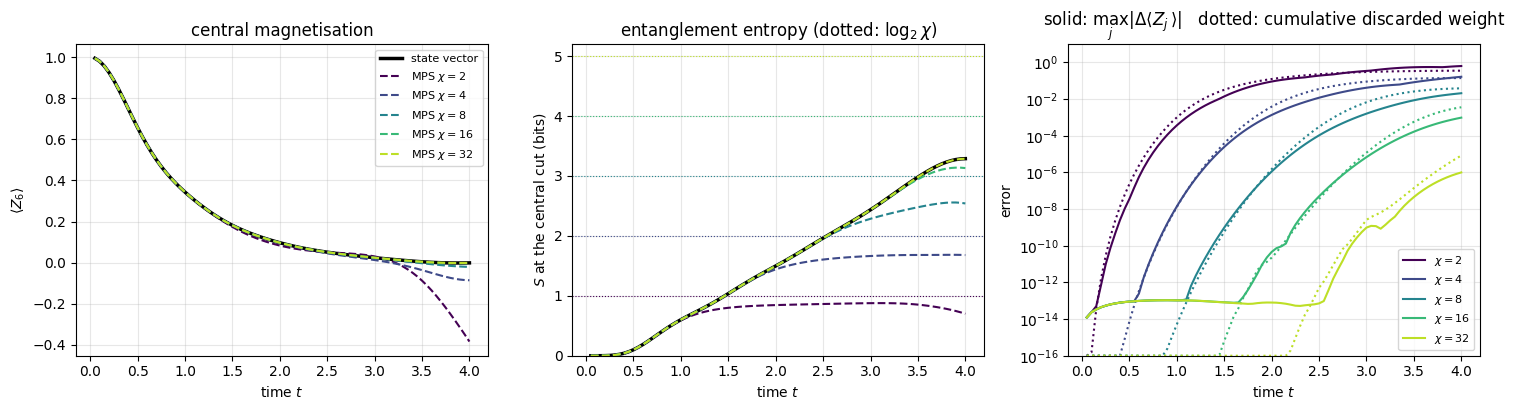

 chi |    sum eps |  final 1-F | (sum sqrt eps)^2 |   max |dZ| | S_mid(T) | log2 chi
   2 |   3.55e-01 |   9.44e-01 |         1.87e+02 |   6.38e-01 |   0.7004 |     1.00
   4 |   1.41e-01 |   8.16e-01 |         4.21e+01 |   1.66e-01 |   1.6801 |     2.00
   8 |   3.88e-02 |   3.81e-01 |         6.06e+00 |   2.10e-02 |   2.5412 |     3.00
  16 |   3.59e-03 |   5.22e-02 |         2.44e-01 |   9.75e-04 |   3.1317 |     4.00
  32 |   8.35e-06 |   7.91e-05 |         8.41e-05 |   1.00e-06 |   3.2871 |     5.00
  SV |            |            |                  |            |   3.2884 |


In [24]:
# ==============================================================================
# EXPERIMENT: dependence on the bond dimension  (N=12, exact reference available)
# ==============================================================================
CHIS_V = (2, 4, 8, 16, 32)
runs_v = {}
for chi_ in CHIS_V:
    B0, lam0 = product_mps(SPEC_V, chi_)
    (B_c, lam_c), out_c = mps_tebd_evolve(B0, lam0, h_v, DT_V, STEPS_V)
    runs_v[chi_] = {k: np.asarray(v) for k, v in out_c.items()}
    runs_v[chi_]["infid"] = 1.0 - float(fidelity_pure(psi_T, mps_to_state(B_c)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
colors = plt.cm.viridis(np.linspace(0.0, 0.9, len(CHIS_V)))
mid = N_V // 2
ax = axes[0]
ax.plot(times_v, z_sv[:, mid], "k-", lw=2.5, label="state vector")
for chi_, c in zip(CHIS_V, colors):
    ax.plot(times_v, runs_v[chi_]["z"][:, mid], "--", color=c, label=rf"MPS $\chi={chi_}$")
ax.set_xlabel("time $t$"); ax.set_ylabel(rf"$\langle Z_{{{mid}}}\rangle$"); ax.set_title("central magnetisation")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(times_v, S_sv, "k-", lw=2.5, label="state vector")
for chi_, c in zip(CHIS_V, colors):
    ax.plot(times_v, runs_v[chi_]["S"][:, mid], "--", color=c)
    ax.axhline(np.log2(chi_), color=c, lw=0.8, ls=":")
ax.set_xlabel("time $t$"); ax.set_ylabel("$S$ at the central cut (bits)")
ax.set_title(r"entanglement entropy (dotted: $\log_2\chi$)"); ax.set_ylim(0, 5.2); ax.grid(alpha=0.3)
ax = axes[2]
for chi_, c in zip(CHIS_V, colors):
    ax.semilogy(times_v, np.clip(np.max(np.abs(runs_v[chi_]["z"] - np.asarray(z_sv)), axis=1), 1e-16, None),
                "-", color=c, label=rf"$\chi={chi_}$")
    ax.semilogy(times_v, np.clip(np.cumsum(runs_v[chi_]["eps"]), 1e-16, None), ":", color=c)
ax.set_xlabel("time $t$"); ax.set_ylabel("error")
ax.set_title(r"solid: $\max_j|\Delta\langle Z_j\rangle|$   dotted: cumulative discarded weight")
ax.set_ylim(1e-16, 10); ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

print(f"{'chi':>4} | {'sum eps':>10} | {'final 1-F':>10} | {'(sum sqrt eps)^2':>16} | {'max |dZ|':>10} | {'S_mid(T)':>8} | {'log2 chi':>8}")
for chi_ in CHIS_V:
    r = runs_v[chi_]
    tri = np.sum(r["sqeps"]) ** 2                          # triangle-inequality estimate, Eq. (17) below
    print(f"{chi_:>4} | {np.sum(r['eps']):10.2e} | {r['infid']:10.2e} | {tri:16.2e} |"
          f" {np.max(np.abs(r['z'] - np.asarray(z_sv))):10.2e} | {r['S'][-1, mid]:8.4f} | {np.log2(chi_):8.2f}")
    assert r["infid"] > 2 * np.sum(r["eps"])               # the Sec. 3.5 bound is VIOLATED here -- see below
    assert r["infid"] < 2 * tri                            # the triangle-inequality estimate is not
print(f"  SV |            |            |                  |            | {float(S_sv[-1]):8.4f} |")

**Interpretation.** (Numbers are in the table above.)

- *Left*: $\chi=2$ and $\chi=4$ follow the exact curve up to $t\approx3$ and then drift away; from $\chi=8$ on the curves
  are indistinguishable from the state vector by eye on this scale.
- *Centre*: the entropy of an MPS can never exceed $\log_2\chi$ (dotted lines). As the true entropy (black) approaches
  that ceiling the MPS entropy saturates below it - **the simulation fails when the state needs more entanglement than
  $\chi$ can carry.**
- *Right*: the error of the observables (solid) switches on at the moment the cumulative discarded weight (dotted) does,
  and both drop rapidly with $\chi$ (maximal error $2\times10^{-2}$ at $\chi=8$, $10^{-3}$ at $\chi=16$, $10^{-6}$ at
  $\chi=32$). The discarded weight is available *without* a
  reference: it is our error monitor for the large systems of the next section.

### 9.1 How truncation errors accumulate in time

The table contains a contradiction that has to be faced: the bound of Sec. 3.5 says
$1-F\le\||\psi\rangle-|\tilde\psi\rangle\|^2\le2\sum\varepsilon$, and every row violates it. At $\chi=8$ the infidelity is $0.38$ against
$2\sum\varepsilon=0.078$; at $\chi=32$ it is $7.9\times10^{-5}$ against $1.7\times10^{-5}$. The two asserts in the cell above check
that this really happens, so that the lesson cannot quietly disappear in a later run.

There is no error in either number. The bound of Sec. 3.5 applies to **one** state compressed in **one** sweep. Here
the truncations are separated by time evolution, and the $i$-th of them is measured on a state that the previous
$i-1$ have already moved. Let $U_i$ be the exact gate layers and $T_i$ the operation "truncate and renormalise", so
that $|\psi_n\rangle=U_n|\psi_{n-1}\rangle$ is exact and $|\tilde\psi_n\rangle=T_nU_n|\tilde\psi_{n-1}\rangle$ is what we compute. Insert and
subtract $U_n|\tilde\psi_{n-1}\rangle$ and use $\|U_n\,\cdot\,\|=\|\cdot\|$:

$$ \big\||\psi_n\rangle-|\tilde\psi_n\rangle\big\| \;\le\; \big\||\psi_{n-1}\rangle-|\tilde\psi_{n-1}\rangle\big\| \;+\; \delta_n,\qquad
   \delta_n=\big\|(1-T_n)U_n|\tilde\psi_{n-1}\rangle\big\| . $$

One truncation splits its argument into a kept part of norm $\sqrt{1-\varepsilon}$ and a discarded orthogonal part of norm
$\sqrt\varepsilon$; after renormalising, $\delta^2=(1-\sqrt{1-\varepsilon})^2+\varepsilon=\varepsilon+O(\varepsilon^2)$, so $\delta_n\simeq\sqrt{\varepsilon_n}$. Iterating,

$$ \big\||\psi\rangle-|\tilde\psi\rangle\big\|\;\lesssim\;\sum_i\sqrt{\varepsilon_i}\qquad\Longrightarrow\qquad
   1-F\;\lesssim\;\Big(\sum_i\sqrt{\varepsilon_i}\Big)^2\;\le\;M\sum_i\varepsilon_i , \qquad (17)$$

the last step by the Cauchy-Schwarz inequality, with $M$ the number of truncations: a Strang step truncates once per bond of each of its three layers,
$6+5+6=17$ times at $N=12$, so $M=17\times80=1360$ here.
**Errors of successive truncations add in the norm, not in the norm squared.** The summed discarded weight
$\sum\varepsilon$ can therefore underestimate $1-F$ by up to a factor $M$; in this table it underestimates it by a factor
$2.7$ to $15$. The column $(\sum\sqrt{\varepsilon})^2$ is the estimate (7) - computed for free from the same SVDs, since
`mps_tebd_evolve` accumulates $\sum_b\sqrt{\varepsilon_b}$ per step - and it sits above $1-F$ in every row, loosely at small
$\chi$ and within 10 % at $\chi=32$. Both are useful: $\sum\varepsilon$ is the sensitive *switch-on indicator*, $(\sum\sqrt\varepsilon)^2$
the pessimistic *envelope*, and the truth lies between them.

Two caveats keep (7) an estimate rather than a theorem. The truncation at step $i$ is performed in a frame that
earlier truncations have already made non-canonical (Sec. 7.2), so $\varepsilon_i$ is not exactly the discarded weight of
the exact state; and $\delta_n\simeq\sqrt{\varepsilon_n}$ drops a term of order $\varepsilon_n^{3/2}$. This is why the code asserts
$1-F<2(\sum\sqrt\varepsilon)^2$ and not $1-F<(\sum\sqrt\varepsilon)^2$.

> **Common pitfall.** The accumulated discarded weight is an error *indicator*, not an error *bound*, once the
> truncations are spread over a time evolution. Local observables, on the other hand, are typically *more* accurate
> than the global fidelity (compare the columns `max |dZ|` and `1-F`): at $\chi=16$ the magnetisations are right to
> $10^{-3}$ while the wave function has already lost 5 % of its overlap with the exact state.

## 10. Runs the state vector cannot do

### 10.1 Physics: quenches in the XX chain, and an exact reference for any $N$

We study the **XX chain** $H=J\sum_j(X_jX_{j+1}+Y_jY_{j+1})$, $J=1$ (time in units of $1/J$, $\hbar=1$), started from two
product states - the classic **quench** protocols of cold-atom experiments (see
[notebook 15 (Chapter 5)](../ch05_ground_states_and_unitary_dynamics/15_quench_dynamics_spin_chains.ipynb)):

* **domain wall** $|\!\uparrow\cdots\uparrow\downarrow\cdots\downarrow\rangle$: magnetisation flows from left to right; how fast, and how
  much entanglement does the flow create?
* **Néel state** $|\!\uparrow\downarrow\uparrow\downarrow\cdots\rangle$: a highly excited state everywhere in the chain.

Writing $X_jX_{j+1}+Y_jY_{j+1}=2(\sigma^+_j\sigma^-_{j+1}+\sigma^-_j\sigma^+_{j+1})$ shows what $H$ does: it moves a down spin one site to the left or right with
amplitude $2J$, and it conserves the total magnetisation $\sum_jZ_j$. The Jordan-Wigner transformation (quoted without
proof; Lieb, Schultz and Mattis 1961) maps down spins to *non-interacting* fermions hopping on the chain. For free
particles everything follows from the single-particle propagator $U(t)=e^{-i\,h_1t}$, where $h_1$ is the $N\times N$ hopping matrix
with $2J$ on its first off-diagonals:

$$ C_{ij}(t)\equiv\langle c_i^\dagger c_j\rangle=\sum_{m\in{\rm occ}}U^*_{im}(t)U_{jm}(t),\qquad \langle Z_j\rangle=1-2C_{jj},$$

and the entanglement entropy of a block $A=\{0..\ell-1\}$ follows from the eigenvalues $\nu_k$ of the $\ell\times\ell$ block of $C$
(Peschel 2003, quoted): $S=-\sum_k[\nu_k\log_2\nu_k+(1-\nu_k)\log_2(1-\nu_k)]$. This costs $O(N^3)$ - an **exact reference for 60
spins**. We use it as an independent judge; the MPS code knows nothing about fermions and works equally for
interacting models (Sec. 10.4).

The reference is deliberately written in plain NumPy with dense $N\times N$ matrices: a reference should share as little code
as possible with what it tests. And since we quoted two results without proof, we **test the reference itself**
against the state-vector engine at $N=12$ before trusting it at $N=60$.

In [25]:
# ==============================================================================
# Exact free-fermion reference for the XX chain (any N), and its own checkpoint at N=12
# ==============================================================================
def xx_free_fermion_reference(spec, J, times, cut):
    """Exact <Z_j(t)> and entanglement entropy of the block {0..cut-1} for H = J sum (XX+YY), product initial state.

    MATH   down spin ('1') = fermion;  h1[j,j+1] = h1[j+1,j] = 2J;  U(t) = exp(-i h1 t);
           C(t) = U[:,occ]^* U[:,occ]^T;  <Z_j> = 1 - 2 C_jj;  S = -sum nu log2 nu + (1-nu) log2(1-nu), nu = eig(C[:cut,:cut]).
    COST   O(N^3) per time -- polynomial, thanks to the absence of interactions."""
    N = len(spec)
    occ = [j for j, c in enumerate(spec) if c == "1"]
    h1 = 2.0 * J * (np.eye(N, k=1) + np.eye(N, k=-1))
    w, V = np.linalg.eigh(h1)
    z, S = [], []
    for t in times:
        U = (V * np.exp(-1j * w * t)) @ V.conj().T
        C = U[:, occ].conj() @ U[:, occ].T
        z.append(1.0 - 2.0 * np.real(np.diag(C)))
        nu = np.clip(np.linalg.eigvalsh(C[:cut, :cut]), 1e-15, 1 - 1e-15)
        S.append(-np.sum(nu * np.log2(nu) + (1 - nu) * np.log2(1 - nu)))
    return np.array(z), np.array(S)


# CHECKPOINT at N=12: free fermions vs state-vector TEBD (difference = Trotter error of the latter, O(dt^2))
N_F, DT_F, STEPS_F = 12, 0.01, 100
spec_f = "0" * (N_F // 2) + "1" * (N_F // 2)
h_f = bond_hamiltonians(N_F, Jxx=1.0, Jyy=1.0)
terms_f = [((j, j + 1), h_f[j]) for j in list(range(0, N_F - 1, 2)) + list(range(1, N_F - 1, 2))]


def observe_f(psi):
    return jnp.stack([expect_local(psi, Z, [q]) for q in range(N_F)]), entanglement_entropy(psi, range(N_F // 2))


_, (z_f, S_f) = jax.jit(lambda p: tebd_evolve(p, terms_f, DT_F, STEPS_F, order=2, observe=observe_f))(product_state(spec_f))
z_ff, S_ff = xx_free_fermion_reference(spec_f, 1.0, DT_F * np.arange(1, STEPS_F + 1), N_F // 2)
err_zf, err_Sf = np.max(np.abs(np.asarray(z_f) - z_ff)), np.max(np.abs(np.asarray(S_f) - S_ff))
print(f"N=12 domain wall, t<=1, dt={DT_F}:  max|dZ| = {err_zf:.1e}   max|dS| = {err_Sf:.1e}   (Trotter error ~ dt^2)")
assert err_zf < 1e-3 and err_Sf < 1e-3

N=12 domain wall, t<=1, dt=0.01:  max|dZ| = 5.6e-05   max|dS| = 9.6e-05   (Trotter error ~ dt^2)


The free-fermion formulas reproduce the state-vector dynamics up to the small Trotter error of the latter. The
chain of trust is now: *state vector* (tested against dense linear algebra in Chapters 2-3) $\to$ *free-fermion reference* and
*MPS-TEBD* (both tested against the state vector at $N=12$) $\to$ compare the two at $N=60$, where the state vector would need
16 exabytes.

### 10.2 Domain-wall melting in a chain of 60 spins

In [26]:
# ==============================================================================
# PARAMETERS: domain wall, XX chain
# ==============================================================================
N_DW, CHI_DW, DT_DW, STEPS_DW = 60, 32, 0.05, 120          # t_max = 6: the front (speed 4J) travels 24 sites
J_XX = 1.0
SPEC_DW = "0" * (N_DW // 2) + "1" * (N_DW // 2)

h_xx60 = bond_hamiltonians(N_DW, Jxx=J_XX, Jyy=J_XX)
B0, lam0 = product_mps(SPEC_DW, CHI_DW)
t0 = time.perf_counter()
(B_dw, lam_dw), out_dw = mps_tebd_evolve(B0, lam0, h_xx60, DT_DW, STEPS_DW)
jax.block_until_ready(out_dw)
t_dw = time.perf_counter() - t0
out_dw = {k: np.asarray(v) for k, v in out_dw.items()}
times_dw = DT_DW * np.arange(1, STEPS_DW + 1)
z_ex, S_ex = xx_free_fermion_reference(SPEC_DW, J_XX, times_dw, N_DW // 2)

print(f"N={N_DW}, chi={CHI_DW}, {STEPS_DW} steps: {t_dw:.1f} s including compilation")
print(f"max |<Z_j> - exact| over all sites and times : {np.max(np.abs(out_dw['z'] - z_ex)):.2e}")
print(f"max |S_mid - exact|                          : {np.max(np.abs(out_dw['S'][:, N_DW // 2] - S_ex)):.2e}")
print(f"total discarded weight                       : {np.sum(out_dw['eps']):.2e}")
print(f"drift of total magnetisation sum_j <Z_j>     : {np.max(np.abs(out_dw['z'].sum(axis=1))):.2e}")
print(f"drift of the energy <H> (initially 0)        : {np.max(np.abs(out_dw['E'])):.2e}")
print(f"norm <psi|psi> at the end                    : {float(jnp.real(mps_overlap(B_dw, B_dw))):.12f}")
print(f"central entropy at t={times_dw[-1]:.0f}: {out_dw['S'][-1, N_DW // 2]:.4f} bits;  largest entropy of any cut: {out_dw['S'].max():.4f} bits")

# the same run with HALF the time step (twice the steps): which error is it, Trotter or truncation?
(_, _), out_dw2 = mps_tebd_evolve(B0, lam0, h_xx60, DT_DW / 2, 2 * STEPS_DW)
eps_dw2 = float(jnp.sum(out_dw2["eps"]))
out_dw2 = {k: np.asarray(v)[1::2] for k, v in out_dw2.items()}           # keep the times shared with the first run
err_dt1, err_dt2 = np.max(np.abs(out_dw["z"] - z_ex)), np.max(np.abs(out_dw2["z"] - z_ex))
print(f"\ndt = {DT_DW}:  max error {err_dt1:.2e}   |   dt = {DT_DW / 2}:  max error {err_dt2:.2e}   |   ratio {err_dt1 / err_dt2:.2f}"
      f"   (total discarded weight of the dt/2 run: {eps_dw2:.1e})")

N=60, chi=32, 120 steps: 17.2 s including compilation
max |<Z_j> - exact| over all sites and times : 3.04e-03
max |S_mid - exact|                          : 2.40e-03
total discarded weight                       : 2.07e-06
drift of total magnetisation sum_j <Z_j>     : 2.78e-09
drift of the energy <H> (initially 0)        : 2.18e-07


norm <psi|psi> at the end                    : 1.000000000020
central entropy at t=6: 1.4631 bits;  largest entropy of any cut: 1.4647 bits



dt = 0.05:  max error 3.04e-03   |   dt = 0.025:  max error 7.61e-04   |   ratio 4.00   (total discarded weight of the dt/2 run: 7.6e-07)


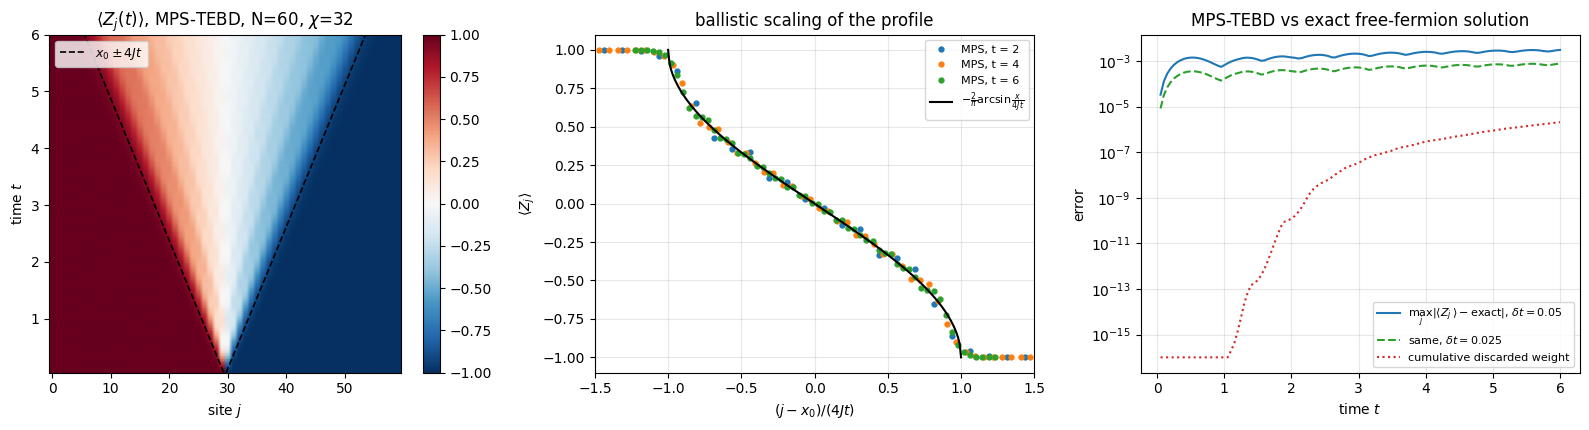

In [27]:
# ------------------------------------------------------------------------------
# FIGURE: light cone, scaling collapse, and error against the exact solution
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
ax = axes[0]
im = ax.imshow(out_dw["z"], origin="lower", aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1,
               extent=[-0.5, N_DW - 0.5, times_dw[0], times_dw[-1]])
x0 = N_DW / 2 - 0.5                                        # position of the wall (between sites 29 and 30)
ax.plot(x0 + 4 * J_XX * times_dw, times_dw, "k--", lw=1.2, label="$x_0\\pm 4Jt$")
ax.plot(x0 - 4 * J_XX * times_dw, times_dw, "k--", lw=1.2)
ax.set_xlabel("site $j$"); ax.set_ylabel("time $t$"); ax.set_title(rf"$\langle Z_j(t)\rangle$, MPS-TEBD, N={N_DW}, $\chi$={CHI_DW}")
ax.legend(loc="upper left", fontsize=9); plt.colorbar(im, ax=ax)
ax = axes[1]
xs = np.arange(N_DW) - x0
for k, c in zip((39, 79, 119), ("C0", "C1", "C2")):
    ax.plot(xs / (4 * J_XX * times_dw[k]), out_dw["z"][k], "o", ms=3.5, color=c, label=f"MPS, t = {times_dw[k]:.0f}")
u = np.linspace(-1, 1, 201)
ax.plot(u, -(2 / np.pi) * np.arcsin(u), "k-", lw=1.5, label=r"$-\frac{2}{\pi}\arcsin\frac{x}{4Jt}$")
ax.set_xlim(-1.5, 1.5); ax.set_xlabel("$(j-x_0)/(4Jt)$"); ax.set_ylabel(r"$\langle Z_j\rangle$")
ax.set_title("ballistic scaling of the profile"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[2]
ax.semilogy(times_dw, np.max(np.abs(out_dw["z"] - z_ex), axis=1), "C0-", label=rf"$\max_j|\langle Z_j\rangle-{{\rm exact}}|$, $\delta t={DT_DW}$")
ax.semilogy(times_dw, np.max(np.abs(out_dw2["z"] - z_ex), axis=1), "C2--", label=rf"same, $\delta t={DT_DW / 2}$")
ax.semilogy(times_dw, np.clip(np.cumsum(out_dw["eps"]), 1e-16, None), "C3:", label="cumulative discarded weight")
ax.set_xlabel("time $t$"); ax.set_ylabel("error"); ax.set_title("MPS-TEBD vs exact free-fermion solution")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

**Interpretation.**

- *Left*: the domain wall melts inside a sharp **light cone**. The front moves with the maximal group velocity of the
  hopping particles, $v=\max_k|d\epsilon_k/dk|=4J$ for the dispersion $\epsilon_k=4J\cos k$ (dashed lines); outside the cone
  the spins have not yet "heard" of the wall - an example of the Lieb-Robinson bound on the speed of information.
  The run stops at $t=6$, before the front reaches the ends of the chain ($24<30$ sites).
- *Centre*: profiles at different times collapse when plotted against $x/(4Jt)$ - ballistic transport - onto
  the known scaling function $-(2/\pi)\arcsin(x/4Jt)$ (Antal et al. 1999), up to small lattice oscillations near the front.
- *Right*: the deviation from the exact solution is about $3\times10^{-3}$ from early times on, while the accumulated
  discarded weight is still below $10^{-5}$ at the end. The error is therefore **not** truncation but the
  **Trotter error** $O(\delta t^2)$ of the splitting - and the second run proves it: halving $\delta t$ divides the error by
  four (see the printed ratio) at the price of twice as many SVDs. Total magnetisation and energy, both conserved by
  $H$, are conserved by the simulation to $3\times10^{-7}$ or better, and the norm stays one.

> **Numerical practice.** Identify *which* error dominates before spending computer time: here a larger $\chi$
> would buy nothing, a smaller $\delta t$ (or a fourth-order splitting, Exercise 6) buys a lot.

A 60-spin quench, verified against an exact solution, in seconds on a laptop CPU. The next figure shows why
$\chi=32$ was enough.

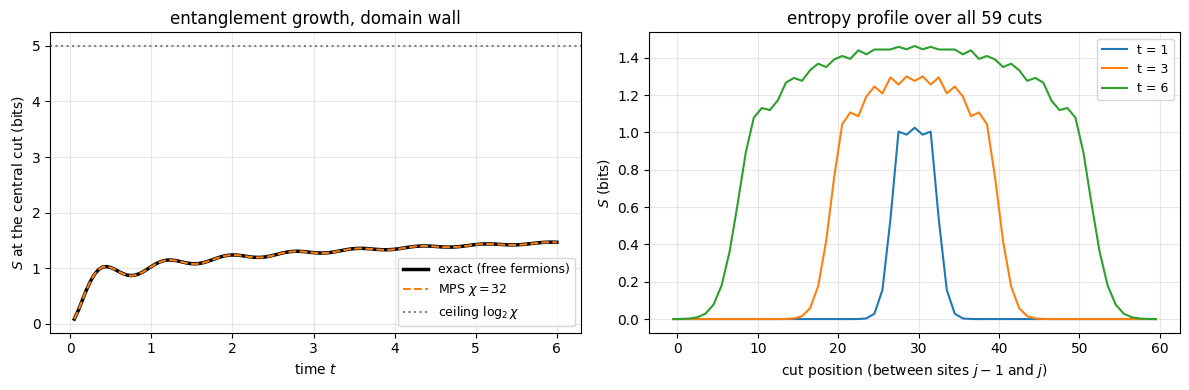

In [28]:
# ------------------------------------------------------------------------------
# FIGURE: entanglement generated by the melting domain wall
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(times_dw, S_ex, "k-", lw=2.5, label="exact (free fermions)")
ax.plot(times_dw, out_dw["S"][:, N_DW // 2], "C1--", lw=1.5, label=rf"MPS $\chi={CHI_DW}$")
ax.axhline(np.log2(CHI_DW), color="gray", ls=":", label=r"ceiling $\log_2\chi$")
ax.set_xlabel("time $t$"); ax.set_ylabel("$S$ at the central cut (bits)"); ax.set_title("entanglement growth, domain wall")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax = axes[1]
for k, c in zip((19, 59, 119), ("C0", "C1", "C2")):
    ax.plot(np.arange(N_DW + 1) - 0.5, out_dw["S"][k], "-", color=c, label=f"t = {times_dw[k]:.0f}")
ax.set_xlabel("cut position (between sites $j-1$ and $j$)"); ax.set_ylabel("$S$ (bits)")
ax.set_title("entropy profile over all 59 cuts"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Interpretation.** The entropy at the wall jumps to about one bit within $t\approx0.5$ and then creeps up very slowly,
consistent with the logarithmic growth $S\propto\ln t$ known for this free-fermion problem (Eisler, Iglói and Peschel 2009;
Exercise 3 fits the coefficient): it is only 1.46 bits at $t=6$, far below the ceiling
$\log_2 32=5$ bits. Entanglement exists only inside the light cone (right panel); outside, the state is still a product
state and the true bond dimension is 1. This is the favourable situation: **the required $\chi$ is dictated by the
entanglement entropy, not by the number of spins.** Doubling $N$ doubles the cost, nothing more.

### 10.3 The Néel quench: linear entanglement growth and the entanglement barrier

Now the unfavourable situation. In the Néel state every bond is "excited". Pairs of quasi-particles emitted everywhere
fly apart with velocities up to $4J$ and entangle distant regions: the entropy of a half chain grows **linearly in
time** (Calabrese and Cardy 2005). Since $\chi\gtrsim2^{S}$, the bond dimension needed grows *exponentially* in time. We run the
same quench with $\chi=8,16,32,64$ and let the exact solution tell us when each run fails.

In [29]:
# ==============================================================================
# PARAMETERS: Neel state, XX chain, several bond dimensions
# ==============================================================================
N_NE, DT_NE, STEPS_NE = 40, 0.025, 100                     # t_max = 2.5
CHIS_NE = (8, 16, 32, 64)
SPEC_NE = "01" * (N_NE // 2)

h_xx40 = bond_hamiltonians(N_NE, Jxx=J_XX, Jyy=J_XX)
times_ne = DT_NE * np.arange(1, STEPS_NE + 1)
z_ne_ex, S_ne_ex = xx_free_fermion_reference(SPEC_NE, J_XX, times_ne, N_NE // 2)
stag = (-1.0) ** np.arange(N_NE)                           # staggered magnetisation m_s = (1/N) sum_j (-1)^j <Z_j>

runs_ne = {}
for chi_ in CHIS_NE:
    B0, lam0 = product_mps(SPEC_NE, chi_)
    t0 = time.perf_counter()
    (B_n, lam_n), out_n = mps_tebd_evolve(B0, lam0, h_xx40, DT_NE, STEPS_NE)
    jax.block_until_ready(out_n)
    runs_ne[chi_] = {k: np.asarray(v) for k, v in out_n.items()}
    runs_ne[chi_]["B"] = B_n
    runs_ne[chi_]["wall"] = time.perf_counter() - t0

slope_ex = np.polyfit(times_ne[40:], S_ne_ex[40:], 1)[0]
print(f"exact central entropy: S(t=2.5) = {S_ne_ex[-1]:.3f} bits, slope for t>1: {slope_ex:.3f} bits per unit time "
      f"(8J/pi = {8 * J_XX / np.pi:.3f})")
print(f"{'chi':>4} | {'log2 chi':>8} | {'S_mid(t=2.5)':>12} | {'sum eps':>9} | {'max|dZ| t<=1':>12} | {'max|dZ| all t':>13} | {'t_fail':>6} | {'wall (s)':>8}")
for chi_ in CHIS_NE:
    r = runs_ne[chi_]
    dz = np.max(np.abs(r["z"] - z_ne_ex), axis=1)
    bad = np.where(dz > 1e-2)[0]
    r["t_fail"] = times_ne[bad[0]] if len(bad) else np.nan
    print(f"{chi_:>4} | {np.log2(chi_):8.2f} | {r['S'][-1, N_NE // 2]:12.3f} | {np.sum(r['eps']):9.2e} | {np.max(dz[:40]):12.2e} |"
          f" {np.max(dz):13.2e} | {r['t_fail']:6.2f} | {r['wall']:8.1f}")

exact central entropy: S(t=2.5) = 6.510 bits, slope for t>1: 2.562 bits per unit time (8J/pi = 2.546)
 chi | log2 chi | S_mid(t=2.5) |   sum eps | max|dZ| t<=1 | max|dZ| all t | t_fail | wall (s)
   8 |     3.00 |        2.998 |  2.35e+00 |     2.90e-02 |      1.23e+00 |   0.93 |      2.5
  16 |     4.00 |        3.945 |  1.28e+00 |     3.76e-04 |      1.15e+00 |   1.35 |      4.8
  32 |     5.00 |        4.987 |  6.71e-01 |     2.77e-04 |      1.06e+00 |   1.78 |     11.7
  64 |     6.00 |        5.958 |  1.44e-01 |     2.77e-04 |      3.91e-01 |   2.15 |     36.3


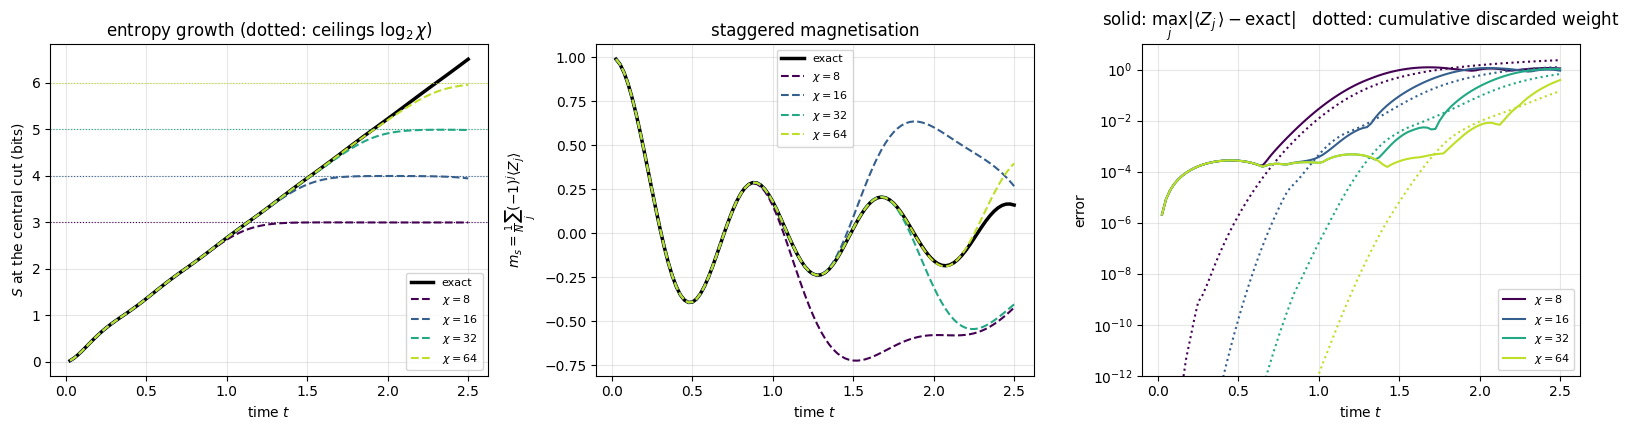

In [30]:
# ------------------------------------------------------------------------------
# FIGURE: the entanglement barrier
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
colors = plt.cm.viridis(np.linspace(0.0, 0.9, len(CHIS_NE)))
ax = axes[0]
ax.plot(times_ne, S_ne_ex, "k-", lw=2.5, label="exact")
for chi_, c in zip(CHIS_NE, colors):
    ax.plot(times_ne, runs_ne[chi_]["S"][:, N_NE // 2], "--", color=c, label=rf"$\chi={chi_}$")
    ax.axhline(np.log2(chi_), color=c, lw=0.8, ls=":")
ax.set_xlabel("time $t$"); ax.set_ylabel("$S$ at the central cut (bits)")
ax.set_title(r"entropy growth (dotted: ceilings $\log_2\chi$)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(times_ne, z_ne_ex @ stag / N_NE, "k-", lw=2.5, label="exact")
for chi_, c in zip(CHIS_NE, colors):
    ax.plot(times_ne, runs_ne[chi_]["z"] @ stag / N_NE, "--", color=c, label=rf"$\chi={chi_}$")
ax.set_xlabel("time $t$"); ax.set_ylabel(r"$m_s=\frac{1}{N}\sum_j(-1)^j\langle Z_j\rangle$")
ax.set_title("staggered magnetisation"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[2]
for chi_, c in zip(CHIS_NE, colors):
    ax.semilogy(times_ne, np.max(np.abs(runs_ne[chi_]["z"] - z_ne_ex), axis=1), "-", color=c, label=rf"$\chi={chi_}$")
    ax.semilogy(times_ne, np.clip(np.cumsum(runs_ne[chi_]["eps"]), 1e-18, None), ":", color=c)
ax.set_xlabel("time $t$"); ax.set_ylabel("error"); ax.set_ylim(1e-12, 10)
ax.set_title(r"solid: $\max_j|\langle Z_j\rangle-{\rm exact}|$   dotted: cumulative discarded weight")
ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

**The growth rate.** The exact entropy rises linearly with the fitted slope 2.56 bits per unit time. The
quasi-particle picture of Calabrese and Cardy predicts this number, and the derivation is worth doing in full
because the counting of modes is where factors of two get lost. In fermion language the Néel state is a product
state in *real* space, so in momentum space $\langle c^\dagger_kc_k\rangle=\tfrac12$ for every $k$ and, in addition,
$\langle c^\dagger_kc_{k+\pi}\rangle=\tfrac12$: the state breaks translation by one site and correlates the modes $k$ and $k+\pi$
**pairwise**. Each such pair is in the pure one-particle state $(c^\dagger_k+c^\dagger_{k+\pi})\vert0\rangle/\sqrt2$, whose two
halves are maximally entangled with each other - one bit per pair. The pairs are labelled by the reduced zone
$\vert k\vert<\pi/2$, so there are $N/2$ of them, with density $dk/2\pi$ per site. Their two members have group
velocities $\mp4J\sin k$ and therefore fly apart at the *relative* speed $2\cdot4J\vert\sin k\vert$: a pair born at a
distance $x$ from the cut has been split by time $t$ if $\vert x\vert<4J\vert\sin k\vert\,t$, a set of measure
$2\cdot4J\vert\sin k\vert\,t$. Each split pair contributes its bit, so

$$ S(t)=t\int_{-\pi/2}^{\pi/2}\frac{dk}{2\pi}\;2\cdot4J\vert\sin k\vert\;\times\;1\ \text{bit}\;=\;\frac{8J}{\pi}\,t\ \text{bits}\;=\;2.546\,t\ \text{bits}, $$

against the measured $2.562$ (the small excess comes from the finite fitting window; a free-fermion chain of
$N=400$ fitted over $1\le t\le8$ gives $2.553$). The same number can be written as "one bit per mode travelling at
$\vert4J\sin k\vert$, averaged over the *full* Brillouin zone" - the two factors of two cancel - but that shorthand
hides the pair structure and must not be transplanted to other initial states.

**Interpretation.** (Compare with the table printed above.)

- *Left*: every MPS run follows the exact line until it approaches its ceiling $\log_2\chi$ and then saturates
  *exactly* at the ceiling, because an MPS of bond dimension $\chi$ cannot carry more than $\log_2\chi$ bits.
- *Right*: at early times all runs sit on the same Trotter-error floor ($3\times10^{-4}$); then, one after the other, the
  cumulative discarded weight (dotted) climbs through that floor and the error of the observables (solid) takes off. The column
  `t_fail` of the table (first time the error exceeds $10^{-2}$) reads 0.93, 1.35, 1.78, 2.15: it grows by the same
  $\approx0.4$ for each *doubling* of $\chi$. That is the inverse of the rate just derived: one more bit of entropy costs
  a factor 2 in $\chi$ and is produced in a time $\pi/8J\approx0.39$, so $t_{\rm fail}\simeq(\pi/8J)\log_2\chi$ and the reachable
  time grows only logarithmically with the bond dimension.
- *Centre*: the damage is visible in the physics - the staggered magnetisation of the low-$\chi$ runs leaves the
  exact damped oscillation.

**What a large $\sum\varepsilon$ does to the measurements.** At $\chi=8$ the summed discarded weight reaches $2.3$ - the
stored state has almost nothing to do with the true one, and the error of $\langle Z_j\rangle$ reaches $1.2$. It is worth
being precise about what breaks and what does not. The numbers produced by `mps_expect_sites` still *look* like
expectation values: $\sum_{a,s,b}\vert\theta^{[j]}\vert^2=1$ holds exactly after every update (for the right member of
a pair because the rows of $V^\dagger$ are unit vectors, for the left member because
$\lambda^{[j]}_aB'^{[j]}_{a,s,k}=U_{(as),k}S_k/\Vert S\Vert$ and $U$ has orthonormal columns), so $\vert\langle Z_j\rangle\vert\le1$ is
guaranteed by construction and the total magnetisation still comes out conserved. What is *not* guaranteed is that
these numbers belong to the state the tensors encode: the formulas of Sec. 5 assume that the environments contract
to identities, and heavy truncation destroys that (Sec. 7.2). A plausible-looking, correctly normalised, magnetisation-conserving
profile that is simply wrong is the worst failure mode a simulation can have - which is why $\sum\varepsilon$, and not the
look of the curves, must decide whether a run is trustworthy.

> **Physics insight.** This is the **entanglement barrier**: after a global quench $S\propto t$, hence
> $\chi\propto2^{{\rm const}\cdot t}$ and cost $\propto\chi^3$. Doubling the computer budget buys a *constant* increment of simulated
> time. MPS methods defeat the exponential wall in $N$ but meet an exponential wall in $t$.

### 10.4 No reference available: judging convergence in an interacting model

Add $J_z\sum_jZ_jZ_{j+1}$ with $J_z=J$: the **Heisenberg chain**. In fermion language this is an interaction between
neighbouring particles, the free-fermion solution is gone, and at $N=60$ there is *nothing* to compare with. This
is the normal situation in research. The tools are those we calibrated above: (i) discarded weight, (ii) conserved
quantities, (iii) **convergence in $\chi$**: repeat with a different $\chi$ and compare observables and the states
themselves via `mps_overlap` (which accepts two different bond dimensions).
The $\chi=32$ run below reuses the program compiled in Sec. 10.2 (same `N`, `chi`, `n_steps`; the Hamiltonian is
a traced argument).

chi=16:   7.3 s | sum eps = 7.64e-04 | max S = 2.213 bits | energy drift = 7.0e-03 | sum_j<Z_j> drift = 1.3e-07


chi=32:  19.2 s | sum eps = 2.72e-05 | max S = 2.235 bits | energy drift = 7.0e-03 | sum_j<Z_j> drift = 3.0e-08


chi=16 vs chi=32 at all times: max |dZ_j| = 1.76e-03;  final-state fidelity |<psi_16|psi_32>|^2 = 0.99249583


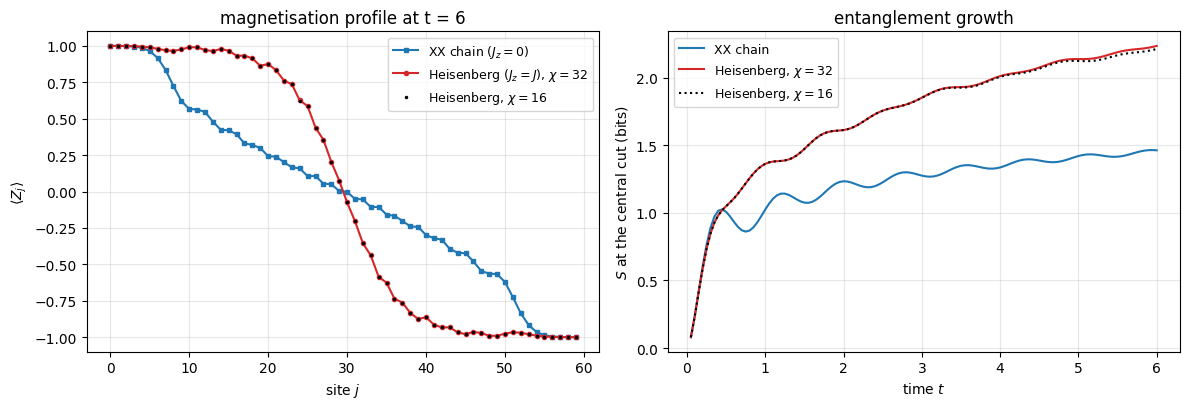

In [31]:
# ==============================================================================
# EXPERIMENT: domain wall in the interacting Heisenberg chain, chi = 16 vs chi = 32
# ==============================================================================
h_heis60 = bond_hamiltonians(N_DW, Jxx=J_XX, Jyy=J_XX, Jzz=J_XX)
runs_h = {}
for chi_ in (16, 32):
    B0, lam0 = product_mps(SPEC_DW, chi_)
    t0 = time.perf_counter()
    (B_h, lam_h), out_h = mps_tebd_evolve(B0, lam0, h_heis60, DT_DW, STEPS_DW)
    jax.block_until_ready(out_h)
    runs_h[chi_] = {k: np.asarray(v) for k, v in out_h.items()}
    runs_h[chi_].update(B=B_h, wall=time.perf_counter() - t0)
    print(f"chi={chi_}: {runs_h[chi_]['wall']:5.1f} s | sum eps = {np.sum(runs_h[chi_]['eps']):.2e} | "
          f"max S = {runs_h[chi_]['S'].max():.3f} bits | energy drift = {np.max(np.abs(runs_h[chi_]['E'] - runs_h[chi_]['E'][0])):.1e} | "
          f"sum_j<Z_j> drift = {np.max(np.abs(runs_h[chi_]['z'].sum(axis=1))):.1e}")

dz_h = np.max(np.abs(runs_h[16]["z"] - runs_h[32]["z"]))
F_h = float(jnp.abs(mps_overlap(runs_h[16]["B"], runs_h[32]["B"])) ** 2)
print(f"chi=16 vs chi=32 at all times: max |dZ_j| = {dz_h:.2e};  final-state fidelity |<psi_16|psi_32>|^2 = {F_h:.8f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
ax.plot(np.arange(N_DW), out_dw["z"][-1], "s-", ms=3, color="C0", label="XX chain ($J_z=0$)")
ax.plot(np.arange(N_DW), runs_h[32]["z"][-1], "o-", ms=3, color="C3", label=r"Heisenberg ($J_z=J$), $\chi=32$")
ax.plot(np.arange(N_DW), runs_h[16]["z"][-1], "k.", ms=3, label=r"Heisenberg, $\chi=16$")
ax.set_xlabel("site $j$"); ax.set_ylabel(r"$\langle Z_j\rangle$"); ax.set_title(f"magnetisation profile at t = {times_dw[-1]:.0f}")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(times_dw, out_dw["S"][:, N_DW // 2], "C0-", label="XX chain")
ax.plot(times_dw, runs_h[32]["S"][:, N_DW // 2], "C3-", label=r"Heisenberg, $\chi=32$")
ax.plot(times_dw, runs_h[16]["S"][:, N_DW // 2], "k:", label=r"Heisenberg, $\chi=16$")
ax.set_xlabel("time $t$"); ax.set_ylabel("$S$ at the central cut (bits)"); ax.set_title("entanglement growth")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Interpretation.** The two bond dimensions give the same magnetisation profile to within $2\times10^{-3}$; the entropies agree less well, to
$2\times10^{-2}$, entanglement being the quantity that converges last in $\chi$ since it is exactly what the truncation removes; the discarded
weight is small ($3\times10^{-5}$ at $\chi=32$); the magnetisation is conserved to $10^{-7}$ and
the energy (57 in units of $J$) to $7\times10^{-3}$ - the same for both $\chi$, hence a Trotter effect, not truncation. On this
evidence we may trust the *local observables* at the $10^{-3}$ level without an exact reference. Note, however, the
overlap of the two final states: $|\langle\psi_{16}|\psi_{32}\rangle|^2\approx0.992$. The global fidelity of a 60-spin wave function is a
far more demanding quantity than any local expectation value - decide what you need *before* you choose $\chi$.

Physically, the interaction slows the melting dramatically: at the same time $t=6$ the Heisenberg profile is
much narrower than the ballistic XX profile. Transport at the isotropic point is known to be anomalous (slower than
ballistic, faster than diffusive; Ljubotina, Žnidarič and Prosen 2017) - a result obtained with exactly this kind of
simulation. The entropy grows faster than in the XX chain (2.2 bits at $t=6$) but still slowly, which is why
domain walls are a favourite playground of MPS methods.

## 11. Cost and performance

Per time step we perform $\approx\frac32N$ two-site updates, each dominated by the SVD of a $2\chi\times2\chi$ matrix and by
contractions of cost $O(\chi^3)$: **time $O(N\chi^3)$ per step, memory $O(N\chi^2)$**. Compare with the state vector: $O(N2^N)$ time per
step, $O(2^N)$ memory. We measure the $\chi$-scaling at $N=40$, separating compilation from execution: the first call of
`mps_tebd_evolve` with a new shape compiles, the second call only runs. (`n_steps=3` is a new static value, so even
the bond dimensions used earlier are compiled afresh here.)

chi=  8: compile  1.84 s | run      3.9 ms per step (  0.06 ms per two-site update) | MPS memory   0.08 MB


chi= 16: compile  2.16 s | run     20.1 ms per step (  0.33 ms per two-site update) | MPS memory   0.31 MB


chi= 32: compile  2.61 s | run     77.2 ms per step (  1.29 ms per two-site update) | MPS memory   1.25 MB


chi= 64: compile  2.99 s | run    309.1 ms per step (  5.15 ms per two-site update) | MPS memory   5.00 MB


chi= 96: compile  1.97 s | run    750.9 ms per step ( 12.52 ms per two-site update) | MPS memory  11.25 MB



one two-site update at chi=32:  eager 135.24 ms   jit 5.18 ms


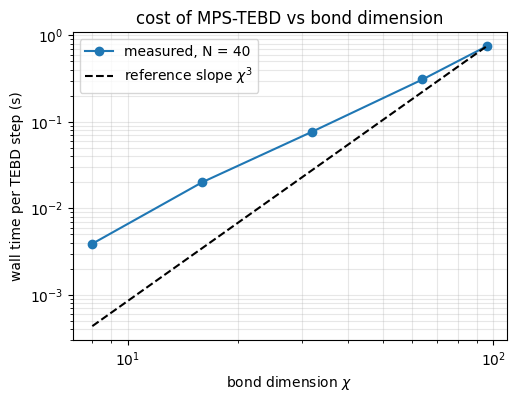

In [32]:
# ==============================================================================
# BENCHMARK: compile time vs run time, scaling with chi   (N = 40)
# ==============================================================================
CHIS_B, STEPS_B = (8, 16, 32, 64, 96), 3
t_compile, t_step = [], []
for chi_ in CHIS_B:
    B0, lam0 = product_mps(SPEC_NE, chi_)
    t0 = time.perf_counter()
    jax.block_until_ready(mps_tebd_evolve(B0, lam0, h_xx40, DT_NE, STEPS_B))     # compile + run
    t1 = time.perf_counter()
    jax.block_until_ready(mps_tebd_evolve(B0, lam0, h_xx40, DT_NE, STEPS_B))     # run only
    t2 = time.perf_counter()
    t_compile.append((t1 - t0) - (t2 - t1))
    t_step.append((t2 - t1) / STEPS_B)
    print(f"chi={chi_:3d}: compile {t_compile[-1]:5.2f} s | run {1e3 * t_step[-1]:8.1f} ms per step "
          f"({1e3 * t_step[-1] / (1.5 * N_NE):6.2f} ms per two-site update) | MPS memory {B0.nbytes / 2**20:6.2f} MB")

# the same single update without jit (eager dispatch of each einsum/SVD) vs jitted, chi = 32
B0, lam0 = product_mps(SPEC_NE, 32)
G_b = bond_gates(h_xx40, DT_NE)[0]
jax.block_until_ready(two_site_update_jit(lam0[0], B0[0], B0[1], G_b))           # warm-up (compile)
t0 = time.perf_counter()
for _ in range(20):
    jax.block_until_ready(two_site_update(lam0[0], B0[0], B0[1], G_b))
t_eager = (time.perf_counter() - t0) / 20
t0 = time.perf_counter()
for _ in range(20):
    jax.block_until_ready(two_site_update_jit(lam0[0], B0[0], B0[1], G_b))
t_jit = (time.perf_counter() - t0) / 20
print(f"\none two-site update at chi=32:  eager {1e3 * t_eager:.2f} ms   jit {1e3 * t_jit:.2f} ms")

fig, ax = plt.subplots(figsize=(5.6, 4.0))
ax.loglog(CHIS_B, t_step, "o-", label="measured, N = 40")
ref = t_step[-1] * (np.array(CHIS_B) / CHIS_B[-1]) ** 3
ax.loglog(CHIS_B, ref, "k--", label=r"reference slope $\chi^3$")
ax.set_xlabel(r"bond dimension $\chi$"); ax.set_ylabel("wall time per TEBD step (s)")
ax.set_title("cost of MPS-TEBD vs bond dimension"); ax.grid(alpha=0.3, which="both"); ax.legend()
plt.show()

**Interpretation.** Timings depend on your machine (and on what else it is doing), so read the printed numbers, not
ours. The pattern to look for: compilation costs a few seconds at most, *roughly independently of $\chi$ and of the
number of time steps* (thanks to `scan` and `vmap` the program contains one two-site update per layer, not
$N\times n_{\rm steps}$ of them); the run
time per step approaches the $\chi^3$ line at large $\chi$, where the SVD dominates, and is flatter at small $\chi$, where fixed
overheads dominate. The memory column is the whole point: a few megabytes where the state vector of 40 spins
would need 16 TB. The last printed line compares a single two-site update with and without `jit`: un-jitted, every
einsum and the SVD are dispatched one by one from Python, and this overhead - not the arithmetic - dominates at
moderate $\chi$.

> **Numerical practice.** The SVD is the bottleneck, and on CPUs it runs through LAPACK one matrix at a time. On a
> GPU the batched SVD over the bonds of a layer is where the `vmap` design pays off - but GPU SVDs of small matrices
> are comparatively slow, so MPS codes profit less from GPUs than the state-vector einsums of the earlier notebooks.
> Production codes additionally exploit the conservation of $\sum_jZ_j$: the tensors become block-sparse and the SVDs
> split into many small ones.

## 12. Limits of the method

* **Entanglement growth in time.** After a global quench $S\propto t$ and the required $\chi$ grows exponentially
  (Sec. 10.3). Real-time MPS simulations are short-time methods unless the dynamics is special (domain walls, local
  quenches with $S\propto\log t$, many-body localised systems).
* **Volume-law states.** Random circuits, highly excited eigenstates of chaotic Hamiltonians and generic quenched
  states at late times cannot be compressed at all (Sec. 3.5, random state).
* **Two error sources, two knobs.** The Trotter error is controlled by $\delta t$ (and the order of the splitting), the
  truncation error by $\chi$. They interact: a smaller $\delta t$ means more SVDs and more truncations per unit
  time. Always vary *both* independently.
* **Geometry.** MPS are built for chains with short-range couplings. A two-dimensional $L\times L$ lattice snaked into a chain
  has cuts crossed by $L$ bonds, so area-law entropy $S\propto L$ demands $\chi\propto2^{L}$. Long-range couplings require
  swap gates or other algorithms (MPO-based methods, TDVP). Higher-dimensional tensor networks (PEPS) exist, at a much
  higher cost.
* **Loss of canonical form.** Truncation breaks the orthonormality on which the local formulas of Sec. 5 rely, and
  it breaks it by $O(\varepsilon/\lambda_{\min}^2)$ rather than $O(\varepsilon)$ (Sec. 7.2), which is why the discarded weight and not
  the look of the observables must decide whether a run is converged; we also monitored the norm through
  `mps_overlap`. For unitary gates and small discarded weight this is benign; for non-unitary gates
  (imaginary-time evolution, measurements) the canonical form must be restored explicitly by a sweep.
* **Periodic boundary conditions** spoil the simple canonical forms; open chains are the natural habitat.

## 13. Summary - key takeaways

* The state vector costs $2^N$ numbers whatever the state. An **MPS** costs $O(N\chi^2)$, with $\chi\gtrsim2^{S}$ set by the
  entanglement entropy $S$ across the cuts of the chain: weakly entangled states are compressible.
* An MPS arises from **repeated SVDs** of the state tensor; the singular values are the Schmidt values of the cuts; keeping
  the $\chi$ largest is the optimal truncation and its error is the **discarded weight**, which the algorithm reports for free.
* **Canonical forms** (left/right/mixed, Vidal's $\Gamma$-$\Lambda$) turn environments into identities: local expectation values cost
  $O(\chi^2)$-$O(\chi^3)$ and entanglement entropies are read off from the stored Schmidt values.
* **DMRG** varies two neighbouring tensors at a time. In mixed-canonical form their coefficients are coordinates in an orthonormal basis, so the energy
  minimisation is the eigenvalue problem $H_{\rm eff}\theta=E\theta$ (Rayleigh–Ritz, notebook 11). $H$ enters as a **matrix product operator** (a finite-state
  machine with $D=5$ for the XXZ chain), the fixed parts of the chain as **environments** $L_j$, $R_j$ updated one site per step, and $H_{\rm eff}$ is applied
  matrix-free at $O(\chi^3)$ and diagonalised by Lanczos. An SVD splits the result and moves the centre; sweeps back and forth converge to the ground state.
* The **TEBD two-site update** is merge $\to$ gate $\to$ SVD $\to$ truncate $\to$ split: three einsums and one SVD, $O(\chi^3)$. Storing
  right-canonical tensors (Hastings' trick) avoids dividing by small Schmidt values.
* For JAX, fix the bond dimension and **pad with zeros**: static shapes allow one compilation, a `vmap` over the
  independent bonds of an even/odd layer and a `lax.scan` over time.
* Truncation errors made at different *times* add in the norm, not in the norm squared: $\sum\varepsilon$ is a sensitive
  indicator of when truncation switches on, $(\sum\sqrt\varepsilon)^2$ an envelope for the infidelity, and the single-sweep
  bound $2\sum\varepsilon$ of Sec. 3.5 does **not** apply to a time evolution.
* Validate on small systems against the state vector with the *same* Trotter scheme; on large systems monitor the
  discarded weight, conserved quantities and - above all - **convergence in $\chi$**.
* MPS-TEBD removes the exponential wall in $N$ but meets the **entanglement barrier** in $t$: linear entropy growth after
  a global quench makes the cost exponential in time.

## 14. Exercises

1. ★ **Bond dimensions of simple states.** Predict the bond dimensions of the W state $(|10\dots0\rangle+|01\dots0\rangle+\dots)/\sqrt N$ and of the
   cluster state, then check with `state_to_mps_left` (build the states with the engine or by hand for $N=8$).
2. ★ **Trotter versus truncation.** Repeat the domain-wall run of Sec. 10.2 with $\chi=8$ and $\chi=16$. At what time -
   if at all before $t=6$ - does the cumulative discarded weight rise above the Trotter floor $3\times10^{-3}$ of that
   section, and does the error against the exact solution follow it? Then go the other way: $\chi=32$ with
   $\delta t=0.1$ and $\delta t=0.2$. Is the error against the exact solution still $\propto\delta t^2$?
3. ★ **Physics of the light cone.** Change the XX coupling to $J=0.5$ and verify that the front velocity halves.
   Then measure the front position for the Heisenberg run of Sec. 10.4 (e.g. where $|\langle Z_j\rangle|$ drops below 0.9) as a function of
   time and compare its growth with $t$ and with $t^{2/3}$ (plot $x(t)/t$ and $x(t)/t^{2/3}$: one of them is flat).
   Finally use `xx_free_fermion_reference` alone - it is cheap enough for $N=400$ and $t\le40$ - to fit the entropy
   of the melting XX domain wall to $S(t)=c\ln t+{\rm const}$, and compare $c$ with $1/(6\ln 2)$ bits.
4. ★★ **Correlation light cone.** Use `mps_correlator` to compute the connected correlator
   $\langle Z_iZ_j\rangle-\langle Z_i\rangle\langle Z_j\rangle$ between the centre and all other sites after the Néel quench ($N=40$, $\chi=64$, $t\le1.5$)
   and plot it as a heat map. (Hints: evolve in chunks of a few steps and measure in between; `mps_correlator`
   requires $i<j$, so for sites left of the centre exchange the two arguments.)
5. ★★ **Entanglement barrier, quantitatively.** For the Néel quench extract $t_{\rm fail}(\chi)$ for $\chi=4,8,\dots,64$ and plot
   it against $\log_2\chi$. Compare the slope with the inverse entropy growth rate $\pi/8J$.
6. ★★ **Extend the code: fourth-order Trotter.** Build a fourth-order step from five second-order steps with the
   Suzuki coefficients of [notebook 12 (Chapter 5)](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb) and show, against the free-fermion
   reference, that the Trotter floor of Sec. 10.2 drops by orders of magnitude at fixed $\delta t$. How many SVDs per unit time
   does it cost, and how does the truncation error per unit time change? (One of the five sub-steps runs *backwards*
   in time. That is free for a unitary gate, but it still performs its share of truncations, so the fourth-order
   scheme buys Trotter accuracy at the price of a larger $\sum\varepsilon$ per unit of physical time.)
7. ★★★ **Extend the code: imaginary-time evolution to the ground state.** Replace $e^{-ih\delta t}$ by $e^{-h\delta\tau}$. The gates
   are no longer unitary, so after each layer the canonical form degrades and must be restored explicitly: sweep once
   from left to right making every tensor left-canonical with a QR (or SVD) decomposition, then once from right to
   left with an SVD, whose singular values are the new Schmidt values `lam`. Do not try to restore the form by
   feeding identity gates to `two_site_update`: that routine *assumes* that `lam` is already correct. Find the ground-state energy of
   the $N=12$ Heisenberg chain and compare with the Lanczos value printed in Sec. 2; then do $N=60$.
8. ★★★ **A TFIM quench at $N=50$.** Quench from all spins up to $h_x/J=0.5,1,2$ with `bond_hamiltonians(N, Jzz=-1, hx=-h)`.
   Measure the entropy growth rate in each case and determine, with a convergence study in $\chi$, up to which time your
   laptop can be trusted.

9. ★★ **The MPO of the transverse-field Ising chain.** Write down $W$ for $H=-J\sum_iZ_iZ_{i+1}-h\sum_iX_i$. What is the smallest $D$? Check it with `mpo_to_dense`,
   and compare the DMRG energy at $N=60$, $h=J$ with the exact value of Section 6.8.
10. ★★ **Convergence in $\chi$.** For the XX chain at $N=60$ plot the energy error against the largest discarded weight of the last sweep for $\chi=8,16,32,64$. Is the error
   proportional to the discarded weight?
11. ★★★ **Next-nearest neighbours.** Extend the finite-state machine of Eq. (11) to include $J_2\sum_iZ_iZ_{i+2}$ (one more state, "a $Z$ was placed two sites ago", once the coupling $J_{zz}$ of the nearest-neighbour term is moved from the opening $Z$ to the closing one). Validate with
   `mpo_to_dense` at $N=6$ and find the ground state of the $J_1$–$J_2$ chain at $N=60$.

## 15. References

* G. Vidal, *Efficient classical simulation of slightly entangled quantum computations*, Phys. Rev. Lett. **91**, 147902 (2003);
  *Efficient simulation of one-dimensional quantum many-body systems*, Phys. Rev. Lett. **93**, 040502 (2004). - TEBD, the $\Gamma$-$\Lambda$ form.
* S. R. White and A. E. Feiguin, *Real-time evolution using the density matrix renormalization group*, Phys. Rev. Lett. **93**, 076401 (2004);
  A. J. Daley, C. Kollath, U. Schollwöck and G. Vidal, J. Stat. Mech. P04005 (2004). - time evolution in the DMRG language.
* U. Schollwöck, *The density-matrix renormalization group in the age of matrix product states*, Ann. Phys. **326**, 96 (2011). - the standard review; canonical forms, truncation, DMRG, TEBD.
* S. R. White, *Density matrix formulation for quantum renormalization groups*, Phys. Rev. Lett. **69**, 2863 (1992). - DMRG.
* S. Östlund and S. Rommer, *Thermodynamic limit of density matrix renormalization*, Phys. Rev. Lett. **75**, 3537 (1995). - DMRG as a variational method over MPS.
* I. P. McCulloch, *From density-matrix renormalization group to matrix product states*, J. Stat. Mech. **2007**, P10014 (2007). - matrix product operators.
* R. J. Baxter, *Spontaneous staggered polarization of the F-model*, J. Stat. Phys. **9**, 145 (1973). - the exact staggered magnetisation of the XXZ chain used in Sec. 6.9.
* D. V. Dmitriev, V. Ya. Krivnov and A. A. Ovchinnikov, *Gap generation in the XXZ model in a transverse magnetic field*, Phys. Rev. B **65**, 172409 (2002).
* S. Paeckel, T. Köhler, A. Swoboda, S. R. Manmana, U. Schollwöck and C. Hubig, *Time-evolution methods for matrix-product states*, Ann. Phys. **411**, 167998 (2019).
* M. B. Hastings, *Light-cone matrix product*, J. Math. Phys. **50**, 095207 (2009). - the division-free update. *An area law for one-dimensional quantum systems*, J. Stat. Mech. P08024 (2007).
* F. Verstraete and J. I. Cirac, *Matrix product states represent ground states faithfully*, Phys. Rev. B **73**, 094423 (2006). - truncation error bound for a single compression sweep (Sec. 3.5).
* C. Eckart and G. Young, *The approximation of one matrix by another of lower rank*, Psychometrika **1**, 211 (1936). - optimality of the truncated SVD.
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes: The Art of Scientific Computing*, 3rd ed.,
  Cambridge University Press (2007) - Sec. 2.6 "Singular Value Decomposition": what the SVD computes, its cost and its
  conditioning; the same material in *Numerical Recipes in Fortran 90: The Art of Parallel Scientific Computing*, 2nd ed.,
  Cambridge University Press (1996).
* J. Eisert, M. Cramer and M. B. Plenio, *Area laws for the entanglement entropy*, Rev. Mod. Phys. **82**, 277 (2010).
* P. Calabrese and J. Cardy, *Evolution of entanglement entropy in one-dimensional systems*, J. Stat. Mech. P04010 (2005). - linear growth after a quench.
* E. Lieb, T. Schultz and D. Mattis, *Two soluble models of an antiferromagnetic chain*, Ann. Phys. **16**, 407 (1961). - Jordan-Wigner solution of the XY chain.
* I. Peschel, *Calculation of reduced density matrices from correlation functions*, J. Phys. A **36**, L205 (2003).
* T. Antal, Z. Rácz, A. Rákos and G. M. Schütz, *Transport in the XX chain at zero temperature: emergence of flat magnetization profiles*, Phys. Rev. E **59**, 4912 (1999). - the arcsine profile of Sec. 10.2.
* V. Eisler, F. Iglói and I. Peschel, *Entanglement in spin chains with gradients*, J. Stat. Mech. P02011 (2009). - logarithmic entropy growth after a domain-wall quench in the XX chain.
* M. Ljubotina, M. Žnidarič and T. Prosen, *Spin diffusion from an inhomogeneous quench in an integrable system*, Nat. Commun. **8**, 16117 (2017).

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/